# Lección 12.4 · Trayectorias y pseudotiempo: mapas de difusión, DPT, PAGA y velocidad de ARN

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/juvenalyosa/bioinformatica-practica/blob/main/modulo-12-celula-unica/12.4_trayectorias_pseudotiempo.ipynb) [![Copiloto: Claude](https://img.shields.io/badge/Copiloto-Claude-D97757?logo=claude&logoColor=white)](https://claude.ai) [![Licencia: MIT](https://img.shields.io/badge/Licencia-MIT-2a78d6.svg)](https://github.com/juvenalyosa/bioinformatica-practica/blob/main/LICENSE)

**Módulo 12 — Transcriptómica de célula única** · Bioinformática Práctica (Maestría)

👤 **Juvenal Yosa, PhD** · ✉️ [juvenal.yosa@gmail.com](mailto:juvenal.yosa@gmail.com) · 🤖 Copiloto: **Claude** (Anthropic)

| ⏱️ Duración | 📶 Nivel | 🧰 Requisitos |
|---|---|---|
| ~4 horas | Avanzado | Lecciones 12.1–12.3 (QC, normalización, PCA, grafo kNN, clustering), álgebra lineal (valores y vectores propios), NumPy/SciPy |

---

## 🎯 Objetivos de aprendizaje

Al terminar esta clase usted podrá:

1. **Explicar** por qué un proceso continuo (la diferenciación de una célula sanguínea) no se describe bien con
   *clusters* y qué es exactamente un **pseudotiempo** $\tau_c$: una coordenada de progreso transcripcional, no un reloj.
2. **Construir desde cero** un **mapa de difusión**: núcleo gaussiano con anchos locales $\sigma_i$, matriz de
   transición $T=D^{-1}K$, normalización por densidad y componentes de difusión $\psi_l$.
3. **Derivar** la **distancia de pseudotiempo de difusión** (DPT) de la serie $M=\sum_t (T-\psi_0\phi_0^\top)^t$,
   **entender** los pesos $\lambda_l/(1-\lambda_l)$ y **reproducir** cifra por cifra el ejemplo del libro
   «Pseudotiempo en una bifurcación simulada» ($\rho=0{,}978$).
4. **Resumir** la topología con **PAGA** (conectividad entre grupos $c_{ab}$) y **leer** la dinámica de genes a lo
   largo del pseudotiempo en cada rama.
5. **Aplicar** todo a datos **reales**: la hematopoyesis mieloide de ratón de **Paul et al. (2015)** con Scanpy
   (`diffmap`, `dpt`, `paga`), **comprobar** la sensibilidad a la raíz y **seguir** los marcadores eritroides
   (*Gata1*, *Klf1*, *Hbb-b1*) frente a los mieloides (*Mpo*, *Elane*, *Cebpa*).
6. **Formular** el modelo cinético de la **velocidad de ARN**, **resolverlo**, **estimar** $\hat\gamma'$ con el
   método de los extremos y **saber** cuándo desconfiar de las flechas.

## 🗺️ Mapa de la clase

1. Del agrupamiento a los procesos continuos (la sangre como fábrica)
2. Una diferenciación simulada con una bifurcación (el ejemplo del libro)
3. Mapas de difusión desde cero (🎬 animación: la difusión se extiende desde la raíz)
4. El pseudotiempo de difusión (DPT) y la detección de ramas (🎛️ mapa 3D interactivo, 🎬 animación: las células en orden)
5. PAGA: el mapa de metro de las células, y los genes a lo largo del pseudotiempo
6. Datos reales: hematopoyesis de ratón (Paul et al., 2015) con Scanpy (🎛️ grafo PAGA interactivo)
7. La idea de la velocidad de ARN (🎛️ retrato de fase interactivo)
8. Ejercicios, resumen y lecturas

> 📖 **Compañero del libro.** Esta lección acompaña la sección «Trayectorias y pseudotiempo» del capítulo 12 del libro
> *Bioinformática Práctica*. Usamos exactamente sus símbolos ($\tau_c$, $r$, $\sigma_i$, $K_{ij}$, $T$, $D$,
> $\lambda_l$, $\psi_l$, $\phi_0$, $M$, $\mathrm{dpt}$, $c_{ab}$, $e_{ab}$, $k_a$, $m$, $u$, $s$, $\alpha$, $\beta$,
> $\gamma$, $\gamma'$, $v$), volvemos a correr sus simulaciones **con las mismas semillas** y reproducimos sus
> cifras; pero el notebook se puede seguir sin el libro.

In [1]:
# ⚙️ Configuración del entorno (ejecute esta celda primero)
# Bioinformática Práctica · Juvenal Yosa, PhD · Copiloto: Claude
import os, sys, urllib.request

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# Descarga el estilo gráfico del curso (en Colab) o lo toma del repositorio (local)
STYLE_URL = "https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/utils/estilo_curso.py"
if os.path.exists("../utils/estilo_curso.py"):
    sys.path.insert(0, "../utils")
elif not os.path.exists("estilo_curso.py"):
    urllib.request.urlretrieve(STYLE_URL, "estilo_curso.py")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import estilo_curso as ec

ec.set_style()
print("Entorno listo ✔  |  Colab:", IN_COLAB)

import math, warnings
import plotly.express as px
import plotly.graph_objects as go
from scipy import stats, sparse
from scipy.sparse.linalg import eigsh
from sklearn.neighbors import NearestNeighbors
import networkx as nx
from scipy.sparse.csgraph import connected_components
from matplotlib.colors import LogNorm

# Scanpy no viene instalado en Colab (tarda ~30 s en instalarse)
try:
    import scanpy as sc
except ImportError:
    %pip install -q scanpy "pandas=={pd.__version__}" "numpy=={np.__version__}"
    import scanpy as sc
import anndata as ad
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message=".*IProgress.*")
sc.settings.verbosity = 0

RAW = "https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main"

def course_file(name):
    """Ruta local de un archivo del curso: 1) copia en ../data; 2) descarga desde el repositorio en GitHub."""
    local = os.path.join("..", "data", name)
    if os.path.exists(local):
        return local
    if not os.path.exists(name):
        urllib.request.urlretrieve(f"{RAW}/data/{name}", name)
    return name

# Colores fijos de las ramas (los mismos del libro): tronco gris, eritroide rojo, mieloide azul
BRANCH_COLORS = np.array([ec.MUTED, ec.RED, ec.BLUE])
BRANCH_NAMES = ["tronco", "eritroide", "mieloide"]
print("NumPy", np.__version__, "· Scanpy", sc.__version__, "· NetworkX", nx.__version__)

Entorno listo ✔  |  Colab: False


NumPy 2.5.3 · Scanpy 1.12.4 · NetworkX 3.7


## 1. Del agrupamiento a los procesos continuos

### Una fotografía de un maratón

Suponga que un dron toma **una única fotografía** aérea de un maratón una hora después de la salida. No hay película:
sólo una imagen congelada. Aun así, usted puede reconstruir el recorrido. Los corredores forman una línea continua
sobre las calles; los más adelantados marcan el camino hacia la meta; donde la carrera se divide en dos recorridos
(el maratón y la media maratón) la línea se **bifurca**. Si además cada corredor llevara en la camiseta un
velocímetro, sabría hacia dónde se mueve cada uno.

Un experimento de célula única es esa fotografía. Las células de un tejido en diferenciación están, **en el mismo
instante**, en todas las etapas del proceso. El **pseudotiempo** ordena a los corredores por la distancia recorrida;
la **velocidad de ARN** es el velocímetro.

### La médula ósea: una fábrica que nunca para

El ejemplo más estudiado es la **hematopoyesis**, la producción de células sanguíneas. Un adulto fabrica del orden de
**dos millones de glóbulos rojos por segundo**, además de neutrófilos, monocitos, plaquetas y linfocitos. Todos
proceden de células madre y progenitoras de la médula ósea que, a lo largo de varias divisiones, **eligen un
destino**: un progenitor mieloide común da lugar a progenitores megacariocítico-eritroides (MEP), que producen
glóbulos rojos y plaquetas, y a progenitores de granulocitos y monocitos (GMP), que producen neutrófilos y monocitos.
En una muestra de médula hay células en **todos** los puntos de ese camino a la vez.

¿Por qué importa ordenarlas? Porque muchas enfermedades de la sangre son **defectos del camino**:

* En la **leucemia mieloide aguda** (LMA) los blastos quedan **bloqueados** en un estado inmaduro de la
  diferenciación; las mutaciones que inactivan *CEBPA*, un regulador maestro de la rama granulocítica, son una causa
  bien documentada de ese bloqueo.
* En la **leucemia promielocítica aguda** el tratamiento con **ácido transretinoico** fuerza a las células a terminar
  su diferenciación: una «terapia de diferenciación» que sólo se entiende si se sabe qué camino debían recorrer.
* Las **anemias congénitas** (p. ej., mutaciones de *GATA1* o *KLF1*) alteran la rama eritroide.

Ubicar las células de un paciente sobre el mapa normal de la diferenciación, y ver **dónde se detienen**, es hoy
una aplicación clínica y de investigación directa de las ideas de esta clase.

### Por qué los *clusters* no bastan

En la lección 12.3 partimos las células en grupos discretos. Pero en la hematopoyesis, la espermatogénesis o el
desarrollo neural las células atraviesan un **continuo** de estados entre un progenitor y uno o varios destinos.
Forzar ese continuo en *clusters* lo trocea arbitrariamente, como cortar una rampa en escalones. La **inferencia de
trayectorias** busca, en cambio, una estructura de dimensión uno (una línea, un árbol, a veces un ciclo) que recorra
los datos, y un **pseudotiempo**: la posición de cada célula a lo largo de esa estructura.

**Definición (pseudotiempo).** Dada una **célula raíz** $r$ elegida con información biológica (p. ej., la que más
expresa marcadores de progenitor), el pseudotiempo $\tau_c$ de la célula $c$ es una medida de distancia de $r$ a
$c$ **a lo largo de la variedad de los datos**, normalizada a $[0,1]$:

$$
\tau_c=\frac{d(r,c)-\min_{c'} d(r,c')}{\max_{c'} d(r,c')-\min_{c'} d(r,c')}\in[0,1].
$$

| Símbolo | Significado |
|---|---|
| $r$ | célula raíz: el punto de partida del proceso, elegido con conocimiento biológico |
| $c$ | una célula cualquiera |
| $d(r,c)$ | una distancia **a lo largo de los datos** (más adelante, la DPT) |
| $\tau_c$ | pseudotiempo de $c$: progreso transcripcional, **no** horas ni días |

Dos células con el mismo pseudotiempo han recorrido la misma distancia **en expresión**, no necesariamente el mismo
número de horas: una célula puede cambiar mucho su transcriptoma en una hora y casi nada en un día.

> 📜 **Un poco de historia.** El primer método de amplio uso fue **Monocle** (Trapnell et al., 2014): redujo la
> dimensión con análisis de componentes independientes, construyó un **árbol de expansión mínima** entre las células
> y las ordenó por su posición en el camino más largo del árbol, lo que permitió seguir la diferenciación de
> mioblastos humanos. Desde entonces se han publicado decenas de métodos. La comparación de **Saelens et al.
> (2019)**, con 45 métodos, concluyó que **ningún método es el mejor en todos los casos**: el rendimiento depende
> sobre todo de la **topología** (lineal, bifurcada, en árbol, cíclica o desconectada). Recomendación práctica: elija
> el método según la topología esperada y compare varios.

### La herradura: por qué la línea recta engaña

Las distancias euclídeas funcionan bien **a escala local**, pero una trayectoria curva puede acercar en línea recta
células que en el proceso están lejos. Piense en una herradura: sus dos extremos están cerca **por el aire** y lejos
**por el camino**. Un método que ordene las células proyectándolas sobre una recta (como la PC1) confundirá el
principio con el final.

**A mano.** Una herradura en forma de U: dos brazos paralelos de 3 unidades, separados por $0{,}8$ y unidos arriba
por una semicircunferencia de radio $0{,}4$. La distancia **a lo largo del camino** entre los dos extremos es
$3+\pi\cdot0{,}4+3\approx7{,}26$; la distancia **por el aire**, $0{,}8$: nueve veces menor. Cualquier medida que mire
sólo la línea recta pondrá el final **junto** al inicio.

> 🤔 **Antes de ejecutar, prediga.** Si ordenamos 400 células de una herradura por su coordenada en la PC1, ¿qué
> correlación de Spearman espera con el orden verdadero a lo largo del arco: cercana a 1, cercana a 0 o negativa?

distancia por el aire entre los extremos: 0.75 · a lo largo del camino: 7.26
Spearman(PC1, posición verdadera) = -0.010


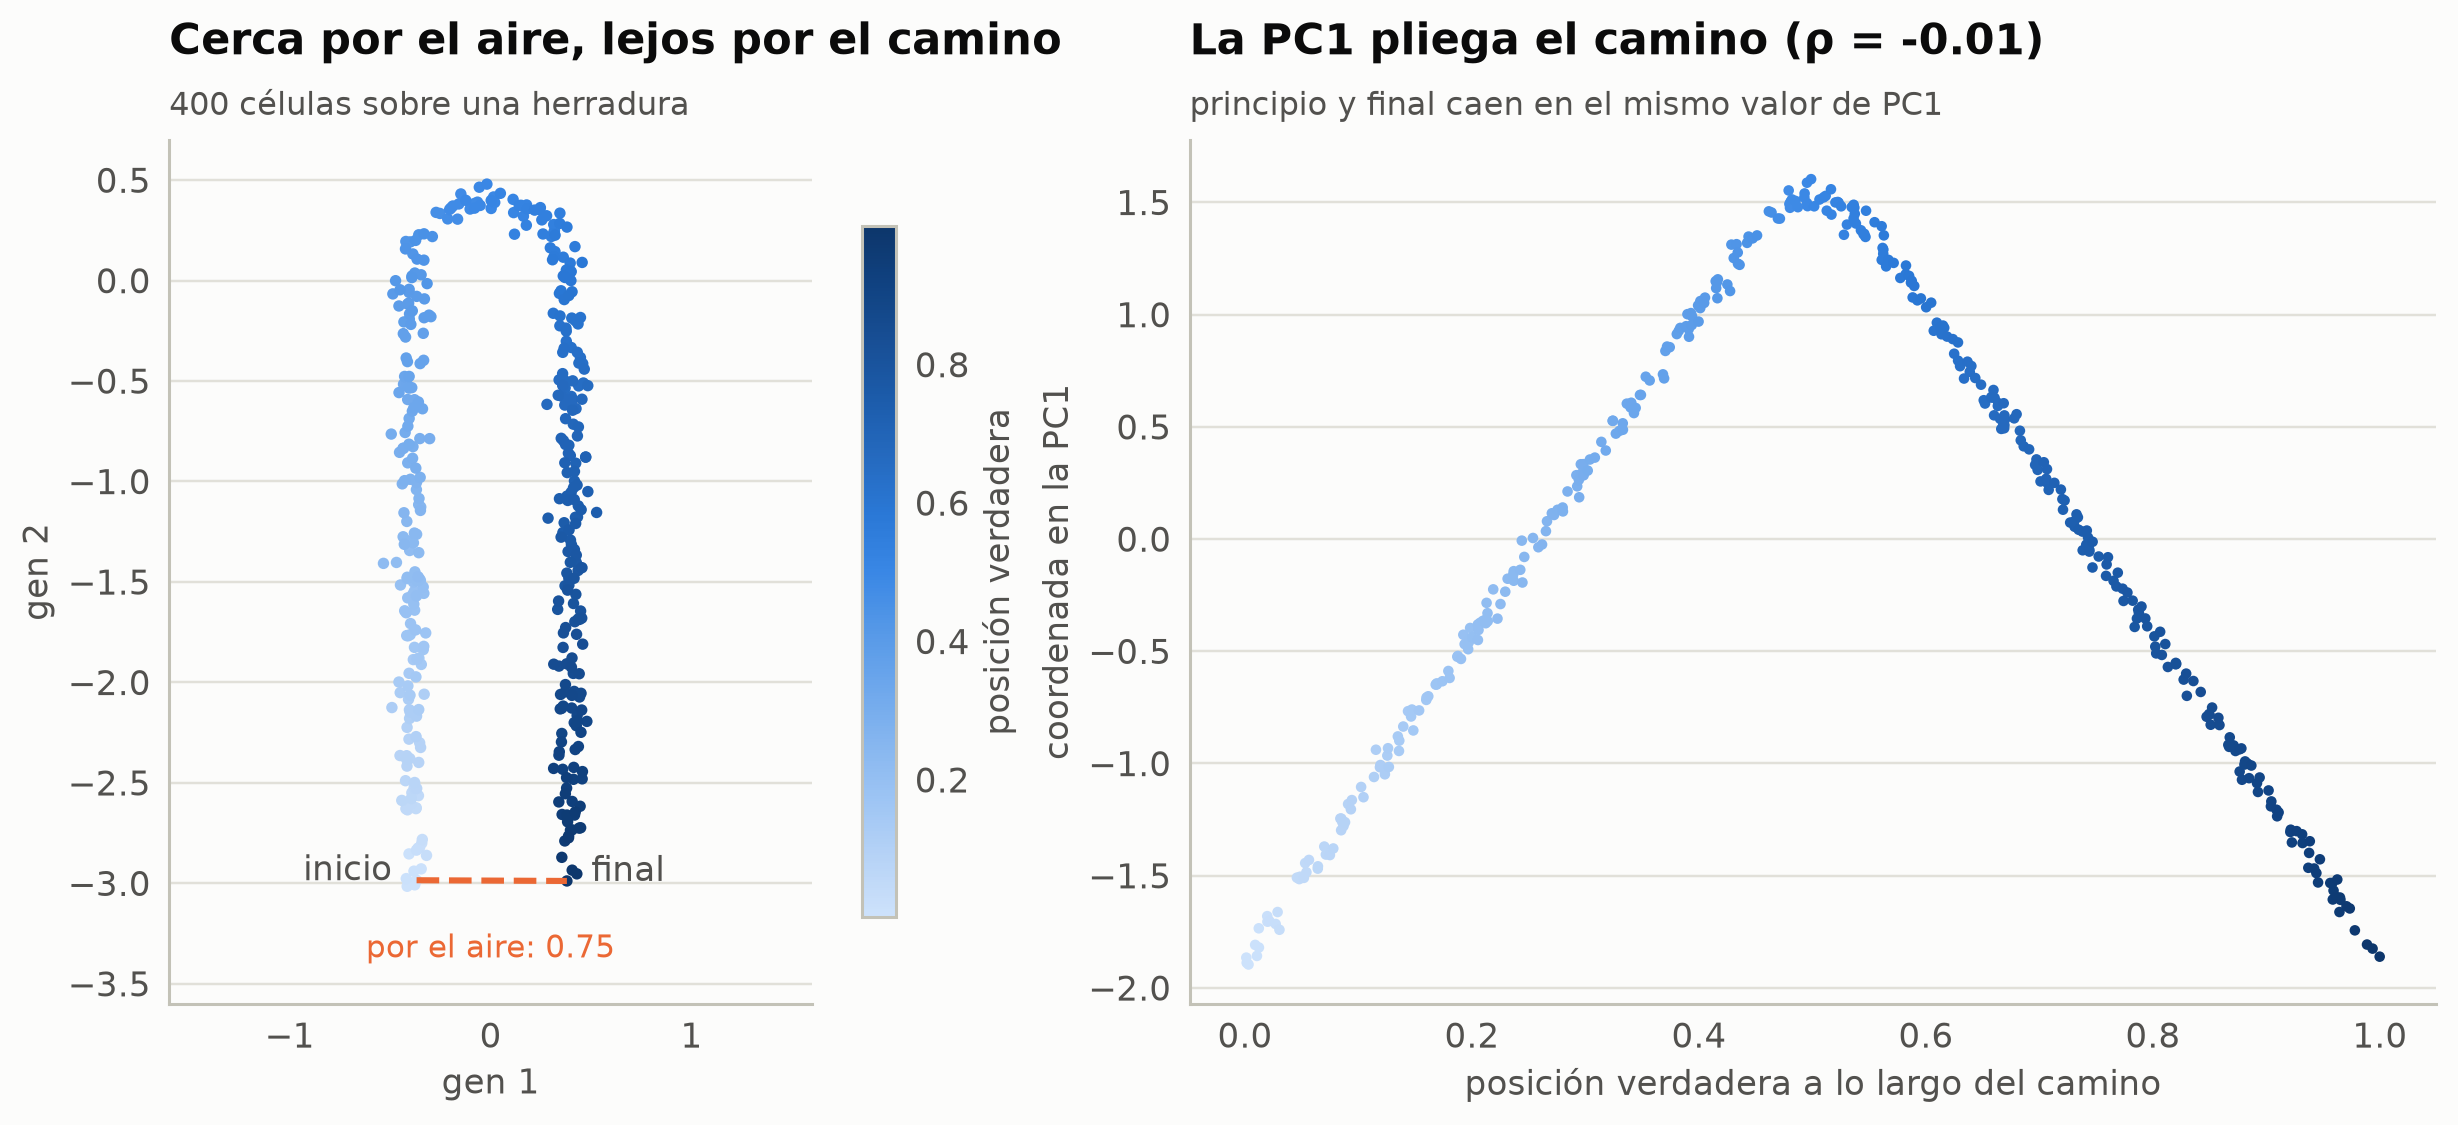

In [2]:
# Una herradura en U: brazo izquierdo que sube, semicírculo arriba y brazo derecho que baja
rng_h = np.random.default_rng(3)
n_h, L_arm, r_h = 400, 3.0, 0.4
L_path = 2 * L_arm + np.pi * r_h                          # longitud total del camino
arc = np.sort(rng_h.uniform(0, 1, n_h))                   # posición verdadera a lo largo del camino (0 = inicio)
s_h = arc * L_path
phi = np.clip((s_h - L_arm) / r_h, 0, np.pi)
H = np.where((s_h < L_arm)[:, None], np.column_stack([-r_h * np.ones(n_h), -L_arm + s_h]),
             np.where((s_h < L_arm + np.pi * r_h)[:, None], np.column_stack([-r_h * np.cos(phi), r_h * np.sin(phi)]),
                      np.column_stack([r_h * np.ones(n_h), -(s_h - L_arm - np.pi * r_h)])))
H = H + rng_h.normal(0, 0.04, (n_h, 2))

Hc = H - H.mean(0)
_, _, Vh = np.linalg.svd(Hc, full_matrices=False)
pc1_h = Hc @ Vh[0]
rho_pc1 = stats.spearmanr(pc1_h, arc).statistic
d_air = np.linalg.norm(H[0] - H[-1])
print(f"distancia por el aire entre los extremos: {d_air:.2f} · a lo largo del camino: {L_path:.2f}")
print(f"Spearman(PC1, posición verdadera) = {rho_pc1:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5.0), gridspec_kw=dict(width_ratios=[0.8, 1]))
ax = axes[0]
s_ = ax.scatter(H[:, 0], H[:, 1], c=arc, cmap="curso_seq", s=14, lw=0)
ax.plot(H[[0, -1], 0], H[[0, -1], 1], color=ec.ORANGE, lw=2, ls="--")
ax.annotate("inicio", H[0], xytext=(-8, 0), textcoords="offset points", ha="right", color=ec.INK_2)
ax.annotate("final", H[-1], xytext=(8, 0), textcoords="offset points", color=ec.INK_2)
ax.text(0, -3.25, f"por el aire: {d_air:.2f}", color=ec.ORANGE, fontsize=10, ha="center", va="top")
ax.set_aspect("equal"); ax.set_xlim(-1.6, 1.6); ax.set_ylim(-3.6, 0.7); ax.set_xlabel("gen 1"); ax.set_ylabel("gen 2")
fig.colorbar(s_, ax=ax, label="posición verdadera", shrink=0.8)
ec.title(ax, "Cerca por el aire, lejos por el camino", "400 células sobre una herradura")
ax = axes[1]
ax.scatter(arc, pc1_h, c=arc, cmap="curso_seq", s=12, lw=0)
ax.set_ylabel("coordenada en la PC1")
ax.set_xlabel("posición verdadera a lo largo del camino")
ec.title(ax, f"La PC1 pliega el camino (ρ = {rho_pc1:.2f})", "principio y final caen en el mismo valor de PC1")
plt.show()

> 🔎 **Qué observamos.** Los extremos de la herradura están a menos de una unidad por el aire, pero a más de siete
> a lo largo del camino. La PC1, que es una **proyección lineal** (aquí, casi la dirección vertical), sube y luego
> baja: pliega el camino sobre sí mismo y la correlación con el orden verdadero es prácticamente nula. Necesitamos una distancia que **camine por los
> datos**. Eso es un mapa de difusión, y volveremos a esta herradura para comprobar que lo resuelve.

## 2. Una diferenciación simulada con una bifurcación

Antes de mirar datos reales, donde **no conocemos la respuesta**, construimos un sistema donde sí la conocemos. Es
la misma simulación del libro (semilla 77):

* **2 000 células** con un **tiempo simulado** $t\in[0,1]$. Las de $t<0{,}3$ forman el **tronco progenitor**; las
  demás se reparten al azar entre una **rama eritroide** y una **rama mieloide**.
* **600 genes**: 45 del programa progenitor (entre ellos *CD34*, *GATA2*, *MEIS1*, *HLF*, *KIT*) que **descienden**
  con $t$; 45 eritroides (*GATA1*, *KLF1*, *TFRC*, *HBB*, *CA1*) y 45 mieloides (*CEBPA*, *MPO*, *ELANE*, *LYZ*,
  *CSF1R*) que **suben** con una sigmoide sólo en su rama; 25 genes **transitorios** con un pico en la bifurcación
  ($t\approx0{,}32$), y el resto sin señal.
* El orden temporal está impuesto: en la rama eritroide *GATA1* se activa en $t=0{,}38$, *KLF1* en $0{,}5$, *TFRC* en
  $0{,}65$, *HBB* en $0{,}8$ y *CA1* en $0{,}9$; en la mieloide, *CEBPA*, *MPO*, *CSF1R*, *ELANE* y *LYZ* en los mismos
  instantes. Primero los **reguladores**, después los **efectores**, como en la biología real.
* Cuentas **binomiales negativas** (lección 12.1) con tamaños de biblioteca log-normales.

Luego aplicamos el flujo de las lecciones anteriores: $\log(1+\text{CP10k})$, estandarización por gen y **20 PC**.

In [3]:
# Simulación del libro (figuras/cap12/generar.py, sección 12.4), semilla 77: se reproduce número a número
def sig(x, c, s=0.08):
    return 1 / (1 + np.exp(-(x - c) / s))

def nb_counts(rng, mu, theta):
    """Cuentas binomiales negativas como mezcla gamma-Poisson (lección 12.1)."""
    return rng.poisson(rng.gamma(theta, mu / theta))

rngt = np.random.default_rng(77)
NT, GT = 2000, 600
t_sim = rngt.uniform(0, 1, NT) ** 0.9                        # tiempo simulado (la «verdad»)
branch = np.where(t_sim < 0.3, 0, rngt.choice([1, 2], NT))   # 0 tronco, 1 eritroide, 2 mieloide
genes = (["CD34", "GATA2", "MEIS1", "HLF", "KIT", "GATA1", "KLF1", "TFRC", "HBB", "CA1",
          "CEBPA", "MPO", "ELANE", "LYZ", "CSF1R"] + [f"G{i:04d}" for i in range(GT - 15)])
base = rngt.lognormal(-0.5, 1.2, GT)
base[:15] = rngt.lognormal(-1.0, 0.2, 15)
logfc = np.zeros((NT, GT))
prog = [0, 1, 2, 3, 4] + list(range(15, 55))
ery = [5, 6, 7, 8, 9] + list(range(55, 95))
mye = [10, 11, 12, 13, 14] + list(range(95, 135))
trans = list(range(135, 160))
amp = rngt.uniform(2.0, 4.0, GT)
cen = rngt.uniform(0.45, 0.85, GT)
cen[[5, 10]] = 0.38; cen[[6, 11]] = 0.5; cen[[8, 12]] = 0.8
cen[[9, 13]] = 0.9; cen[[7, 14]] = 0.65
for g in prog:
    logfc[:, g] = amp[g] * (1 - sig(t_sim, rngt.uniform(0.2, 0.5), 0.12))
for g in ery:
    logfc[:, g] = amp[g] * sig(t_sim, cen[g]) * (branch == 1)
for g in mye:
    logfc[:, g] = amp[g] * sig(t_sim, cen[g]) * (branch == 2)
for g in trans:
    logfc[:, g] = amp[g] * np.exp(-((t_sim - 0.32) / 0.08) ** 2)
P = base[None] * np.exp(logfc)
P /= P.sum(1, keepdims=True)
lib = rngt.lognormal(math.log(3000), 0.35, NT)
theta = rngt.lognormal(math.log(8), 0.4, GT)
X_sim = nb_counts(rngt, lib[:, None] * P, theta[None])

# Flujo estándar: log(1 + CP10k), estandarización y 20 PC
Y_sim = np.log1p(X_sim / X_sim.sum(1, keepdims=True) * 1e4)
Zs = (Y_sim - Y_sim.mean(0)) / (Y_sim.std(0) + 1e-9)
U_, S_, _ = np.linalg.svd(Zs, full_matrices=False)
pcs_sim = U_[:, :20] * S_[:20]
gi = {g: genes.index(g) for g in genes[:15]}
print("matriz de cuentas:", X_sim.shape, "· UMI medianos por célula:", int(np.median(X_sim.sum(1))))
print("células por rama:", dict(zip(BRANCH_NAMES, np.bincount(branch).tolist())))

matriz de cuentas: (2000, 600) · UMI medianos por célula: 3009
células por rama: {'tronco': 530, 'eritroide': 780, 'mieloide': 690}


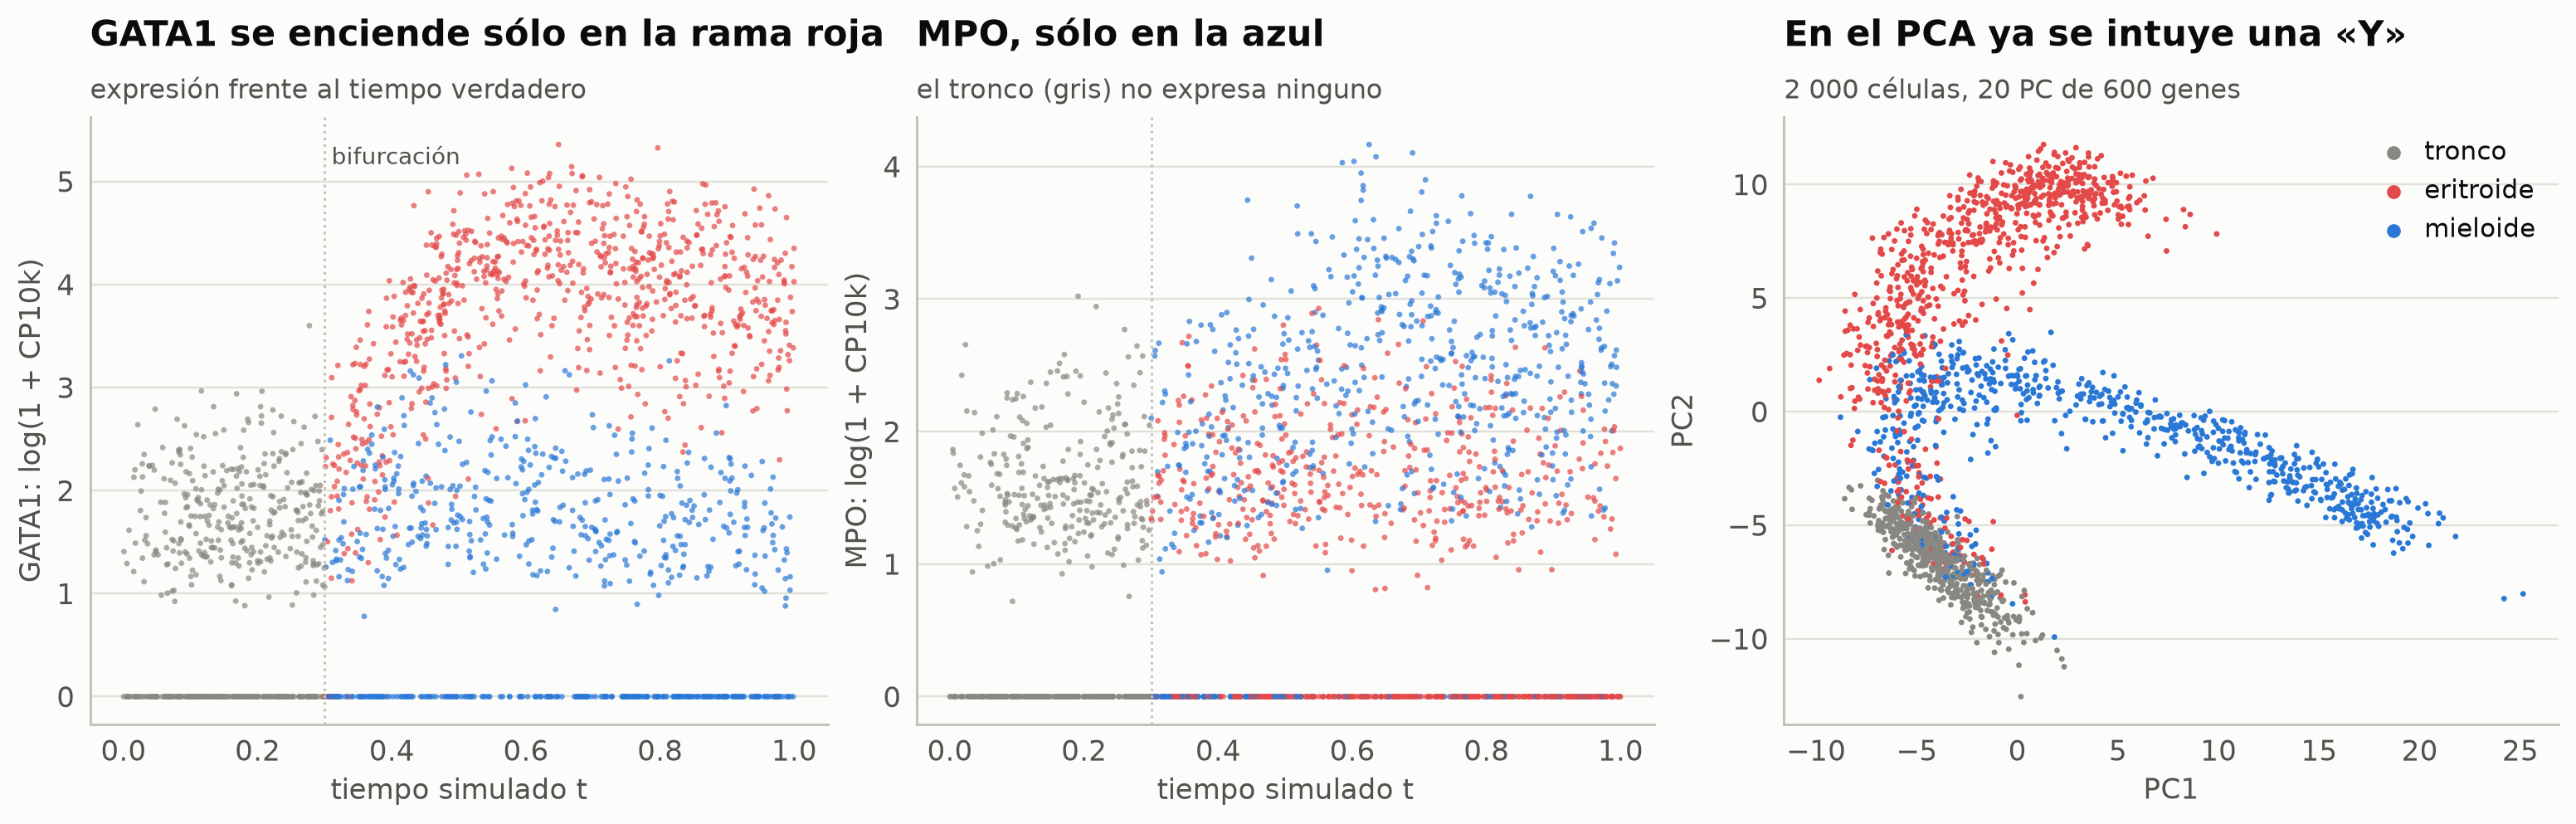

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.4), gridspec_kw=dict(width_ratios=[1, 1, 1.05]))
o = np.random.default_rng(2).permutation(NT)
for ax, g in zip(axes[:2], ("GATA1", "MPO")):
    ax.scatter(t_sim[o], Y_sim[o, gi[g]], c=BRANCH_COLORS[branch[o]], s=5, lw=0, alpha=0.7)
    ax.axvline(0.3, color=ec.BASELINE, lw=1, ls=":")
    ax.set_xlabel("tiempo simulado t"); ax.set_ylabel(f"{g}: log(1 + CP10k)")
axes[0].text(0.31, axes[0].get_ylim()[1] * 0.95, "bifurcación", fontsize=9, color=ec.INK_2, va="top")
ec.title(axes[0], "GATA1 se enciende sólo en la rama roja", "expresión frente al tiempo verdadero")
ec.title(axes[1], "MPO, sólo en la azul", "el tronco (gris) no expresa ninguno")
ax = axes[2]
ax.scatter(pcs_sim[o, 0], pcs_sim[o, 1], c=BRANCH_COLORS[branch[o]], s=5, lw=0)
for b in range(3):
    ax.scatter([], [], c=BRANCH_COLORS[b], s=30, label=BRANCH_NAMES[b])
ax.legend(loc="upper right", markerscale=1, handletextpad=0.2)
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ec.title(ax, "En el PCA ya se intuye una «Y»", "2 000 células, 20 PC de 600 genes")
plt.show()

> 🔎 **Qué observamos.** Cada rama enciende su propio programa y el tronco no expresa ninguno de los dos: la
> información del destino está en los datos. En el plano PC1–PC2 se adivina una forma de «Y», pero las ramas se curvan
> y el ruido engorda la figura. El reto es **recuperar $t$ sin mirarlo**: sólo con las 2 000 células y sus 600 genes.

## 3. Mapas de difusión desde cero

### La idea: una partícula que salta entre células vecinas

Imagine que deja caer una gota de tinta en una célula y que, en cada paso, la tinta salta a una célula **vecina** con
probabilidad mayor cuanto más parecida sea. En una región densa la tinta se reparte deprisa; para cruzar la
herradura de un extremo al otro tiene que recorrer todo el arco, **porque no hay vecinos por el aire**. La
«distancia de difusión» sustituye la línea recta por el tiempo que tarda la tinta en llegar.

### El núcleo con anchos locales

Para cada par de células vecinas se define un **núcleo gaussiano** con **anchos locales**, como en t-SNE, y a partir
de él una **matriz de transición** de un paseo aleatorio (Haghverdi et al., 2016; es la primera ecuación de la sección en el libro):

$$
K_{ij}=\sqrt{\frac{2\sigma_i\sigma_j}{\sigma_i^2+\sigma_j^2}}\;\exp\!\left(-\frac{\lVert x_i-x_j\rVert^2}{\sigma_i^2+\sigma_j^2}\right),
\qquad
T=D^{-1}K,\qquad D=\operatorname{diag}\Bigl(\textstyle\sum_j K_{ij}\Bigr).
$$

| Símbolo | Significado |
|---|---|
| $x_i$ | coordenadas de la célula $i$ (aquí, sus 20 PC) |
| $\sigma_i$ | ancho local de la célula $i$: la distancia a su vecino número $k/2$ (en regiones densas, pequeño) |
| $K_{ij}$ | afinidad entre $i$ y $j$; el prefactor garantiza que $K$ siga siendo un núcleo válido con anchos distintos |
| $D$ | matriz diagonal con la suma de cada fila de $K$ (el «grado» de cada célula) |
| $T_{ij}$ | probabilidad de que el paseo aleatorio salte de $i$ a $j$ en un paso; cada fila suma 1 |

Si $\sigma_i=\sigma_j=\sigma$, el prefactor vale 1 y el núcleo es la gaussiana de siempre, $\exp(-d^2/2\sigma^2)$.

**Ejemplo a mano.** Tres células sobre una recta, $A=0$, $B=1$ y $C=3$, con $\sigma=1$ para todas (y cada célula
vecina de sí misma, como en la implementación). Entonces $K_{ij}=e^{-d_{ij}^2/2}$:

$$
K=\begin{pmatrix}1 & e^{-0{,}5} & e^{-4{,}5}\\ e^{-0{,}5} & 1 & e^{-2}\\ e^{-4{,}5} & e^{-2} & 1\end{pmatrix}
=\begin{pmatrix}1 & 0{,}607 & 0{,}011\\ 0{,}607 & 1 & 0{,}135\\ 0{,}011 & 0{,}135 & 1\end{pmatrix},
\qquad
T=\begin{pmatrix}0{,}618 & 0{,}375 & 0{,}007\\ 0{,}348 & 0{,}574 & 0{,}078\\ 0{,}010 & 0{,}118 & 0{,}872\end{pmatrix}.
$$

Las sumas de fila son $1{,}618$, $1{,}742$ y $1{,}146$; al dividir cada fila por su suma se obtiene $T$. Desde $A$,
la tinta salta a $B$ con probabilidad $0{,}375$ y a $C$ sólo con $0{,}007$: $C$ está «lejos» aunque $|A-C|=3$ no sea
enorme, porque el núcleo decae como el **cuadrado** de la distancia. Los valores propios de esta $T$ son $1$,
$0{,}837$ y $0{,}228$.

### Corregir la densidad y descomponer

En la práctica, antes de normalizar por filas se divide $K$ por las **densidades** de ambos extremos,
$\tilde K_{ij}=K_{ij}/(q_iq_j)$ con $q_i=\sum_jK_{ij}$, para que las regiones muy pobladas no atraigan al paseo; así,
los componentes reflejan la **geometría** de los datos y no cuántas células hay en cada zona (un tipo celular
abundante no debe parecer «el centro del mundo»). Después $T=\tilde D^{-1}\tilde K$.

$T$ tiene valores propios $1=\lambda_0>\lambda_1\ge\lambda_2\ge\cdots$ con vectores propios por la derecha $\psi_0$
(constante), $\psi_1,\psi_2,\dots$ Las coordenadas $(\psi_1(c),\psi_2(c),\dots)$ son los **componentes de difusión**
(DC) de la célula $c$: los **modos más lentos** del paseo aleatorio, que en una trayectoria ramificada se alinean
con las ramas.

| Símbolo | Significado |
|---|---|
| $q_i$ | densidad local de la célula $i$ (suma de su fila de $K$) |
| $\lambda_l$ | valor propio $l$ de $T$: cuánto «persiste» ese modo en un paso (cerca de 1 = lento, de gran escala) |
| $\psi_l$ | vector propio por la derecha: el componente de difusión DC$l$, un número por célula |
| $\psi_0,\ \lambda_0=1$ | modo trivial (constante): el paseo ya mezclado |

**Truco numérico.** $T$ no es simétrica, pero $M_{\text{sym}}=\tilde D^{-1/2}\tilde K\tilde D^{-1/2}$ sí lo es y tiene
los mismos valores propios; si $v$ es vector propio de $M_{\text{sym}}$, entonces $\psi=\tilde D^{-1/2}v$ lo es de
$T$. Así podemos usar `eigsh`, el solucionador para matrices simétricas dispersas.

In [5]:
# Comprobación del ejemplo a mano
x3 = np.array([0.0, 1.0, 3.0])
K3 = np.exp(-(x3[:, None] - x3[None]) ** 2 / 2)
T3 = K3 / K3.sum(1, keepdims=True)
print("K =\n", K3.round(3), "\nsumas de fila:", K3.sum(1).round(3), "\nT =\n", T3.round(3))
print("valores propios de T:", np.sort(np.linalg.eigvals(T3).real)[::-1].round(3))

K =
 [[1.    0.607 0.011]
 [0.607 1.    0.135]
 [0.011 0.135 1.   ]] 
sumas de fila: [1.618 1.742 1.146] 
T =
 [[0.618 0.375 0.007]
 [0.348 0.574 0.078]
 [0.01  0.118 0.872]]
valores propios de T: [1.    0.837 0.228]


In [6]:
def diffusion_map(Z, k=30, n_eig=12):
    """Mapa de difusión como en el libro (Haghverdi et al., 2016): núcleo con sigma local, normalización por
    densidad y descomposición espectral. Devuelve valores propios, vectores propios por la derecha y T."""
    n = Z.shape[0]
    dist, idx = NearestNeighbors(n_neighbors=k).fit(Z).kneighbors(Z)    # incluye a la propia célula
    sig_loc = dist[:, k // 2]                                          # sigma_i: distancia al vecino k/2
    rows, cols = np.repeat(np.arange(n), k), idx.ravel()
    si, sj = sig_loc[rows], sig_loc[cols]
    kv = np.sqrt(2 * si * sj / (si ** 2 + sj ** 2)) * np.exp(-dist.ravel() ** 2 / (si ** 2 + sj ** 2))
    K = sparse.csr_matrix((kv, (rows, cols)), shape=(n, n))
    K = K.maximum(K.T)                                                 # simétrica
    q = np.asarray(K.sum(1)).ravel()                                   # densidades
    Kt = sparse.diags(1 / q) @ K @ sparse.diags(1 / q)                 # quitar el efecto de la densidad
    d = np.asarray(Kt.sum(1)).ravel()
    Msym = sparse.diags(d ** -0.5) @ Kt @ sparse.diags(d ** -0.5)
    lam, V = eigsh(Msym, k=n_eig, which="LA", v0=np.ones(n) / np.sqrt(n))   # v0 fijo: resultado reproducible
    order = np.argsort(-lam)
    lam, V = lam[order], V[:, order]
    psi = V * (d ** -0.5)[:, None]                                     # vectores propios por la derecha de T
    psi /= np.linalg.norm(psi, axis=0)
    psi *= np.sign(psi[np.argmax(np.abs(psi), axis=0), np.arange(psi.shape[1])])   # signo fijo por convención
    T = sparse.diags(1 / d) @ Kt                                       # matriz de transición (filas suman 1)
    return lam, psi, T.tocsr()

lam, psi, T_sim = diffusion_map(pcs_sim, k=30)
print("valores propios λ0..λ5:", np.round(lam[:6], 4).tolist())
print("¿filas de T suman 1?", np.allclose(np.asarray(T_sim.sum(1)).ravel(), 1))

valores propios λ0..λ5: [1.0, 0.9943, 0.9928, 0.9781, 0.9679, 0.9429]
¿filas de T suman 1? True


Los primeros valores propios son $1$, $0{,}9943$, $0{,}9928$ y $0{,}9781$, exactamente los del libro. El
$\lambda_0=1$ es el modo trivial; $\lambda_1$ y $\lambda_2$, casi iguales y muy cerca de 1, son los dos modos lentos
de una «Y»: uno por rama.

> ✅ **Compruebe su comprensión.** Si los datos tuvieran **dos grupos de células completamente desconectados** (ninguna
> arista kNN entre ellos), ¿cuántos valores propios iguales a 1 tendría $T$? *(Dos: un paseo que empieza en un grupo
> nunca sale de él, así que hay dos distribuciones estacionarias independientes. La multiplicidad del valor propio 1
> cuenta los componentes conexos del grafo.)*

Comprobémoslo con un caso realista: una separación por citometría que sólo recogiera las células **maduras** de ambas
ramas ($t>0{,}6$) y ninguna intermedia.

In [7]:
m_ext = (branch > 0) & (t_sim > 0.6)                  # sólo los extremos maduros de las dos ramas
lam_x, psi_x, T_x = diffusion_map(pcs_sim[m_ext], k=15, n_eig=4)
n_cc, lab_cc = connected_components(T_x)
print(f"{m_ext.sum()} células · componentes conexos del grafo: {n_cc} (tamaños {np.bincount(lab_cc).tolist()})")
print("valores propios:", np.round(lam_x, 6).tolist())
with np.errstate(divide="ignore"):
    print(f"peso λ₁/(1−λ₁) = {lam_x[1] / max(1 - lam_x[1], 0):.3g}")

855 células · componentes conexos del grafo: 2 (tamaños [411, 444])
valores propios: [1.0, 1.0, 0.978243, 0.959437]
peso λ₁/(1−λ₁) = 9.01e+15


> 🔎 **Qué observamos.** Sin células intermedias el grafo se parte en dos «mundos» (uno por rama) y el valor propio 1
> aparece **dos veces** (salvo errores de redondeo en el último decimal). Su peso $\lambda_1/(1-\lambda_1)$ es
> astronómico: la DPT entre una célula eritroide y una mieloide sería, en la práctica, **infinita**. Con datos reales
> esto ocurre cuando falta un estado intermedio o cuando se usan muy pocos vecinos: **compruebe siempre la
> conectividad** del grafo antes de calcular un pseudotiempo.

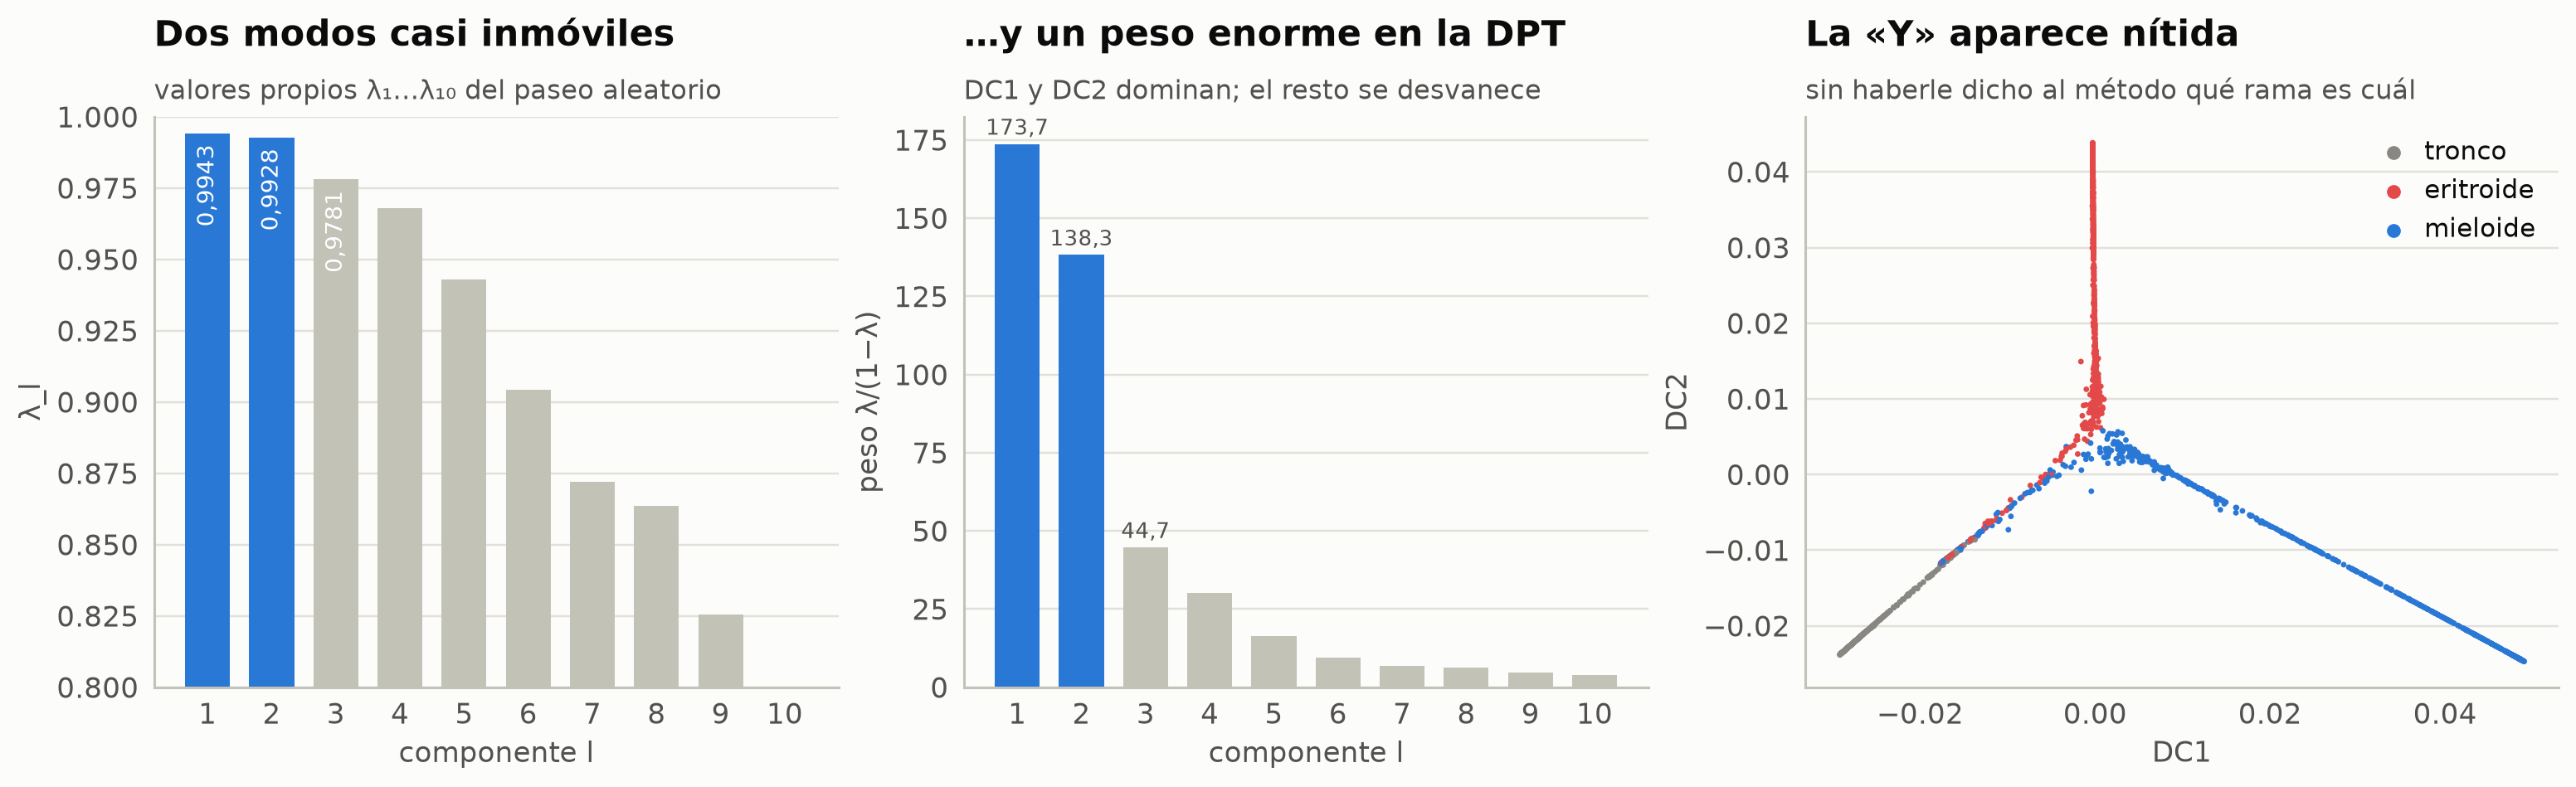

In [8]:
W = lam[1:11] / (1 - lam[1:11])                     # pesos lambda/(1-lambda) de la DPT (sección 4)
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2), gridspec_kw=dict(width_ratios=[1, 1, 1.1]))
ax = axes[0]
ax.bar(np.arange(1, 11), lam[1:11], color=[ec.BLUE] * 2 + [ec.BASELINE] * 8, width=0.7)
ax.set_ylim(0.8, 1.0); ax.set_xticks(range(1, 11)); ax.set_xlabel("componente l"); ax.set_ylabel("λ_l")
for l in (1, 2, 3):
    ax.text(l, lam[l] - 0.004, f"{lam[l]:.4f}".replace(".", ","), ha="center", va="top", rotation=90,
            fontsize=9, color="white")
ec.title(ax, "Dos modos casi inmóviles", "valores propios λ₁…λ₁₀ del paseo aleatorio")
ax = axes[1]
ax.bar(np.arange(1, 11), W, color=[ec.BLUE] * 2 + [ec.BASELINE] * 8, width=0.7)
ax.set_xticks(range(1, 11)); ax.set_xlabel("componente l"); ax.set_ylabel("peso λ/(1−λ)")
for l in (1, 2, 3):
    ax.text(l, W[l - 1] + 3, f"{W[l-1]:.1f}".replace(".", ","), ha="center", fontsize=8.5, color=ec.INK_2)
ec.title(ax, "…y un peso enorme en la DPT", "DC1 y DC2 dominan; el resto se desvanece")
ax = axes[2]
o = np.random.default_rng(2).permutation(NT)
ax.scatter(psi[o, 1], psi[o, 2], c=BRANCH_COLORS[branch[o]], s=5, lw=0)
for b in range(3):
    ax.scatter([], [], c=BRANCH_COLORS[b], s=30, label=BRANCH_NAMES[b])
ax.legend(loc="best", handletextpad=0.2)
ax.set_xlabel("DC1"); ax.set_ylabel("DC2")
ec.title(ax, "La «Y» aparece nítida", "sin haberle dicho al método qué rama es cuál")
plt.show()

> 🔎 **Qué observamos.** Los valores propios caen despacio y los dos primeros están muy por encima del resto en la
> escala de pesos ($173{,}7$ y $138{,}3$ frente a $44{,}7$). En el plano DC1–DC2 la bifurcación aparece como una «Y»
> limpia: cada DC sigue a una rama. El mapa de difusión ha encontrado la topología **sin ningún conocimiento previo**.

### La herradura, otra vez

Comprobemos que el mapa de difusión camina por el arco donde la PC1 lo plegaba.

Spearman(PC1, arco) = -0.010   ·   Spearman(DC1, arco) = -1.000


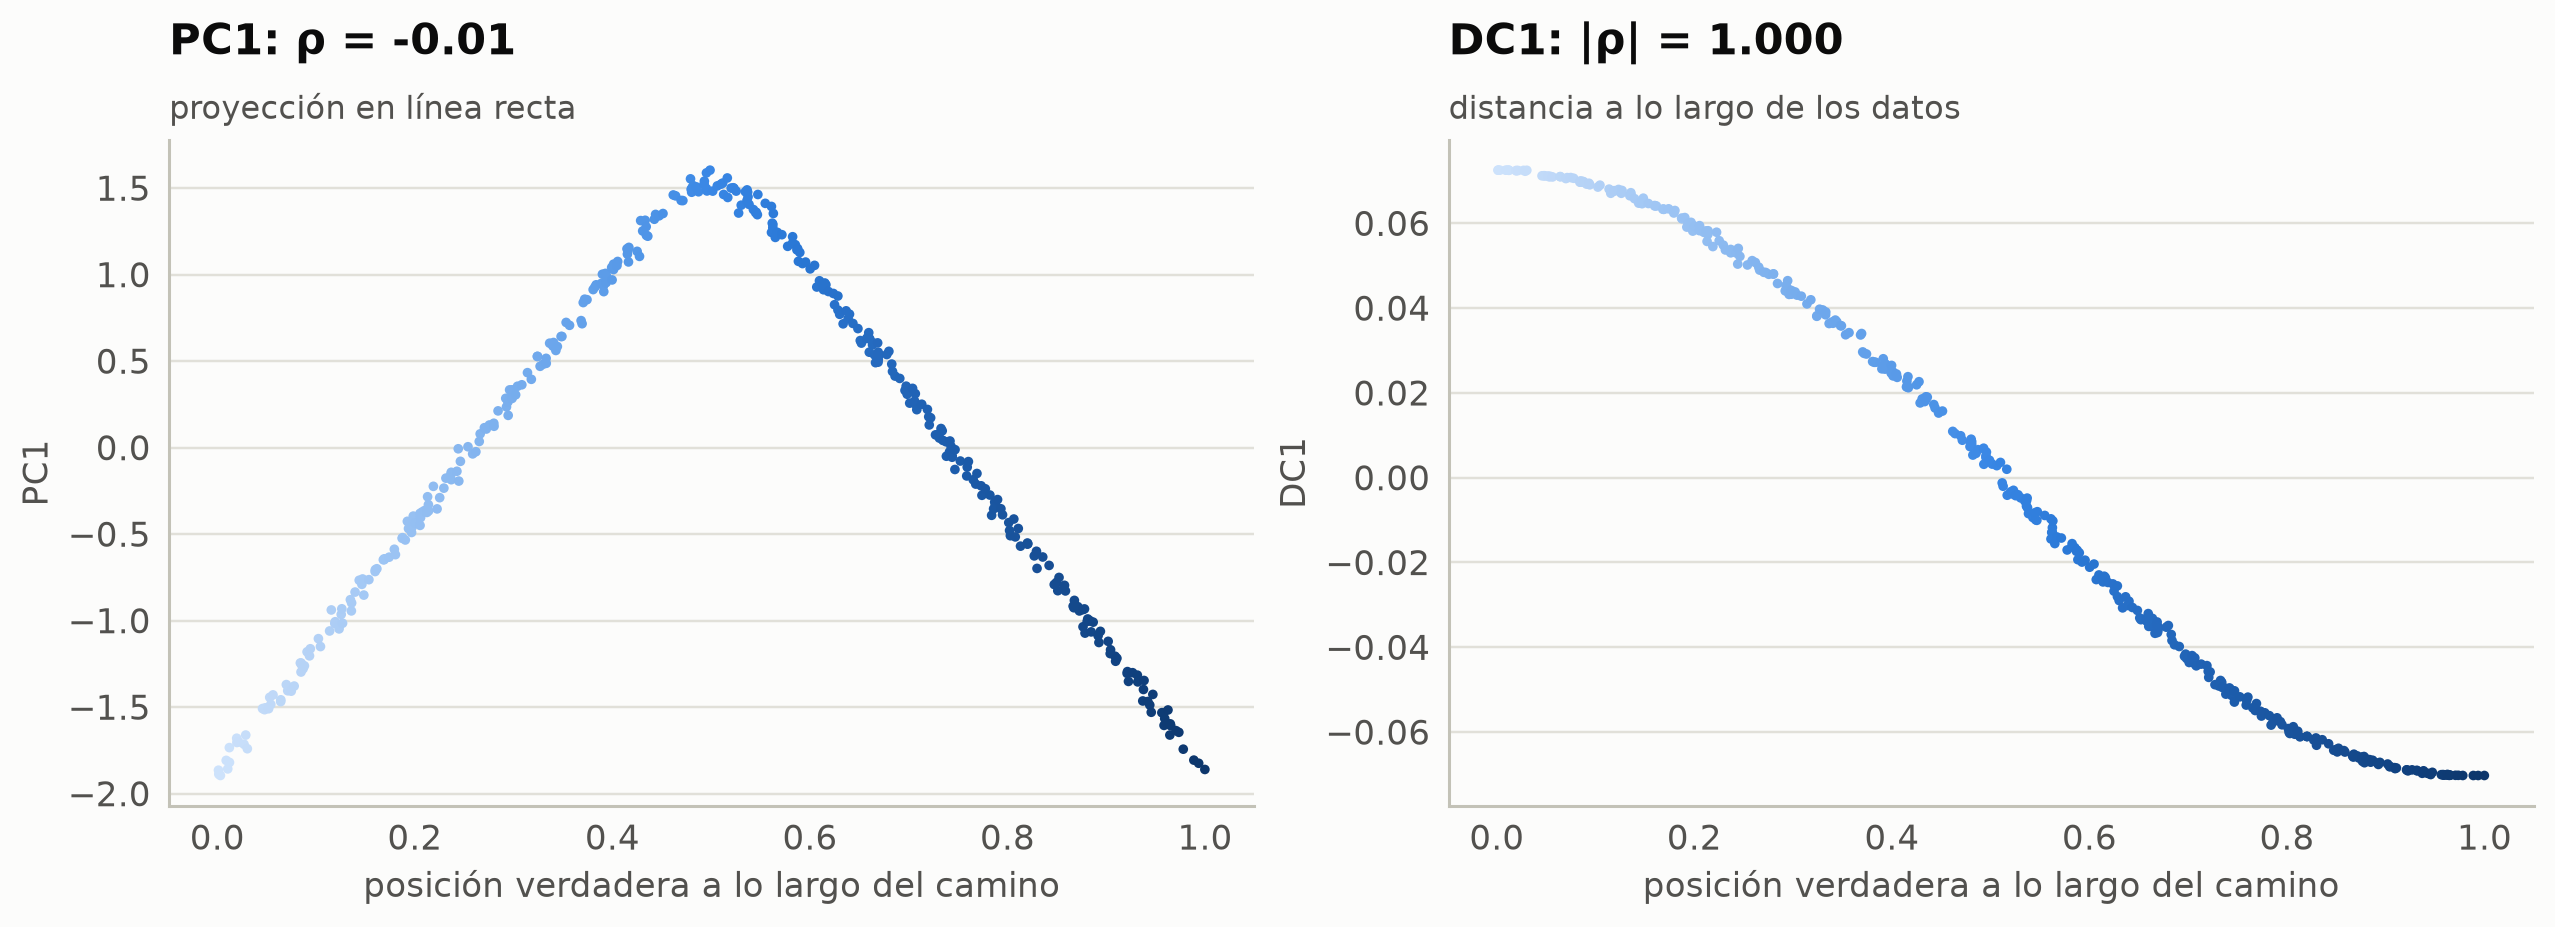

In [9]:
lam_h, psi_h, _ = diffusion_map(H, k=15, n_eig=4)
rho_dc1 = stats.spearmanr(psi_h[:, 1], arc).statistic
print(f"Spearman(PC1, arco) = {rho_pc1:.3f}   ·   Spearman(DC1, arco) = {rho_dc1:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.1), sharex=True)
axes[0].scatter(arc, pc1_h, c=arc, cmap="curso_seq", s=10, lw=0)
axes[0].set_ylabel("PC1"); ec.title(axes[0], f"PC1: ρ = {rho_pc1:.2f}", "proyección en línea recta")
axes[1].scatter(arc, psi_h[:, 1], c=arc, cmap="curso_seq", s=10, lw=0)
axes[1].set_ylabel("DC1"); ec.title(axes[1], f"DC1: |ρ| = {abs(rho_dc1):.3f}", "distancia a lo largo de los datos")
for ax in axes:
    ax.set_xlabel("posición verdadera a lo largo del camino")
plt.show()

> 🔎 **Qué observamos.** El primer componente de difusión es **monótono** con la posición a lo largo del arco (el signo
> de un vector propio es arbitrario, por eso miramos $|\rho|$): el paseo aleatorio no puede saltar por el aire.

### 🎬 La tinta se extiende desde la raíz

Veamos el paseo aleatorio en acción. Colocamos toda la probabilidad en una célula del tronco (la raíz $r$ que
elegiremos formalmente en la sección 4) y aplicamos $T$ una y otra vez: $p_{t+1}=p_t\,T$. El color de cada célula es
$p_t(c)/\pi(c)$ en escala logarítmica, donde $\pi$ es la distribución estacionaria: cuando toda la «Y» se vuelve oscura
y uniforme, el paseo ha olvidado dónde empezó. A la derecha, qué fracción de la probabilidad está en cada rama verdadera.

> 🤔 **Antes de ver la animación, prediga.** ¿Llegará la tinta antes al final de la rama eritroide o al de la
> mieloide? ¿Cuántos pasos harán falta para que se reparta por toda la «Y»?

In [10]:
# Raíz como en el libro: entre las 20 células con mayor puntuación progenitora, la más extrema en DC1
score_prog = Y_sim[:, [gi[g] for g in ("CD34", "GATA2", "MEIS1", "HLF", "KIT")]].mean(1)
cands = np.argsort(-score_prog)[:20]
root = cands[np.argmax(np.abs(psi[cands, 1] - np.median(psi[:, 1])))]
print(f"raíz = célula {root} (tiempo simulado real {t_sim[root]:.3f})")

steps_d = np.unique(np.round(np.geomspace(1, 3000, 44)).astype(int))
steps_d = np.r_[0, steps_d]
p = np.zeros(NT); p[root] = 1.0
snaps, frac_b, t_done = [], [], 0
TT = T_sim.T.tocsr()                                   # p_{t+1} = p_t T  ⇔  p_{t+1}ᵀ = Tᵀ p_tᵀ
for tgt in steps_d:
    while t_done < tgt:
        p = TT @ p; t_done += 1
    snaps.append(p.copy())
    frac_b.append([p[branch == b].sum() for b in range(3)])
frac_b = np.array(frac_b)
pi_stat = np.full(NT, 1 / NT)                           # distribución estacionaria π por iteración de potencias
for _ in range(6000):
    pi_stat = TT @ pi_stat
print(f"{len(steps_d)} cuadros, de t = 0 a t = {steps_d[-1]} pasos")

raíz = célula 1433 (tiempo simulado real 0.007)


40 cuadros, de t = 0 a t = 3000 pasos


![Paseo aleatorio sobre el grafo de 2 000 células simuladas: la probabilidad parte de la raíz del tronco, cruza la bifurcación y se reparte por ambas ramas hasta el equilibrio (color = p_t/π); la distancia de difusión es el tiempo que tarda en llegar](https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/assets/modulo-12-celula-unica/12.4_difusion.gif)

*Paseo aleatorio sobre el grafo de 2 000 células simuladas: la probabilidad parte de la raíz del tronco, cruza la bifurcación y se reparte por ambas ramas hasta el equilibrio (color = p_t/π); la distancia de difusión es el tiempo que tarda en llegar*

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8), gridspec_kw=dict(width_ratios=[1.15, 1]))
fig.get_layout_engine().set(rect=(0, 0, 1, 0.87))
D1, D2 = psi[:, 1], psi[:, 2]
ax = axes[0]
ax.scatter(D1, D2, s=4, c=ec.GRID, lw=0)
sc_d = ax.scatter(D1, D2, s=6, lw=0, c=np.full(NT, 1e-12), cmap="curso_seq", norm=LogNorm(1e-3, 1))
ax.scatter(D1[root], D2[root], marker="*", s=160, c=ec.ORANGE, edgecolors="white", zorder=3)
ax.set_xlabel("DC1"); ax.set_ylabel("DC2")
fig.colorbar(sc_d, ax=ax, label="p_t(c) / π(c)  (relativo al máximo)", shrink=0.85)
ttl = ax.set_title("t = 0", fontsize=12, loc="left")
ax = axes[1]
lines_b = [ax.plot([], [], color=BRANCH_COLORS[b], lw=2.2, label=BRANCH_NAMES[b])[0] for b in range(3)]
ax.set_xscale("symlog", linthresh=1); ax.set_xlim(0, steps_d[-1]); ax.set_ylim(0, 1.02)
ax.set_xlabel("pasos del paseo aleatorio t"); ax.set_ylabel("fracción de la probabilidad")
ax.legend(loc="center left")
fig.text(0.01, 0.99, "La difusión recorre los datos, no el aire", fontsize=15, fontweight="bold", va="top")
fig.text(0.01, 0.935, "p_{t+1} = p_t T sobre el mapa de difusión de la simulación del libro (escala log. de color)",
         fontsize=10.5, color=ec.INK_2, va="top")

def update(f):
    pv = snaps[f] / pi_stat
    pv = pv / pv.max()
    order_ = np.argsort(pv)                            # las más teñidas, encima
    sc_d.set_offsets(np.column_stack([D1[order_], D2[order_]]))
    sc_d.set_array(np.clip(pv[order_], 1e-3, 1))
    for b in range(3):
        lines_b[b].set_data(steps_d[:f + 1], frac_b[:f + 1, b])
    ttl.set_text(f"t = {steps_d[f]} pasos")
    return []

fig.canvas.draw()
with plt.rc_context({"savefig.bbox": None}):
    anim_html = ec.animate(fig, update, frames=len(steps_d), interval=180, name="12.4_difusion")
anim_html

▶️ Ejecute esta celda para ver la animación con controles (la vista previa GIF está en la celda de texto de arriba).

> 🔎 **Qué observamos.** Durante las primeras decenas de pasos la tinta se queda en el tronco; hacia los cien pasos
> cruza la bifurcación y empieza a entrar en ambas ramas; tras miles de pasos la distribución se aproxima a la
> **estacionaria**, en la que ya no importa dónde se empezó. El tiempo que tarda la tinta en llegar a cada célula es
> una medida de su distancia **a lo largo** de la trayectoria: esa es la semilla del pseudotiempo. Y la lentitud de la
> mezcla es justamente lo que dicen $\lambda_1=0{,}9943$ y $\lambda_2=0{,}9928$: un modo con $\lambda$ cercano a 1
> tarda del orden de $1/(1-\lambda)\approx175$ pasos en desvanecerse.

## 4. El pseudotiempo de difusión (DPT)

### Sumar todos los caminos

La animación sugiere medir la distancia por el **tiempo de llegada** de la tinta. Pero un único $t$ es arbitrario:
con $t$ pequeño sólo vemos vecinos; con $t$ grande todo se ha mezclado. Haghverdi et al. (2016) propusieron
**sumar las transiciones de todas las longitudes** a la vez, quitando antes la parte que ya no aporta información (el
estado estacionario).

**Teorema (distancia de pseudotiempo de difusión).** Sea $\phi_0$ la distribución estacionaria del paseo. Se define

$$
M=\sum_{t=1}^{\infty}\left(T-\psi_0\phi_0^{\top}\right)^{t}.
$$

Por la descomposición espectral de $T$,

$$
M=\sum_{l\ge1}\frac{\lambda_l}{1-\lambda_l}\,\psi_l\,\phi_l^{\top},\qquad
\mathrm{dpt}(x,y)^2=\sum_{l\ge1}\left(\frac{\lambda_l}{1-\lambda_l}\right)^{2}\bigl(\psi_l(x)-\psi_l(y)\bigr)^2,
$$

y el **pseudotiempo** de la célula $c$ es $\tau_c=\mathrm{dpt}(r,c)$ para la raíz $r$ (normalizado a $[0,1]$).

| Símbolo | Significado |
|---|---|
| $\phi_0$ | distribución estacionaria del paseo (vector propio por la izquierda de $\lambda_0=1$) |
| $\psi_0\phi_0^\top$ | proyector sobre el estado estacionario: lo que queda cuando el paseo ya olvidó su origen |
| $\phi_l$ | vector propio **por la izquierda** asociado a $\lambda_l$ |
| $M$ | matriz de «transiciones acumuladas» de todas las longitudes |
| $\mathrm{dpt}(x,y)$ | distancia DPT entre las células $x$ e $y$ |
| $\lambda_l/(1-\lambda_l)$ | peso del componente $l$: la suma de la serie geométrica $\sum_{t\ge1}\lambda_l^t$ |

**De dónde salen los pesos.** Cada componente $l$ se multiplica por $\lambda_l$ en cada paso, así que su contribución
acumulada es $\lambda_l+\lambda_l^2+\lambda_l^3+\cdots=\lambda_l/(1-\lambda_l)$. **A mano:** con
$\lambda_1=0{,}9943$ el peso es $0{,}9943/0{,}0057\approx174$ (el libro da $173{,}7$ porque usa el valor sin
redondear, $0{,}994277$); con $\lambda_3=0{,}9781$, $0{,}9781/0{,}0219\approx44{,}7$; con un componente ruidoso de
$\lambda=0{,}5$, apenas $1$. Los procesos lentos y de gran escala reciben un peso enorme y el ruido local se desvanece.

**A mano, una distancia.** Si dos células difieren en $0{,}01$ en DC1 y en $0{,}02$ en DC2 (y nada más),
$\mathrm{dpt}^2=(173{,}7\cdot0{,}01)^2+(138{,}3\cdot0{,}02)^2=3{,}02+7{,}65=10{,}67$, y $\mathrm{dpt}\approx3{,}27$.

La DPT es, por tanto, una **distancia euclídea en el espacio de difusión con cada eje reescalado según su
persistencia**. Tiene dos ventajas sobre los árboles de expansión mínima de Monocle: al promediar sobre **todos los
caminos** es robusta frente al ruido, y las **ramas** se detectan como puntos donde el orden de la DPT medida desde
distintos extremos deja de ser coherente.

### El ejemplo del libro: «Pseudotiempo en una bifurcación simulada»

Sobre 20 PC, con $k=30$ vecinos, usamos los 10 primeros DC. La raíz se elige **con información biológica**: entre las
20 células con mayor puntuación de genes progenitores (*CD34*, *GATA2*, *MEIS1*, *HLF*, *KIT*), la más extrema en
DC1. El libro obtiene $\rho=0{,}978$ (Spearman) entre la DPT y el tiempo simulado; dentro de cada rama, $0{,}983$ y
$0{,}987$, y en el tronco, donde el progreso es más sutil, $0{,}891$.

> 🤔 **Antes de ejecutar, prediga.** ¿En qué parte de la trayectoria esperaría la peor correlación entre la DPT y el
> tiempo verdadero: en el tronco, en la bifurcación o en los extremos de las ramas? ¿Por qué?

In [12]:
def dpt_from(cell, psi, lam, n_dc=10):
    """Distancia DPT de una célula a todas las demás (ecuación del teorema, truncada a n_dc componentes)."""
    w = lam[1:n_dc + 1] / (1 - lam[1:n_dc + 1])
    return np.linalg.norm((psi[:, 1:n_dc + 1] - psi[cell, 1:n_dc + 1]) * w, axis=1)

d_root = dpt_from(root, psi, lam)
dpt = (d_root - d_root.min()) / (d_root.max() - d_root.min())            # tau_c en [0, 1]
rho_all = stats.spearmanr(dpt, t_sim).statistic
print(f"pesos λ/(1−λ) DC1..4 = {np.round(W[:4], 2).tolist()}")
print(f"raíz = {root} (t real = {t_sim[root]:.3f}) · Spearman(DPT, t) = {rho_all:.3f}")
for b in range(3):
    m = branch == b
    print(f"   {BRANCH_NAMES[b]:>9}: n = {m.sum():>3} · Spearman = {stats.spearmanr(dpt[m], t_sim[m]).statistic:.3f}")

pesos λ/(1−λ) DC1..4 = [173.74, 138.3, 44.74, 30.2]
raíz = 1433 (t real = 0.007) · Spearman(DPT, t) = 0.978
      tronco: n = 530 · Spearman = 0.891
   eritroide: n = 780 · Spearman = 0.983
    mieloide: n = 690 · Spearman = 0.987


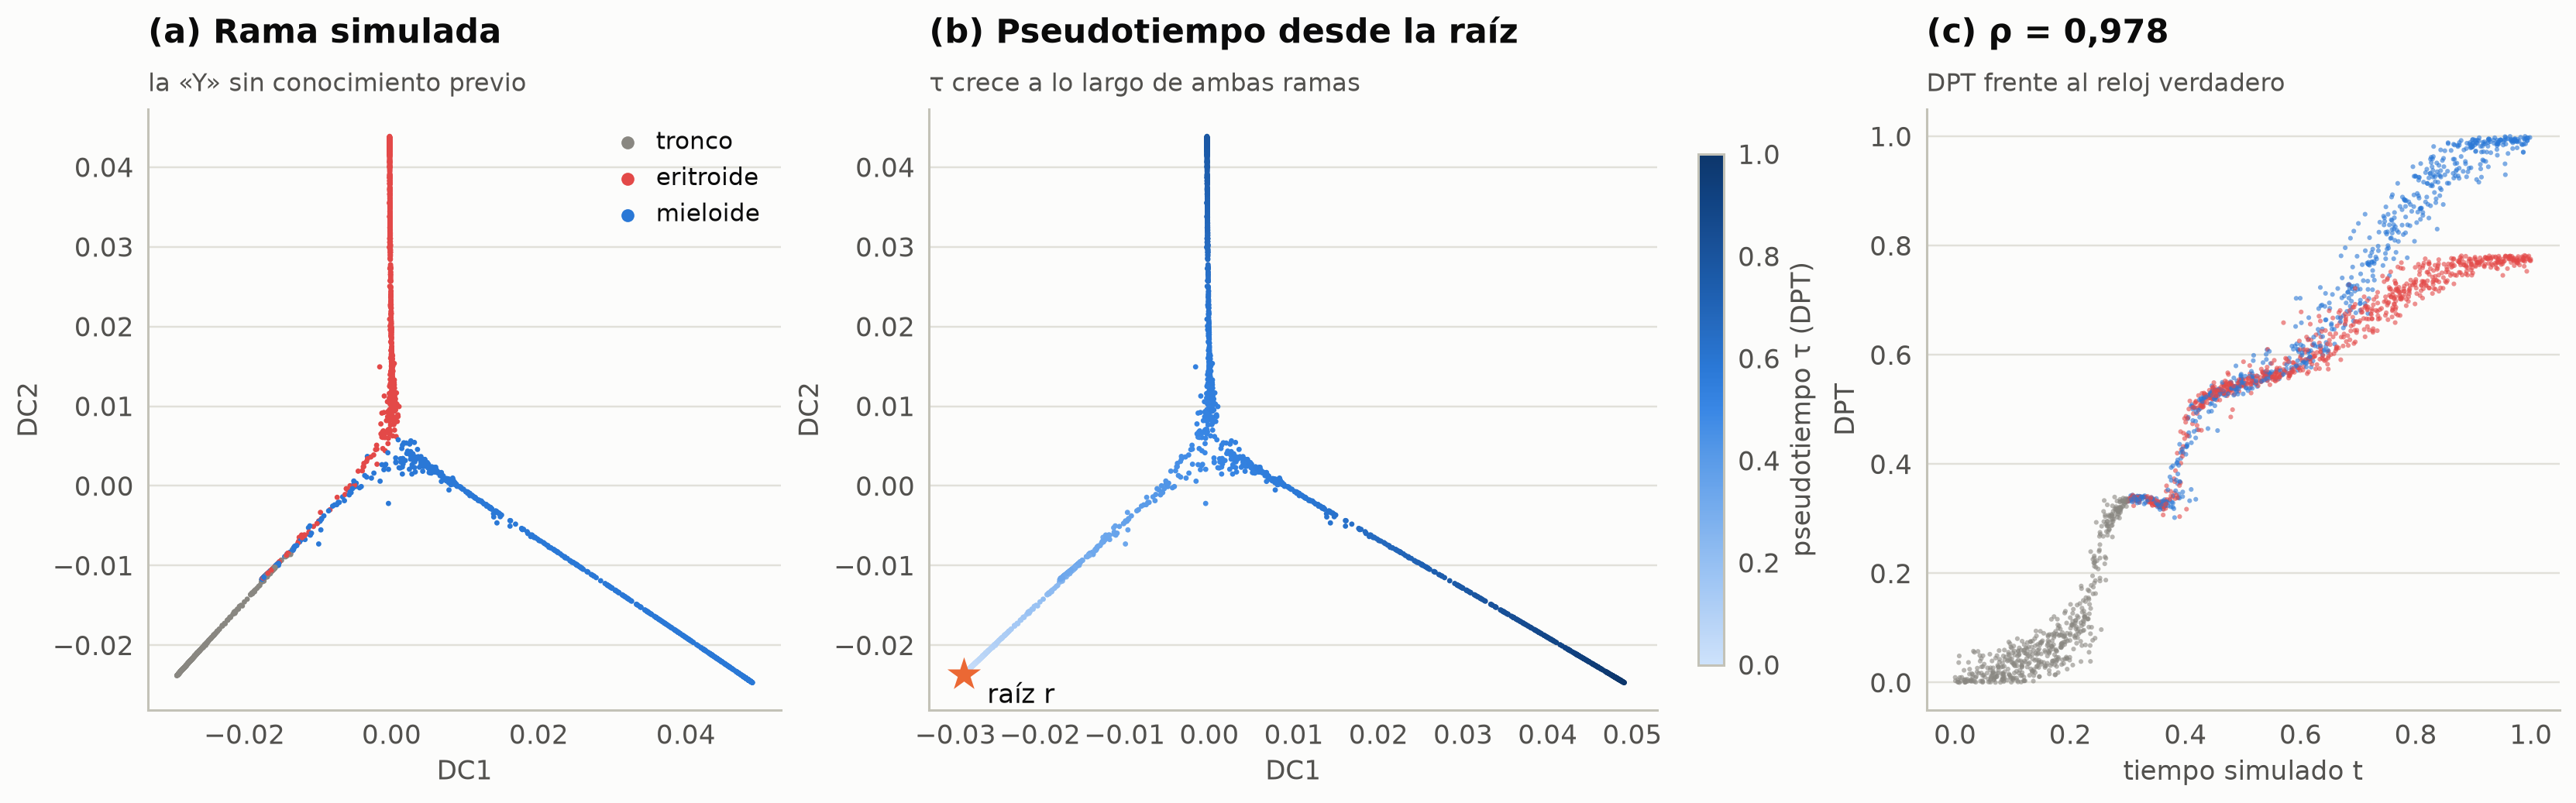

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.6), gridspec_kw=dict(width_ratios=[1, 1.15, 1]))
o = np.random.default_rng(2).permutation(NT)
ax = axes[0]
ax.scatter(D1[o], D2[o], s=5, lw=0, c=BRANCH_COLORS[branch[o]])
for b in range(3):
    ax.scatter([], [], c=BRANCH_COLORS[b], s=30, label=BRANCH_NAMES[b])
ax.legend(loc="best", handletextpad=0.2)
ec.title(ax, "(a) Rama simulada", "la «Y» sin conocimiento previo")
ax = axes[1]
s_ = ax.scatter(D1[o], D2[o], s=5, lw=0, c=dpt[o], cmap="curso_seq")
ax.scatter(D1[root], D2[root], marker="*", s=220, c=ec.ORANGE, edgecolors="white", zorder=3)
ax.annotate("raíz r", (D1[root], D2[root]), xytext=(10, -12), textcoords="offset points", ha="left", color=ec.INK)
fig.colorbar(s_, ax=ax, label="pseudotiempo τ (DPT)", shrink=0.85)
ec.title(ax, "(b) Pseudotiempo desde la raíz", "τ crece a lo largo de ambas ramas")
for ax in axes[:2]:
    ax.set_xlabel("DC1"); ax.set_ylabel("DC2")
ax = axes[2]
ax.scatter(t_sim[o], dpt[o], s=4, lw=0, c=BRANCH_COLORS[branch[o]], alpha=0.6)
ax.set_xlabel("tiempo simulado t"); ax.set_ylabel("DPT")
ec.title(ax, f"(c) ρ = {rho_all:.3f}".replace(".", ","), "DPT frente al reloj verdadero")
plt.show()

> 🔎 **Qué observamos.** (a) El mapa de difusión muestra la «Y». (b) El pseudotiempo parte de la estrella y crece
> hacia los dos extremos. (c) La DPT sigue al tiempo verdadero con $\rho=0{,}978$, pero **no es una recta**: hay
> **mesetas**. La DPT avanza deprisa donde muchos genes cambian a la vez (la bifurcación, donde se apagan los
> progenitores, pican los transitorios y se encienden los reguladores) y despacio donde la expresión cambia poco, y
> alcanza valores máximos distintos en cada rama. **El pseudotiempo mide cambio transcripcional, no reloj.** En el
> tronco, donde sólo descienden lentamente unos pocos genes, la correlación baja a $0{,}891$.

### 🎛️ Explore el espacio de difusión en 3D

Gire la nube con el ratón. Cada punto es una célula; el color es su pseudotiempo. Al pasar el ratón verá su rama
verdadera, su tiempo simulado, su DPT y la expresión de tres genes que cuentan la historia: *CD34* (progenitor),
*GATA1* (eritroide) y *MPO* (mieloide). Busque células con la misma DPT en ramas distintas: tienen el mismo
«progreso», pero destinos diferentes.

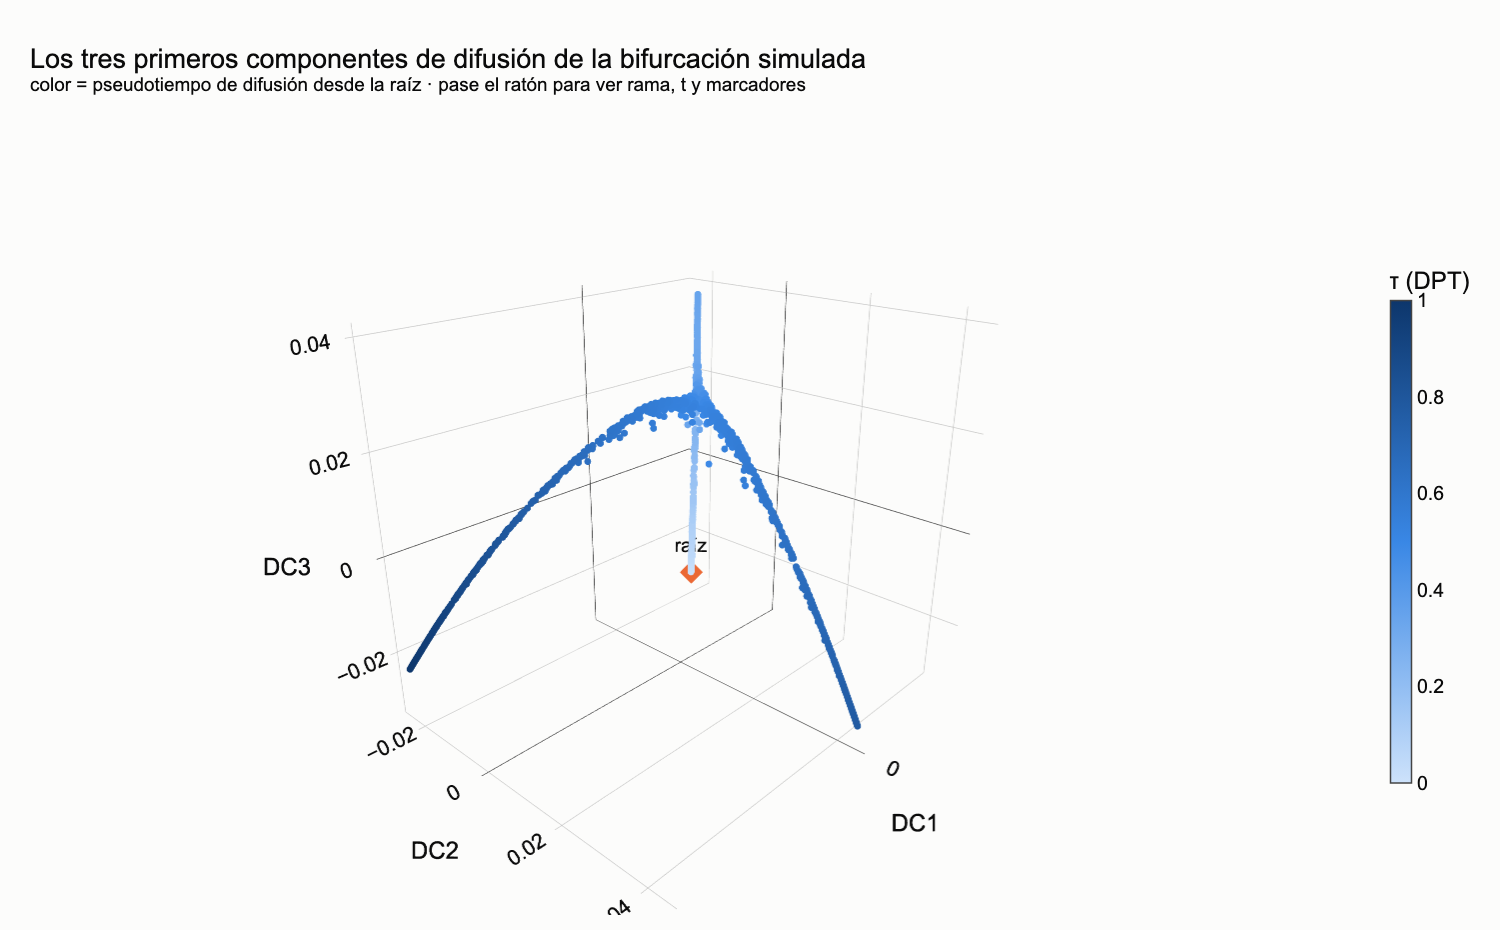

In [14]:
hover = [f"<b>célula {i}</b> · rama simulada: {BRANCH_NAMES[branch[i]]}<br>tiempo simulado t = {t_sim[i]:.2f}"
         f"<br>pseudotiempo τ = {dpt[i]:.2f}<br>CD34 = {Y_sim[i, gi['CD34']]:.2f} · GATA1 = {Y_sim[i, gi['GATA1']]:.2f}"
         f" · MPO = {Y_sim[i, gi['MPO']]:.2f}<br><i>log(1 + CP10k)</i>" for i in range(NT)]
fig = go.Figure(go.Scatter3d(
    x=psi[:, 1], y=psi[:, 2], z=psi[:, 3], mode="markers", text=hover, hovertemplate="%{text}<extra></extra>",
    marker=dict(size=2.6, color=dpt, colorscale=[[0, ec.SEQ_BLUE[0]], [0.5, ec.SEQ_BLUE[6]], [1, ec.SEQ_BLUE[-1]]],
                colorbar=dict(title="τ (DPT)", thickness=14, len=0.7))))
fig.add_trace(go.Scatter3d(x=[psi[root, 1]], y=[psi[root, 2]], z=[psi[root, 3]], mode="markers+text",
                           text=["raíz"], textposition="top center", hoverinfo="skip",
                           marker=dict(size=7, color=ec.ORANGE, symbol="diamond"), showlegend=False))
fig.update_layout(
    title="Los tres primeros componentes de difusión de la bifurcación simulada"
          "<br><sup>color = pseudotiempo de difusión desde la raíz · pase el ratón para ver rama, t y marcadores</sup>",
    scene=dict(xaxis_title="DC1", yaxis_title="DC2", zaxis_title="DC3", camera=dict(eye=dict(x=1.5, y=1.4, z=0.9))),
    height=620, margin=dict(t=90, l=10, r=10, b=10), showlegend=False)
fig.show()

### Detectar las ramas: cuando el orden deja de ser coherente

¿Cómo sabe un método, sin mirar la verdad, que hay una bifurcación? Tomemos dos **extremos**: $e_1$, la célula más
lejana de la raíz en DPT, y $e_2$, la que maximiza la suma de distancias a la raíz y a $e_1$ (la más lejana de ambos a
la vez). En una «Y» son las puntas de las dos ramas. Ahora mida
la DPT de cada célula a ambos extremos:

* En el **tronco**, alejarse de la raíz acerca a la célula a **los dos** extremos a la vez: $\mathrm{dpt}(e_1,c)$ y
  $\mathrm{dpt}(e_2,c)$ **bajan juntas** (pendiente $+1$ en el diagrama).
* En la **rama 1**, avanzar acerca a $e_1$ pero **aleja** de $e_2$: las distancias se mueven en **sentidos
  opuestos** (pendiente $-1$). Lo mismo en la rama 2.

La bifurcación es el punto donde el orden medido desde distintos extremos **deja de ser coherente**. Convirtámoslo
en una regla (una versión simplificada de la de Haghverdi et al., 2016). Sea $\delta_c=\mathrm{dpt}(e_1,c)-\mathrm{dpt}(e_2,c)$.
En el tronco $\delta_c$ es constante (igual a $\delta_r$); una célula que se adentra una distancia $x$ en la rama de
$e_1$ tiene $\mathrm{dpt}(e_1,c)$ menor en $x$ y $\mathrm{dpt}(e_2,c)$ mayor en $x$, así que

$$
x_c=\frac{\delta_r-\delta_c}{2}
$$

mide **cuánto se ha alejado la célula del tronco** hacia $e_1$ ($x_c>0$) o hacia $e_2$ ($x_c<0$). Asignamos al
tronco las células con $|x_c|$ menor que el 5 % del máximo y a cada rama el resto, según el signo.

e1 = 1065 (rama mieloide, t = 0.96) · e2 = 1347 (rama eritroide, t = 0.99)
asignación de segmentos que coincide con la rama verdadera: 85.0%
inferido   rama de e1  rama de e2  tronco
verdad                                   
eritroide           0         683      97
mieloide          486           1     203
tronco              0           0     530


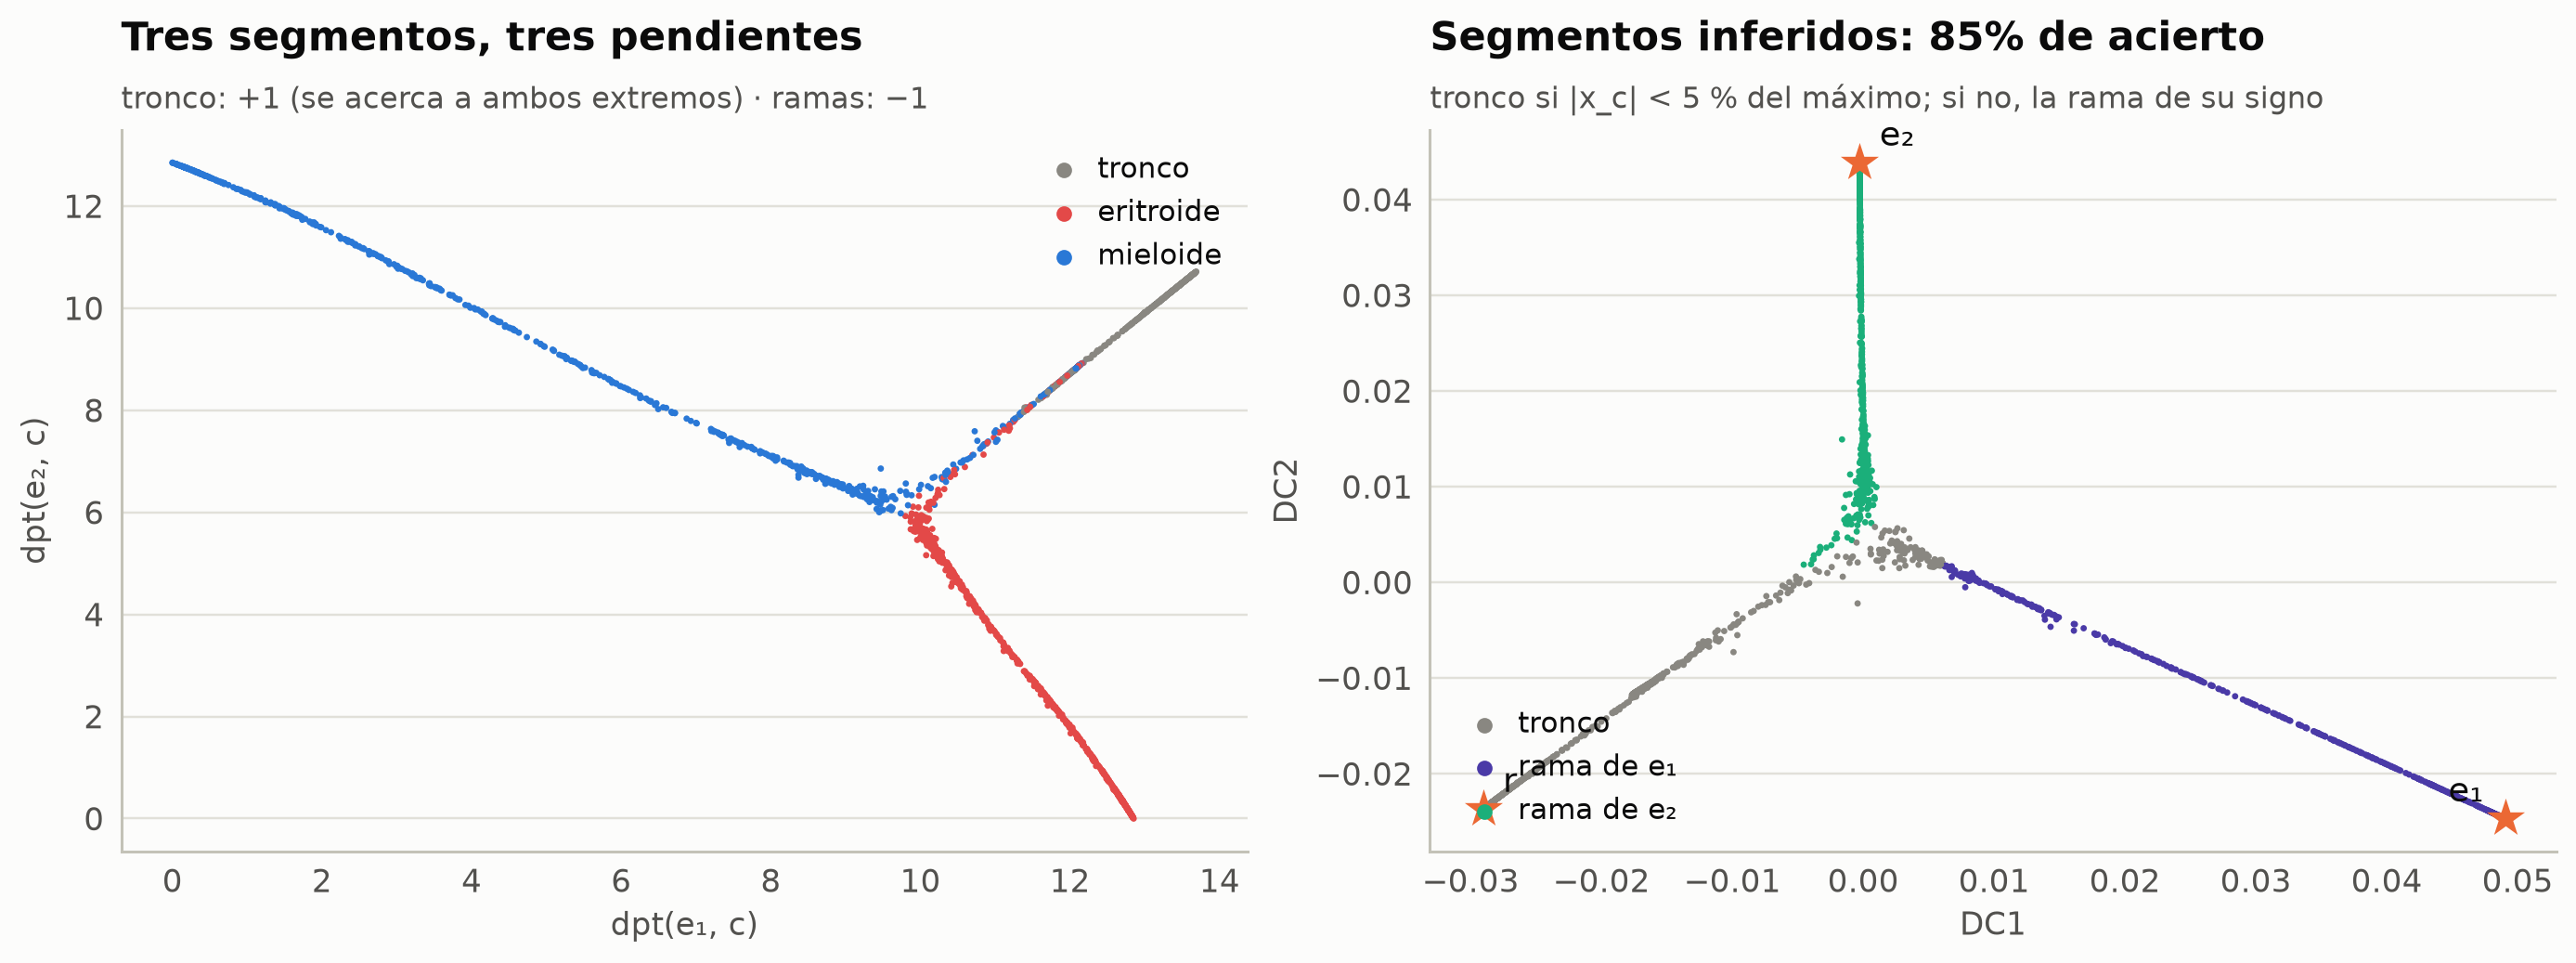

In [15]:
e1 = int(np.argmax(d_root))                          # extremo 1: el más lejano de la raíz
d_e1 = dpt_from(e1, psi, lam)
e2 = int(np.argmax(d_root + d_e1))                   # extremo 2: lejos de la raíz y de e1 a la vez
d_e2 = dpt_from(e2, psi, lam)
delta = d_e1 - d_e2
x_c = (delta[root] - delta) / 2                      # >0: hacia e1 · <0: hacia e2 · ≈0: tronco
thr = 0.05 * np.abs(x_c).max()
seg = np.where(x_c > thr, 1, np.where(x_c < -thr, 2, 0))              # 0 tronco, 1 rama de e1, 2 rama de e2
# ¿qué rama verdadera corresponde a cada extremo?
lab_e = {0: 0, 1: branch[e1], 2: branch[e2]}
seg_branch = np.vectorize(lab_e.get)(seg)
acc = (seg_branch == branch).mean()
print(f"e1 = {e1} (rama {BRANCH_NAMES[branch[e1]]}, t = {t_sim[e1]:.2f}) · e2 = {e2} "
      f"(rama {BRANCH_NAMES[branch[e2]]}, t = {t_sim[e2]:.2f})")
print(f"asignación de segmentos que coincide con la rama verdadera: {acc:.1%}")
print(pd.crosstab(pd.Series(np.array(BRANCH_NAMES)[branch], name="verdad"),
                  pd.Series(np.array(["tronco", "rama de e1", "rama de e2"])[seg], name="inferido")))

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6))
ax = axes[0]
ax.scatter(d_e1[o], d_e2[o], s=5, lw=0, c=BRANCH_COLORS[branch[o]])
ax.set_xlabel("dpt(e₁, c)"); ax.set_ylabel("dpt(e₂, c)")
for b in range(3):
    ax.scatter([], [], c=BRANCH_COLORS[b], s=30, label=BRANCH_NAMES[b])
ax.legend(loc="upper right", handletextpad=0.2)
ec.title(ax, "Tres segmentos, tres pendientes", "tronco: +1 (se acerca a ambos extremos) · ramas: −1")
ax = axes[1]
seg_cols = np.array([ec.MUTED, ec.VIOLET, ec.AQUA])
ax.scatter(D1[o], D2[o], s=5, lw=0, c=seg_cols[seg[o]])
for k_, name_ in enumerate(("tronco", "rama de e₁", "rama de e₂")):
    ax.scatter([], [], c=seg_cols[k_], s=30, label=name_)
ax.legend(loc="lower left", handletextpad=0.2)
for cell, name in ((root, "r"), (e1, "e₁"), (e2, "e₂")):
    ax.scatter(D1[cell], D2[cell], marker="*", s=200, c=ec.ORANGE, edgecolors="white", zorder=3)
    ax.annotate(name, (D1[cell], D2[cell]), xytext=(-20 if cell == e1 else 7, 6), textcoords="offset points",
                fontsize=12, color=ec.INK)
ax.set_xlabel("DC1"); ax.set_ylabel("DC2")
ec.title(ax, f"Segmentos inferidos: {acc:.0%} de acierto", "tronco si |x_c| < 5 % del máximo; si no, la rama de su signo")
plt.show()

> 🔎 **Qué observamos.** En el diagrama $\mathrm{dpt}(e_1,c)$ frente a $\mathrm{dpt}(e_2,c)$ las ramas forman dos
> brazos de pendiente negativa y el tronco uno de pendiente positiva: la incoherencia del orden **es** la
> bifurcación. Con una regla tan simple el tronco se recupera entero y la gran mayoría de las células de rama van a
> su rama; los errores son células **recién bifurcadas** que la regla deja en el tronco, porque aún se han alejado
> muy poco de él: cerca del punto de ramificación la pertenencia es genuinamente ambigua. En Scanpy, `sc.tl.dpt(adata,
> n_branchings=1)` aplica la versión completa del algoritmo.

### 🎬 Las células, una a una, en orden de pseudotiempo

Ahora recorremos las células en orden de $\tau$. A la izquierda se van encendiendo en el mapa de difusión; a la
derecha se dibuja la media de cinco genes en ventanas de pseudotiempo: *CD34* baja en ambas ramas, *GATA1* y *HBB*
suben en la eritroide, *MPO* y *LYZ* en la mieloide. Fíjese en **qué se enciende primero**.

In [16]:
def binned_trend(tau, y, mask, nb_=25):
    """Media de y en nb_ intervalos iguales de pseudotiempo, sólo para las células de mask."""
    edges = np.linspace(0, 1, nb_ + 1)
    idx = np.clip(np.digitize(tau[mask], edges) - 1, 0, nb_ - 1)
    yb = np.array([y[mask][idx == b].mean() if np.any(idx == b) else np.nan for b in range(nb_)])
    return (edges[:-1] + edges[1:]) / 2, yb

# Curvas de las figuras del libro: CD34 en tronco + cada rama; GATA1, HBB en la eritroide; MPO, LYZ en la mieloide
TREND_SPEC = [("CD34", ec.MUTED, 1, "-"), ("CD34", ec.MUTED, 2, "--"), ("GATA1", ec.RED, 1, "-"),
              ("HBB", "#8c1d1c", 1, "-"), ("MPO", ec.BLUE, 2, "-"), ("LYZ", "#0d366b", 2, "-")]
trends = []
for g, col, b, ls in TREND_SPEC:
    xm, yb = binned_trend(dpt, Y_sim[:, gi[g]], (branch == 0) | (branch == b))
    trends.append((g, col, b, ls, xm, yb))
tau_frames = np.linspace(0.02, 1.0, 40)

![Las células simuladas se encienden en orden de pseudotiempo; a la derecha, la expresión media de CD34, GATA1, HBB, MPO y LYZ: los reguladores de cada linaje (GATA1, MPO) se activan antes que los efectores (HBB, LYZ)](https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/assets/modulo-12-celula-unica/12.4_pseudotiempo.gif)

*Las células simuladas se encienden en orden de pseudotiempo; a la derecha, la expresión media de CD34, GATA1, HBB, MPO y LYZ: los reguladores de cada linaje (GATA1, MPO) se activan antes que los efectores (HBB, LYZ)*

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), gridspec_kw=dict(width_ratios=[1, 1.2]))
fig.get_layout_engine().set(rect=(0, 0, 1, 0.87))
ax = axes[0]
ax.scatter(D1, D2, s=4, c=ec.GRID, lw=0)
sc_on = ax.scatter([], [], s=6, lw=0, c=[], cmap="curso_seq", vmin=0, vmax=1)
ax.set_xlim(ax.get_xlim()); ax.set_ylim(ax.get_ylim())
ax.set_xlabel("DC1"); ax.set_ylabel("DC2")
ttl2 = ax.set_title("", fontsize=12, loc="left")
ax = axes[1]
tr_lines = []
for g, col, b, ls, xm, yb in trends:
    lbl = None if (g == "CD34" and b == 2) else (g if g != "CD34" else "CD34 (— eritroide, -- mieloide)")
    tr_lines.append(ax.plot([], [], color=col, ls=ls, lw=2.2, label=lbl)[0])
ax.set_xlim(0, 1); ax.set_ylim(0, np.nanmax([t[5] for t in trends]) * 1.3)
ax.set_xlabel("pseudotiempo τ (DPT)"); ax.set_ylabel("log(1 + CP10k) medio")
ax.legend(loc="upper center", ncol=3, fontsize=9, bbox_to_anchor=(0.5, 1.0))
vline = ax.axvline(0, color=ec.ORANGE, lw=1.2)
fig.text(0.01, 0.99, "Recorrer las células en orden de pseudotiempo", fontsize=15, fontweight="bold", va="top")
fig.text(0.01, 0.935, "bifurcación simulada del libro · reguladores antes que efectores en cada rama",
         fontsize=10.5, color=ec.INK_2, va="top")

def update(f):
    tau = tau_frames[f]
    on = dpt <= tau
    sc_on.set_offsets(np.column_stack([D1[on], D2[on]]))
    sc_on.set_array(dpt[on])
    for ln, (g, col, b, ls, xm, yb) in zip(tr_lines, trends):
        k = xm <= tau
        ln.set_data(xm[k], yb[k])
    vline.set_xdata([tau, tau])
    ttl2.set_text(f"τ ≤ {tau:.2f} · {on.sum()} de {NT} células")
    return []

fig.canvas.draw()
with plt.rc_context({"savefig.bbox": None}):
    anim_html = ec.animate(fig, update, frames=len(tau_frames), interval=160, name="12.4_pseudotiempo")
anim_html

▶️ Ejecute esta celda para ver la animación con controles (la vista previa GIF está en la celda de texto de arriba).

> 🔎 **Qué observamos.** Las células se encienden desde la raíz, recorren el tronco y se reparten entre las dos ramas.
> Mientras tanto *CD34* cae, y en cada rama el **regulador** (*GATA1*, *MPO*) sube antes que el **efector** (*HBB*,
> *LYZ*): el orden temporal que impusimos en la simulación reaparece en el pseudotiempo sin haberlo mirado.

> ✅ **Compruebe su comprensión.** Si eligiera como raíz la célula $e_1$ (la punta de una rama), ¿qué pasaría con el
> pseudotiempo de las células del tronco y de la otra rama? *(La DPT seguiría siendo una distancia válida, pero el
> «progreso» se leería al revés en la rama de $e_1$ y el tronco quedaría a mitad de camino: la DPT ordena, pero no
> orienta. La dirección la pone usted al elegir la raíz, o la velocidad de ARN de la sección 7.)*

## 5. PAGA: el mapa de metro de las células

### Del plano de calles al plano del metro

El plano de calles de una ciudad tiene todos los detalles, pero para moverse en metro basta un esquema: estaciones y
líneas que las unen. Una trayectoria célula a célula es el plano de calles; cuando hay muchas ramas se vuelve
ilegible. Además, los métodos que ajustan un **árbol** imponen esa topología aunque los datos no la tengan.

La **abstracción de grafos basada en particiones** (PAGA; Wolf et al., 2019) toma un camino intermedio: agrupa las
células (con Louvain o Leiden, lección 12.3) y construye un grafo más grueso cuyos **nodos son los grupos** y cuyas
**aristas pesan según la conectividad** entre ellos en el grafo kNN. La conectividad compara el número de aristas
**observadas** entre dos grupos con el **esperado** si las aristas se repartieran al azar; en la versión didáctica
del libro,

$$
c_{ab}=\min\left\{1,\;\frac{e_{ab}}{k_a k_b/2m}\right\}.
$$

| Símbolo | Significado |
|---|---|
| $e_{ab}$ | número de aristas del grafo kNN entre células del grupo $a$ y células del grupo $b$ |
| $k_a$ | suma de los grados de las células del grupo $a$ |
| $m$ | número total de aristas del grafo |
| $k_ak_b/2m$ | aristas esperadas entre $a$ y $b$ si se cablearan al azar respetando los grados (como en la modularidad) |
| $c_{ab}$ | conectividad: 1 = tan conectados como el azar (o más); cerca de 0 = casi no se tocan |

**A mano.** Dos grupos con grados totales $k_a=3\,000$ y $k_b=4\,000$ en un grafo de $m=20\,000$ aristas: al azar
esperaríamos $3\,000\cdot4\,000/40\,000=300$ aristas entre ellos. Si observamos $120$, $c_{ab}=120/300=0{,}40$: se
tocan claramente. Si observamos 6, $c_{ab}=0{,}02$ y la arista se descarta.

Las aristas con conectividad baja se eliminan, y el resultado es un «mapa de metro» que muestra **qué grupos se
tocan**. PAGA **no presupone que la topología sea un árbol**: si los datos contienen un ciclo o componentes
desconectados, el grafo lo refleja. Además, las posiciones de los nodos de PAGA sirven para inicializar UMAP
(`sc.tl.umap(adata, init_pos="paga")`), lo que hace que el mapa respete la topología global.

> ⚠️ **Aviso.** Esta fórmula es la versión didáctica del libro. Scanpy (`sc.tl.paga`) usa una medida emparentada
> pero distinta (compara las aristas observadas con las esperadas bajo un modelo binomial y la normaliza de otra
> manera), así que sus números no coinciden uno a uno con los nuestros.

Reproducimos el libro: grafo kNN con $k=15$ sobre las 20 PC, Louvain con resolución $0{,}6$ (semilla 1) y la
conectividad anterior. El libro obtiene 6 grupos de 424, 390, 327, 308, 281 y 270 células, y seis aristas por encima
de $0{,}05$: 0–3: 0,13; 1–4: 0,24; 2–5: 0,24; 3–4: 0,08; 3–5: 0,18; 4–5: 0,40.

In [18]:
def knn_graph(Z, k=15):
    """Grafo kNN simétrico y no ponderado (lección 12.3)."""
    idx = NearestNeighbors(n_neighbors=k + 1).fit(Z).kneighbors(Z, return_distance=False)
    n = Z.shape[0]
    A = sparse.csr_matrix((np.ones(n * k), (np.repeat(np.arange(n), k), idx[:, 1:].ravel())), shape=(n, n))
    return ((A + A.T) > 0).astype(float)

def louvain(A, res=1.0, seed=0):
    com = nx.community.louvain_communities(nx.from_scipy_sparse_array(A), resolution=res, seed=seed)
    lab = np.zeros(A.shape[0], int)
    for c, s in enumerate(sorted(com, key=len, reverse=True)):   # grupo 0 = el más grande
        lab[list(s)] = c
    return lab

def paga_connectivity(A, lab):
    """c_ab = min(1, e_ab / (k_a k_b / 2m)) del libro."""
    Kc = lab.max() + 1
    Ac = A.tocoo()
    E = np.zeros((Kc, Kc))
    np.add.at(E, (lab[Ac.row], lab[Ac.col]), 1)
    E = (E + E.T) / 2                      # E[a, b] = aristas entre a y b
    k_deg = E.sum(1)                       # suma de grados por grupo
    m_tot = E.sum() / 2
    conn = np.minimum(np.clip(E / (np.outer(k_deg, k_deg) / (2 * m_tot)), 0, None), 1.0)
    np.fill_diagonal(conn, 0)
    return conn, E, k_deg, m_tot

A_sim = knn_graph(pcs_sim, 15)
lab_sim = louvain(A_sim, 0.6, seed=1)
conn_sim, E_sim, kdeg_sim, m_sim = paga_connectivity(A_sim, lab_sim)
KS = lab_sim.max() + 1
sizes_sim = np.bincount(lab_sim)
edges_sim = [(a, b, conn_sim[a, b]) for a in range(KS) for b in range(a + 1, KS) if conn_sim[a, b] > 0.05]
print(f"grafo kNN: {int(m_sim)} aristas · {KS} grupos de tamaños {sizes_sim.tolist()}")
print("aristas con c_ab > 0,05:", "; ".join(f"{a}–{b}: {c:.2f}" for a, b, c in edges_sim))
a_, b_ = 4, 5
print(f"a mano para 4–5: e_ab = {E_sim[a_, b_]:.0f}, k_a = {kdeg_sim[a_]:.0f}, k_b = {kdeg_sim[b_]:.0f}, "
      f"esperado = {kdeg_sim[a_] * kdeg_sim[b_] / (2 * m_sim):.1f} → c = {conn_sim[a_, b_]:.2f}")
dpt_cl = np.array([np.median(dpt[lab_sim == c]) for c in range(KS)])
branch_cl = [BRANCH_NAMES[np.bincount(branch[lab_sim == c], minlength=3).argmax()] for c in range(KS)]
print("rama mayoritaria por grupo:", dict(enumerate(branch_cl)))

grafo kNN: 23678 aristas · 6 grupos de tamaños [424, 390, 327, 308, 281, 270]
aristas con c_ab > 0,05: 0–3: 0.13; 1–4: 0.24; 2–5: 0.24; 3–4: 0.08; 3–5: 0.18; 4–5: 0.40
a mano para 4–5: e_ab = 354, k_a = 6671, k_b = 6266, esperado = 882.7 → c = 0.40
rama mayoritaria por grupo: {0: 'tronco', 1: 'eritroide', 2: 'mieloide', 3: 'tronco', 4: 'eritroide', 5: 'mieloide'}


> 🔎 **Qué observamos.** Salen los mismos seis grupos y las mismas seis aristas del libro (el algoritmo de Louvain de
> NetworkX es determinista con la semilla fija; con otra versión de NetworkX podrían cambiar ligeramente, y por eso
> imprimimos en lugar de suponer). La cuenta a mano de la arista 4–5 muestra de dónde sale su $0{,}40$: la más fuerte
> del grafo.

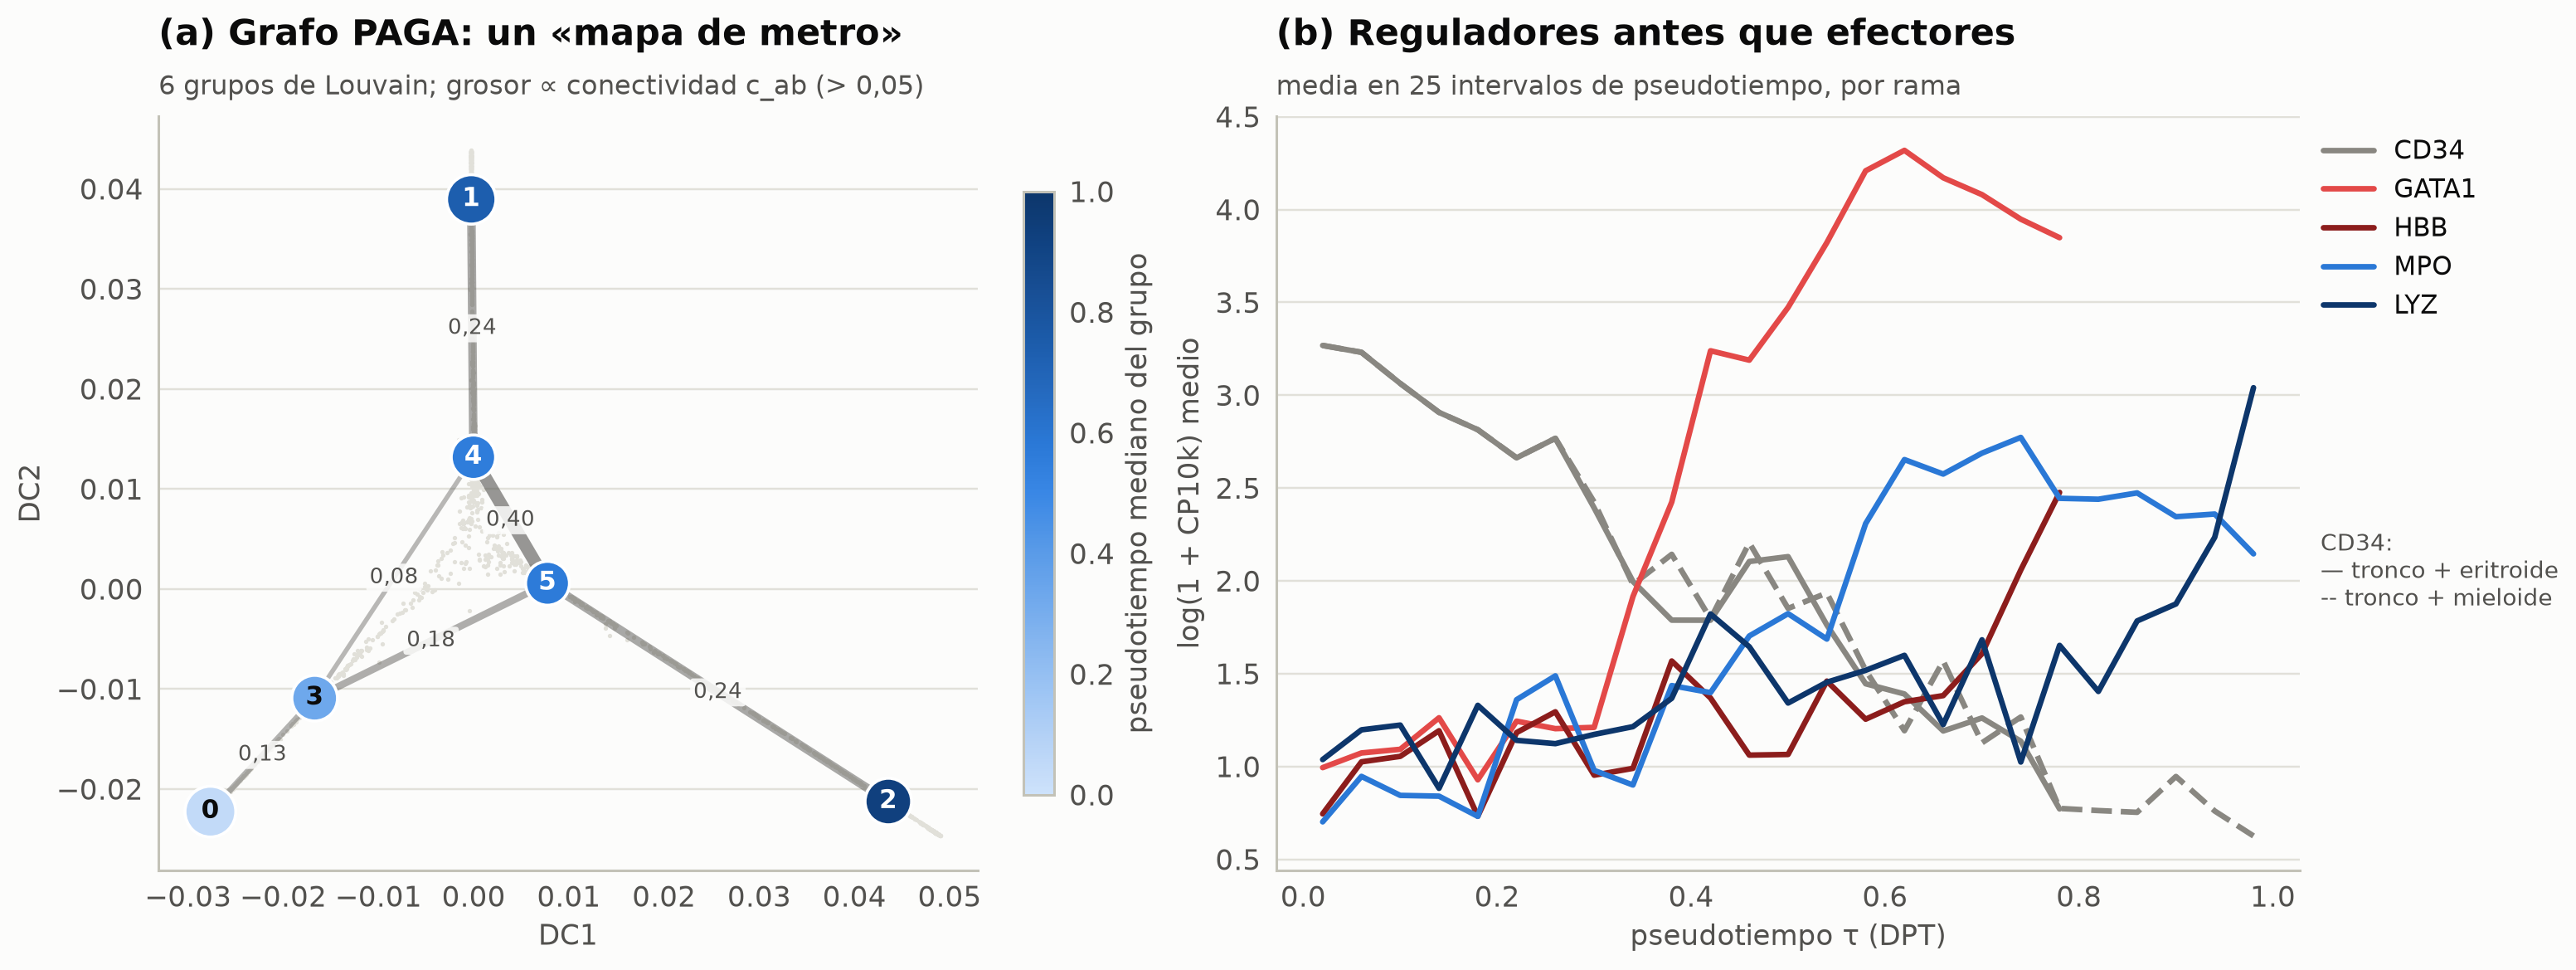

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.2), gridspec_kw=dict(width_ratios=[1, 1.25]))
ax = axes[0]
pos = np.array([[np.median(D1[lab_sim == c]), np.median(D2[lab_sim == c])] for c in range(KS)])
ax.scatter(D1, D2, s=3, lw=0, c=ec.GRID, zorder=0)
for a, b, cc in edges_sim:
    ax.plot(pos[[a, b], 0], pos[[a, b], 1], color=ec.INK_2, lw=1 + 10 * cc, alpha=0.35 + 0.6 * cc, zorder=1)
    mid = pos[[a, b]].mean(0)
    ax.text(mid[0], mid[1], f"{cc:.2f}".replace(".", ","), fontsize=8.5, color=ec.INK_2, ha="center", va="center",
            bbox=dict(boxstyle="round,pad=0.15", fc=ec.SURFACE, ec="none", alpha=0.85), zorder=2)
scn = ax.scatter(pos[:, 0], pos[:, 1], s=120 + sizes_sim / 1.5, c=dpt_cl, cmap="curso_seq", vmin=0, vmax=1,
                 edgecolors="white", linewidths=1.2, zorder=3)
for c in range(KS):
    ax.text(pos[c, 0], pos[c, 1], str(c), fontsize=10, fontweight="bold", ha="center", va="center", zorder=4,
            color="white" if dpt_cl[c] > 0.35 else ec.INK)
fig.colorbar(scn, ax=ax, label="pseudotiempo mediano del grupo", shrink=0.8)
ax.set_xlabel("DC1"); ax.set_ylabel("DC2")
ec.title(ax, "(a) Grafo PAGA: un «mapa de metro»", "6 grupos de Louvain; grosor ∝ conectividad c_ab (> 0,05)")
ax = axes[1]
for g, col, b, ls, xm, yb in trends:
    ok_ = np.isfinite(yb)
    lbl = None if (g == "CD34" and b == 2) else g
    ax.plot(xm[ok_], yb[ok_], color=col, ls=ls, lw=2.2, label=lbl)
ax.set_xlabel("pseudotiempo τ (DPT)"); ax.set_ylabel("log(1 + CP10k) medio")
ax.legend(loc="upper left", bbox_to_anchor=(1.0, 1.0))
ax.text(1.02, 0.45, "CD34:\n— tronco + eritroide\n-- tronco + mieloide", transform=ax.transAxes,
        fontsize=9, color=ec.INK_2, va="top")
ec.title(ax, "(b) Reguladores antes que efectores", "media en 25 intervalos de pseudotiempo, por rama")
plt.show()

> 🔎 **Qué observamos.** (a) El grupo 0, que contiene la raíz, se une al 3, y éste a los grupos 4 y 5, que forman un
> **triángulo** en la zona de la bifurcación (la arista 4–5, con conectividad $0{,}40$, es la más fuerte) y continúan
> hacia los extremos 1 y 2. PAGA no «decidió» que fuera un árbol: el triángulo refleja que las células recién
> bifurcadas todavía se parecen entre sí. (b) *CD34* desciende a lo largo de ambas ramas; *GATA1* sube antes que
> *HBB* en la eritroide y *MPO* antes que *LYZ* en la mieloide, reproduciendo el orden simulado.

### Genes a lo largo del pseudotiempo

Una vez ordenadas las células, el análisis más frecuente es buscar **genes cuya expresión cambia con el
pseudotiempo**, ajustando curvas suaves (*splines* o modelos aditivos generalizados) a la expresión frente a $\tau$
dentro de cada rama. Una forma muy visual de verlo es un **mapa de calor** con las células ordenadas por $\tau$: el
tronco en el centro, la rama eritroide hacia la derecha y la mieloide hacia la izquierda (en espejo).

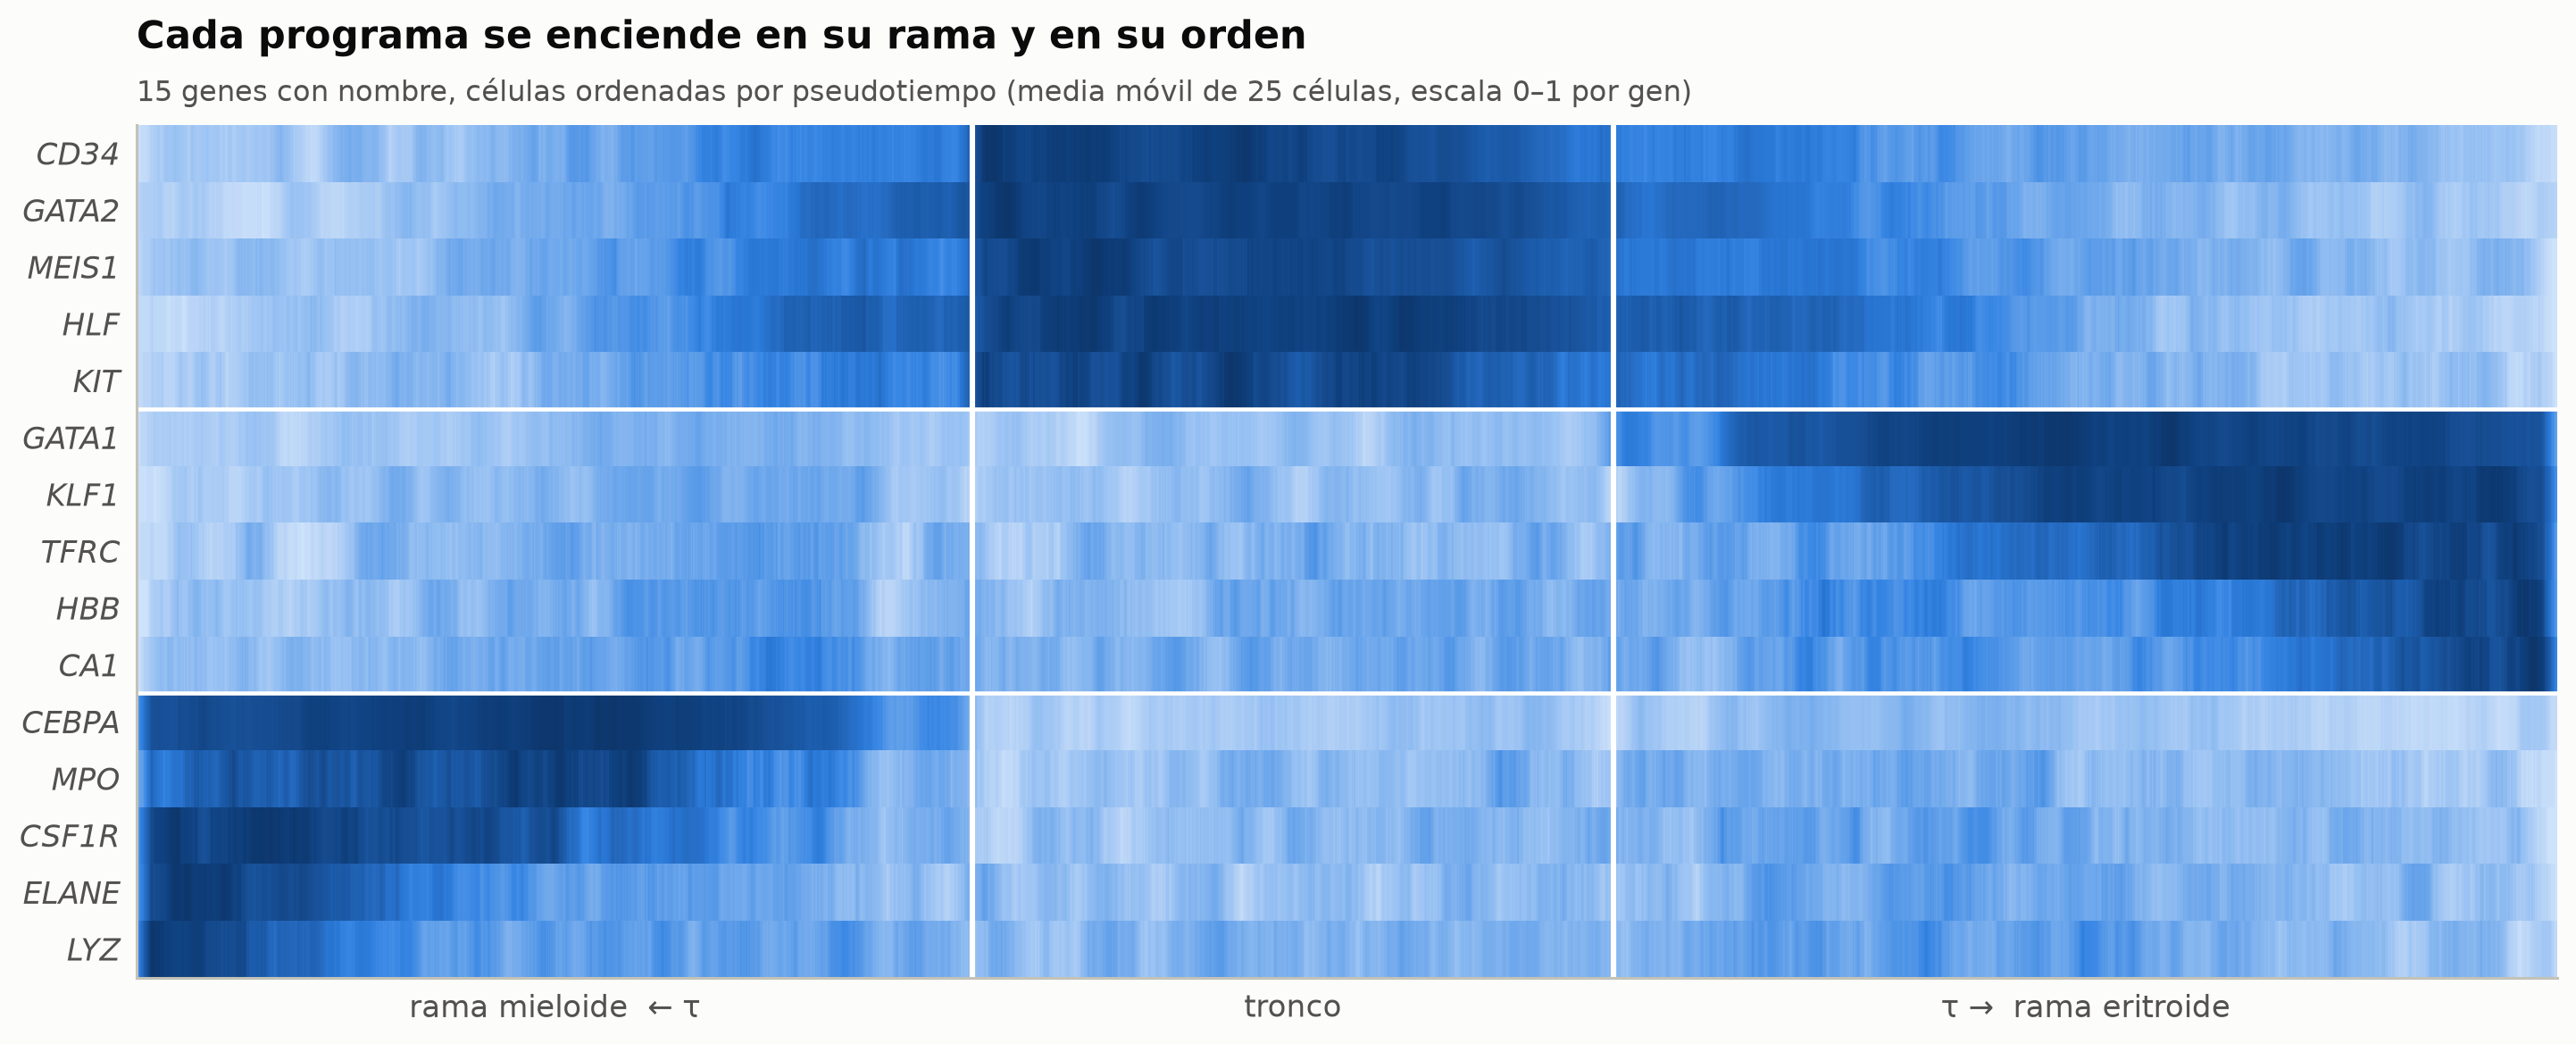

In [20]:
# Orden «en espejo»: rama mieloide (τ decreciente) | tronco | rama eritroide (τ creciente)
ord_m = np.where(branch == 2)[0][np.argsort(-dpt[branch == 2])]
ord_t = np.where(branch == 0)[0][np.argsort(dpt[branch == 0])]
ord_e = np.where(branch == 1)[0][np.argsort(dpt[branch == 1])]
order_mirror = np.r_[ord_m, ord_t, ord_e]
show = ["CD34", "GATA2", "MEIS1", "HLF", "KIT", "GATA1", "KLF1", "TFRC", "HBB", "CA1",
        "CEBPA", "MPO", "CSF1R", "ELANE", "LYZ"]
Mh = Y_sim[order_mirror][:, [gi[g] for g in show]]
# suavizado con media móvil de 25 células y escala 0-1 por gen
kern = np.ones(25) / 25
Ms = np.column_stack([np.convolve(Mh[:, j], kern, mode="same") for j in range(Mh.shape[1])])
Ms = (Ms - Ms.min(0)) / (Ms.max(0) - Ms.min(0) + 1e-9)

fig, ax = plt.subplots(figsize=(13, 5.2))
ax.imshow(Ms.T, aspect="auto", cmap="curso_seq", interpolation="nearest")
ax.set_yticks(range(len(show))); ax.set_yticklabels(show, fontstyle="italic")
n1, n2 = len(ord_m), len(ord_m) + len(ord_t)
for xline in (n1, n2):
    ax.axvline(xline, color="white", lw=2)
ax.set_xticks([n1 / 2, (n1 + n2) / 2, (n2 + len(order_mirror)) / 2])
ax.set_xticklabels(["rama mieloide  ← τ", "tronco", "τ →  rama eritroide"], fontsize=11)
for yline in (4.5, 9.5):
    ax.axhline(yline, color="white", lw=1.5)
ax.grid(False)
ec.title(ax, "Cada programa se enciende en su rama y en su orden",
         "15 genes con nombre, células ordenadas por pseudotiempo (media móvil de 25 células, escala 0–1 por gen)")
plt.show()

> 🔎 **Qué observamos.** Los cinco genes progenitores (arriba) están encendidos en el tronco y se apagan hacia ambos
> lados; los eritroides se encienden sólo a la derecha, en **escalera** (*GATA1* → *KLF1* → *TFRC* → *HBB* → *CA1*),
> y los mieloides sólo a la izquierda, con su propia escalera. En datos reales, ese orden es una **hipótesis sobre
> causalidad** (¿el regulador temprano activa al tardío?) que hay que validar experimentalmente, por ejemplo con
> perturbaciones CRISPR.

## 6. Datos reales: la hematopoyesis mieloide del ratón (Paul et al., 2015)

### El experimento

**Paul et al. (2015)** aislaron por citometría de flujo **progenitores mieloides** de médula ósea de ratón (células
Lin⁻ c-Kit⁺ Sca-1⁻, es decir, sin marcadores de linaje maduro, con el receptor Kit y **sin** Sca-1: la población
que contiene los progenitores CMP, GMP y MEP, pero **no** las células madre hematopoyéticas, que son Sca-1⁺) y
secuenciaron unas **2 700 células** individuales con MARS-seq. Agruparon las células en **19 grupos** transcripcionales
y los anotaron: seis eritroides (1Ery–6Ery), MEP, megacariocitos (8Mk), GMP (9GMP, 10GMP), células dendríticas,
basófilos, monocitos, neutrófilos, eosinófilos y un pequeño grupo linfoide. Su conclusión principal fue que muchos
progenitores ya están **transcripcionalmente comprometidos** con un único linaje, más de lo que sugerían los
marcadores de superficie clásicos.

Es el conjunto de referencia con el que se presentaron la DPT y PAGA en Scanpy, y un buen escenario: dos grandes
destinos (eritroide y granulocítico-monocítico) que parten de progenitores comunes.

### Cargar los datos

Scanpy trae una función que lo descarga (`sc.datasets.paul15()`); para no depender de la red guardamos una copia
compacta en el repositorio del curso (`data/124_paul15.npz`: la matriz de cuentas dispersa de 2 730 células × 3 451
genes, los nombres de los genes y la anotación de los 19 grupos).

In [21]:
def load_paul15():
    """1) copia del curso en ../data; 2) sc.datasets.paul15() (red); 3) copia del curso en GitHub."""
    local = os.path.join("..", "data", "124_paul15.npz")
    if not os.path.exists(local):
        try:
            a = sc.datasets.paul15()
            return ad.AnnData(sparse.csr_matrix(a.X.astype(np.float32)), obs=a.obs[["paul15_clusters"]].copy(),
                              var=pd.DataFrame(index=a.var_names.astype(str)))
        except Exception as err:
            print("sc.datasets.paul15() falló (", err, ") → copia del curso en GitHub")
            local = course_file("124_paul15.npz")
    z = np.load(local)
    X = sparse.csr_matrix((z["data"].astype(np.float32), z["indices"], z["indptr"]), shape=tuple(z["shape"]))
    cats = sorted(set(z["clusters"]), key=lambda s: int("".join(ch for ch in s if ch.isdigit())))
    obs = pd.DataFrame({"paul15_clusters": pd.Categorical(z["clusters"], categories=cats)})
    obs.index = obs.index.astype(str)
    return ad.AnnData(X, obs=obs, var=pd.DataFrame(index=z["genes"]))

adata = load_paul15()
adata.obs["paul15_clusters"] = adata.obs["paul15_clusters"].astype("category")
print(adata)
print("¿cuentas enteras?", np.allclose(adata.X.data, np.round(adata.X.data)),
      "· UMI medianos por célula:", int(np.median(np.asarray(adata.X.sum(1)).ravel())))
markers = ["Cd34", "Kit", "Flt3", "Gata2", "Gata1", "Klf1", "Car2", "Hbb-b1", "Mpo", "Elane", "Prtn3", "Cebpa",
           "Csf1r", "Lyz1", "Irf8", "Pf4"]
print("marcadores presentes:", {g: g in adata.var_names for g in markers + ["Hbb-b2", "Lyz2"]})
print({str(k): int(v) for k, v in adata.obs["paul15_clusters"].value_counts().sort_index().items()})

AnnData object with n_obs × n_vars = 2730 × 3451
    obs: 'paul15_clusters'
    layers: None (.X)
¿cuentas enteras? True · UMI medianos por célula: 1940
marcadores presentes: {'Cd34': True, 'Kit': True, 'Flt3': True, 'Gata2': True, 'Gata1': True, 'Klf1': True, 'Car2': True, 'Hbb-b1': True, 'Mpo': True, 'Elane': True, 'Prtn3': True, 'Cebpa': True, 'Csf1r': True, 'Lyz1': True, 'Irf8': True, 'Pf4': True, 'Hbb-b2': False, 'Lyz2': False}
{'1Ery': 43, '2Ery': 329, '3Ery': 246, '4Ery': 124, '5Ery': 180, '6Ery': 173, '7MEP': 167, '8Mk': 68, '9GMP': 63, '10GMP': 153, '11DC': 30, '12Baso': 69, '13Baso': 300, '14Mo': 373, '15Mo': 186, '16Neu': 164, '17Neu': 22, '18Eos': 9, '19Lymph': 31}


Algunos nombres cambian respecto de los humanos: en ratón la β-globina adulta es *Hbb-b1* (no *HBB*) y la lisozima
de esta tabla es *Lyz1*; *Hbb-b2* y *Lyz2* no están entre los 3 451 genes de este conjunto. Comprobar que los
marcadores existen **antes** de buscarlos evita errores silenciosos.

### El flujo de las lecciones 12.1–12.3, en Scanpy

Normalizamos a 10 000 cuentas por célula, aplicamos $\log(1+x)$, elegimos 1 000 genes altamente variables,
estandarizamos, calculamos 50 PC y construimos el grafo de vecinos ($k=15$, 20 PC). Guardamos la matriz
log-normalizada completa en `adata.raw` para mirar los marcadores después.

In [22]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
adata.raw = adata                                          # expresión log-normalizada de todos los genes
sc.pp.highly_variable_genes(adata, n_top_genes=1000, flavor="seurat")
adata = adata[:, adata.var["highly_variable"]].copy()
adata.X = adata.X.toarray()                                # 2 730 × 1 000: cabe de sobra en memoria densa
sc.pp.scale(adata, max_value=10)
sc.tl.pca(adata, n_comps=50, svd_solver="arpack", random_state=0)
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=20, random_state=0)
sc.tl.diffmap(adata, n_comps=15)
n_comp15 = connected_components(adata.obsp["connectivities"])[0]
print(adata.shape, "· componentes conexos del grafo k = 15:", n_comp15)
print("valores propios del mapa de difusión:", [round(float(v), 4) for v in adata.uns["diffmap_evals"][:6]])

(2730, 1000) · componentes conexos del grafo k = 15: 1
valores propios del mapa de difusión: [1.0, 0.9955, 0.9851, 0.9847, 0.9767, 0.9664]


> 🔎 **Qué observamos.** El grafo de las 2 730 células con $k=15$ es **conexo** (un único componente) y sólo hay un
> valor propio igual a 1, así que ninguna célula tendrá una DPT infinita (recuerde la sección 3). Los siguientes
> valores propios están muy cerca de 1: hay varios procesos lentos, uno por cada gran destino.

### Elegir la raíz con biología

La DPT necesita una raíz. En estos datos **no hay células madre** (se excluyeron al separar por Sca-1⁻), así que la
raíz debe ser la célula **menos comprometida disponible**. Usamos una puntuación progenitora: la media de los valores
estandarizados de *Cd34*, *Kit* y *Flt3*, tres receptores de progenitores inmaduros, y tomamos la célula con el valor
máximo.

> ⚠️ Si carga los datos con `sc.datasets.paul15()`, el objeto trae ya `adata.uns["iroot"] = 840`, una célula del grupo
> **8Mk** (megacariocitos). No la use a ciegas: es una raíz heredada de un ejemplo, no una decisión biológica.

In [23]:
def raw_expr(gene):
    """Expresión log-normalizada de un gen (desde adata.raw), como vector denso."""
    v = adata.raw[:, gene].X
    return np.asarray(v.toarray() if sparse.issparse(v) else v).ravel()

def zscore(v):
    return (v - v.mean()) / v.std()

prog_score = np.mean([zscore(raw_expr(g)) for g in ("Cd34", "Kit", "Flt3")], axis=0)
iroot = int(np.argmax(prog_score))
clusters = adata.obs["paul15_clusters"]
print(f"raíz = célula {iroot} · grupo {clusters.iloc[iroot]} · puntuación progenitora {prog_score[iroot]:.2f}")
print("grupos de las 20 células más progenitoras:",
      {str(k): int(v) for k, v in clusters.iloc[np.argsort(-prog_score)[:20]].value_counts().head(4).items()})

adata.uns["iroot"] = iroot
sc.tl.dpt(adata)                                     # -> adata.obs["dpt_pseudotime"]
dpt_real = adata.obs["dpt_pseudotime"].to_numpy()
med = adata.obs.groupby("paul15_clusters", observed=True)["dpt_pseudotime"].median()
print("pseudotiempo mediano por grupo:")
print(med.round(2).to_string())

raíz = célula 2616 · grupo 10GMP · puntuación progenitora 2.93
grupos de las 20 células más progenitoras: {'10GMP': 10, '9GMP': 4, '13Baso': 3, '7MEP': 2}
pseudotiempo mediano por grupo:
paul15_clusters
1Ery       0.65
2Ery       0.59
3Ery       0.56
4Ery       0.53
5Ery       0.48
6Ery       0.39
7MEP       0.27
8Mk        0.26
9GMP       0.05
10GMP      0.05
11DC       0.88
12Baso     0.12
13Baso     0.14
14Mo       0.15
15Mo       0.19
16Neu      0.22
17Neu      0.19
18Eos      0.11
19Lymph    0.81


> 🔎 **Qué observamos.** La célula más progenitora cae en un grupo GMP, lo esperable en progenitores Lin⁻ Kit⁺ Sca-1⁻
> (*Cd34* y *Flt3* se expresan sobre todo en progenitores granulocítico-monocíticos). A partir de ella, el pseudotiempo
> mediano sube **de forma monótona** por los dos lados: 7MEP → 6Ery → 5Ery → … → 1Ery por el lado eritroide, y de
> 9GMP/10GMP (0,05) a 14Mo (0,15), 15Mo (0,19) y 16Neu (0,22) por el lado mieloide. Ojo: este segundo orden no es una
> cadena de diferenciación. Monocitos y neutrófilos son destinos **hermanos** que salen de los GMP; lo que la DPT mide es
> la distancia transcripcional a la raíz, no quién desciende de quién. La anotación de Paul et al. (que usa la numeración de los
> grupos eritroides de maduro a inmaduro, 1Ery el más maduro) coincide con el orden que la DPT encuentra sin mirarla.

### ¿Cuánto depende de la raíz?

Una buena práctica es repetir con otra raíz razonable y ver si el **orden dentro de cada linaje** se mantiene. Como
alternativa tomamos la célula más progenitora **dentro del grupo MEP**.

In [24]:
PATH_ERY = ["7MEP", "6Ery", "5Ery", "4Ery", "3Ery", "2Ery", "1Ery"]
PATH_MYE = ["9GMP", "10GMP", "14Mo", "15Mo", "16Neu"]
in_ery = clusters.isin(PATH_ERY).to_numpy()
in_mye = clusters.isin(PATH_MYE).to_numpy()

mep = np.flatnonzero(clusters == "7MEP")
iroot_mep = int(mep[np.argmax(prog_score[mep])])
alt = adata.copy()
alt.uns["iroot"] = iroot_mep
sc.tl.dpt(alt)
dpt_mep = alt.obs["dpt_pseudotime"].to_numpy()
del alt
for name, m in (("camino eritroide", in_ery), ("camino mieloide", in_mye)):
    r_ = stats.spearmanr(dpt_real[m], dpt_mep[m]).statistic
    print(f"{name:>17}: {m.sum()} células · Spearman(DPT raíz GMP, DPT raíz MEP) = {r_:.3f}")

# Nuestro mapa de difusión desde cero, sobre las mismas 20 PC, frente a Scanpy
lam_r, psi_r, _ = diffusion_map(adata.obsm["X_pca"][:, :20], k=30)
d_own = dpt_from(iroot, psi_r, lam_r)
print("valores propios (nuestro código):", np.round(lam_r[:5], 4).tolist())
print(f"Spearman(DPT propia, DPT de Scanpy) = {stats.spearmanr(d_own, dpt_real).statistic:.3f}")

 camino eritroide: 1262 células · Spearman(DPT raíz GMP, DPT raíz MEP) = 0.993
  camino mieloide: 939 células · Spearman(DPT raíz GMP, DPT raíz MEP) = 0.859
valores propios (nuestro código): [1.0, 0.9923, 0.9636, 0.961, 0.9516]
Spearman(DPT propia, DPT de Scanpy) = 0.978


> 🔎 **Qué observamos.** Dentro del camino eritroide el orden es prácticamente el mismo con cualquiera de las dos
> raíces: lo que cambia es el **origen** de la escala, no el orden relativo. En el camino mieloide, donde la raíz MEP
> queda más lejos, el acuerdo es algo menor, lo que recuerda que el pseudotiempo es **relativo a la raíz**. Nuestra
> implementación desde cero (con núcleo gaussiano) y la de Scanpy (que parte de las conectividades del grafo de
> vecinos) no son idénticas, pero ordenan las células de forma muy parecida.

### PAGA sobre los grupos de Paul et al.

Ahora resumimos la topología con PAGA usando los 19 grupos publicados, y usamos las posiciones de PAGA para
inicializar UMAP, como en el código del libro.

In [25]:
sc.tl.paga(adata, groups="paul15_clusters")
sc.pl.paga(adata, threshold=0.05, plot=False, random_state=0)           # calcula posiciones de los nodos
sc.tl.umap(adata, init_pos="paga", random_state=0)
conn_real = adata.uns["paga"]["connectivities"].toarray()
cl_names = list(adata.obs["paul15_clusters"].cat.categories)
ci = {c: i for i, c in enumerate(cl_names)}
n_edges = int((np.triu(conn_real, 1) > 0.1).sum())
print(f"aristas con conectividad > 0,1: {n_edges} de {len(cl_names) * (len(cl_names) - 1) // 2} posibles")
print("  ", " → ".join(f"{a} [{conn_real[ci[a], ci[b]]:.2f}]" for a, b in zip(PATH_ERY[:-1], PATH_ERY[1:]))
      + f" → {PATH_ERY[-1]}")
print("   (entre corchetes, la conectividad con el siguiente grupo; Scanpy la satura en 1)")
for g in ("9GMP", "10GMP", "14Mo", "16Neu"):          # el lado mieloide no es una cadena: ¿con quién conecta cada uno?
    vec = sorted(((conn_real[ci[g], j], c) for j, c in enumerate(cl_names) if c != g and conn_real[ci[g], j] > 0.1),
                 reverse=True)
    print(f"   {g:>5} conecta con: " + ", ".join(f"{c} [{v:.2f}]" for v, c in vec))

aristas con conectividad > 0,1: 59 de 171 posibles
   7MEP [1.00] → 6Ery [1.00] → 5Ery [1.00] → 4Ery [1.00] → 3Ery [1.00] → 2Ery [1.00] → 1Ery
   (entre corchetes, la conectividad con el siguiente grupo; Scanpy la satura en 1)
    9GMP conecta con: 8Mk [1.00], 7MEP [1.00], 12Baso [1.00], 10GMP [1.00], 13Baso [0.98], 18Eos [0.52], 19Lymph [0.35], 14Mo [0.20], 17Neu [0.14], 6Ery [0.13]
   10GMP conecta con: 9GMP [1.00], 8Mk [1.00], 13Baso [1.00], 12Baso [1.00], 7MEP [0.60], 17Neu [0.49], 14Mo [0.28], 6Ery [0.22], 19Lymph [0.21]
    14Mo conecta con: 15Mo [1.00], 13Baso [1.00], 18Eos [0.93], 16Neu [0.54], 12Baso [0.38], 10GMP [0.28], 9GMP [0.20], 17Neu [0.12]
   16Neu conecta con: 15Mo [1.00], 14Mo [0.54], 18Eos [0.26]


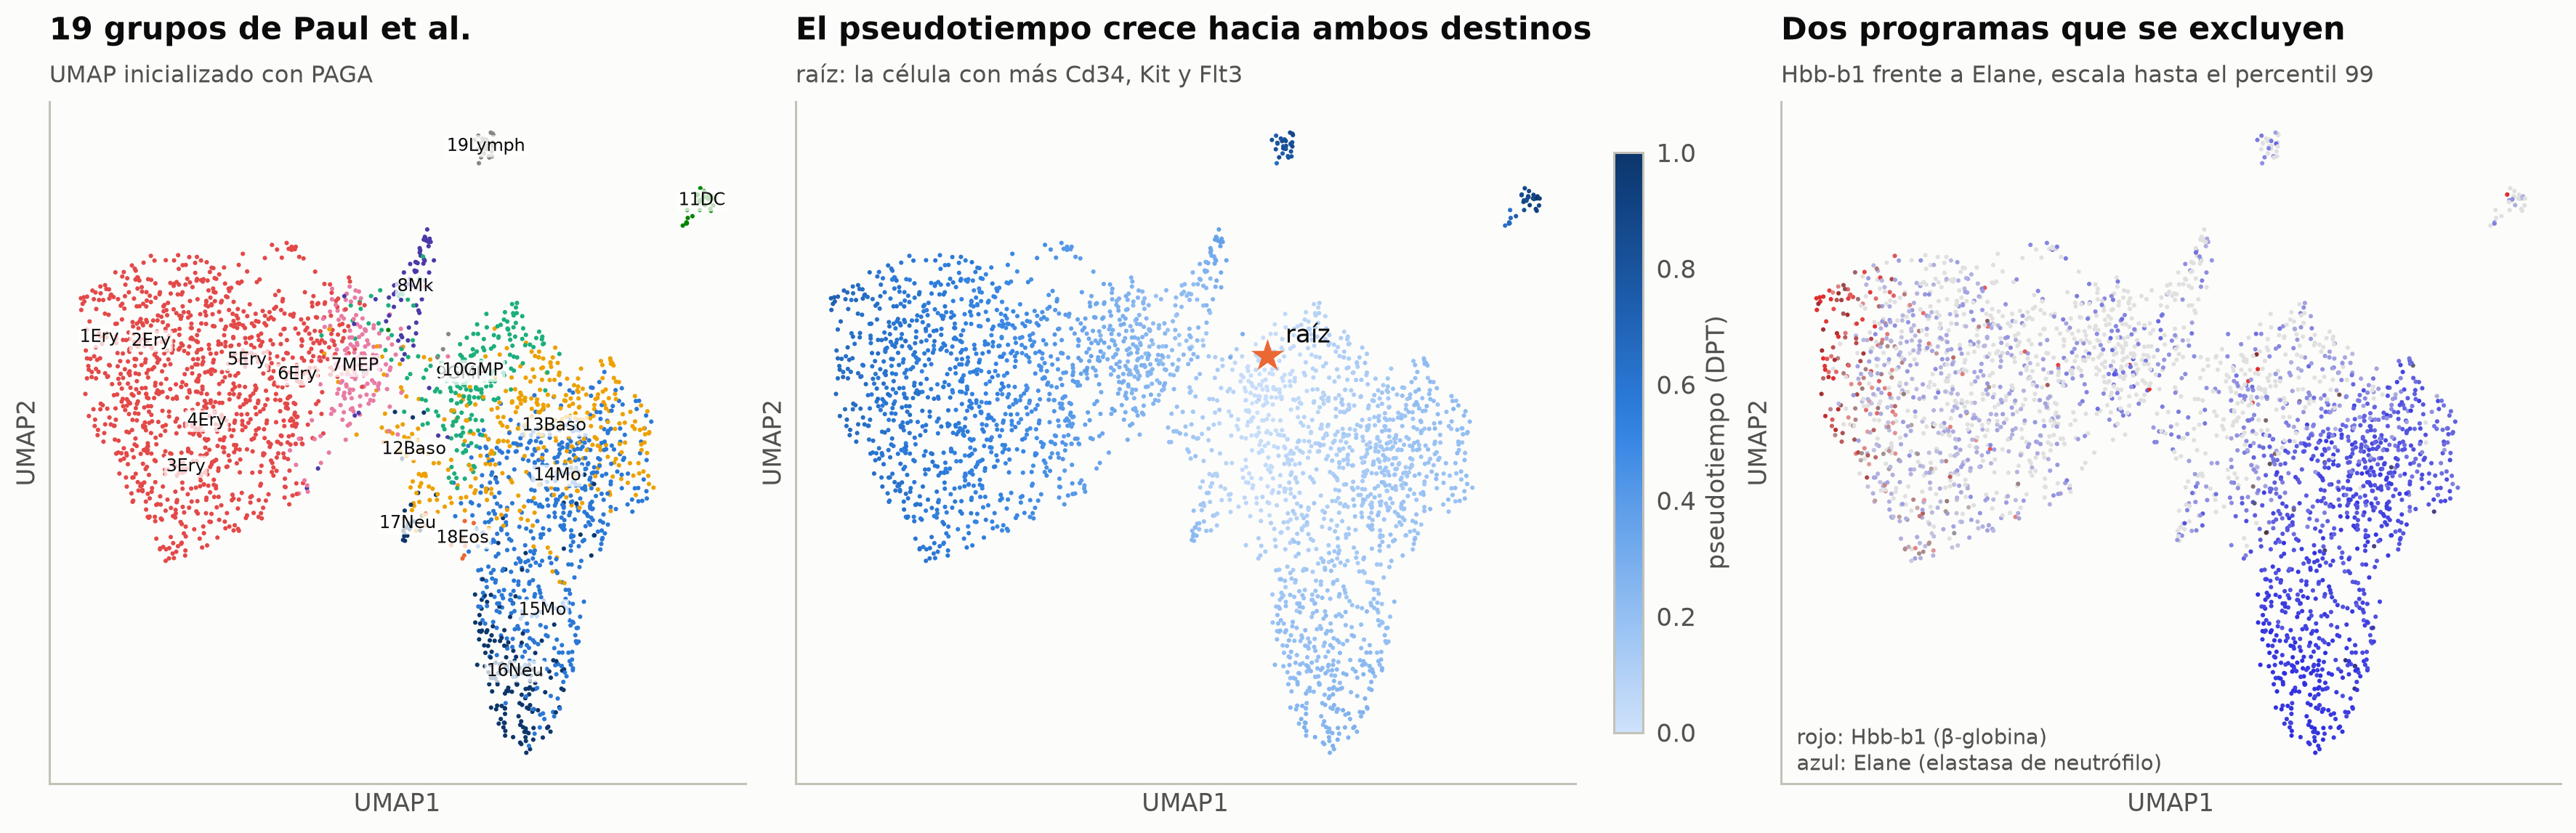

In [26]:
# Colores por linaje (mismos tonos que la simulación: eritroide rojo, mieloide azul)
LINEAGE = {"Ery": ec.RED, "MEP": ec.MAGENTA, "Mk": ec.VIOLET, "GMP": ec.AQUA, "Mo": ec.BLUE, "Neu": "#0d366b",
           "Baso": ec.YELLOW, "Eos": ec.ORANGE, "DC": ec.GREEN, "Lymph": ec.MUTED}
def lineage_of(name):
    return "".join(ch for ch in name if not ch.isdigit())
cl_color = {c: LINEAGE[lineage_of(c)] for c in cl_names}
UM = adata.obsm["X_umap"]
fig, axes = plt.subplots(1, 3, figsize=(16, 5.1), gridspec_kw=dict(width_ratios=[1, 1.12, 1.12]))
ax = axes[0]
ax.scatter(UM[:, 0], UM[:, 1], s=4, lw=0, c=[cl_color[c] for c in clusters])
for c in cl_names:
    xy = np.median(UM[(clusters == c).to_numpy()], axis=0)
    ax.text(xy[0], xy[1], c, fontsize=8, ha="center", va="center", color=ec.INK,
            bbox=dict(boxstyle="round,pad=0.12", fc="white", ec="none", alpha=0.75))
ec.title(ax, "19 grupos de Paul et al.", "UMAP inicializado con PAGA")
ax = axes[1]
s_ = ax.scatter(UM[:, 0], UM[:, 1], s=4, lw=0, c=dpt_real, cmap="curso_seq")
ax.scatter(UM[iroot, 0], UM[iroot, 1], marker="*", s=240, c=ec.ORANGE, edgecolors="white", zorder=3)
ax.annotate("raíz", UM[iroot], xytext=(8, 6), textcoords="offset points", color=ec.INK)
fig.colorbar(s_, ax=ax, label="pseudotiempo (DPT)", shrink=0.85)
ec.title(ax, "El pseudotiempo crece hacia ambos destinos", "raíz: la célula con más Cd34, Kit y Flt3")
ax = axes[2]
g_ery, g_mye = raw_expr("Hbb-b1"), raw_expr("Elane")
rgb = np.clip(np.column_stack([g_ery / np.quantile(g_ery, 0.99), np.zeros(len(g_ery)),
                               g_mye / np.quantile(g_mye, 0.99)]), 0, 1)
col = np.clip(np.column_stack([0.88 - 0.7 * rgb[:, 2], 0.88 - 0.7 * np.maximum(rgb[:, 0], rgb[:, 2]),
                               0.88 - 0.7 * rgb[:, 0]]), 0, 1)
ax.scatter(UM[:, 0], UM[:, 1], s=4, lw=0, c=col)
ax.text(0.02, 0.02, "rojo: Hbb-b1 (β-globina)\nazul: Elane (elastasa de neutrófilo)", transform=ax.transAxes,
        fontsize=9.5, color=ec.INK_2)
ec.title(ax, "Dos programas que se excluyen", "Hbb-b1 frente a Elane, escala hasta el percentil 99")
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([]); ax.set_xlabel("UMAP1"); ax.set_ylabel("UMAP2"); ax.grid(False)
plt.show()

> 🔎 **Qué observamos.** El UMAP inicializado con PAGA muestra dos grandes brazos: el eritroide (rojo), que parte de
> MEP y avanza por 6Ery … 1Ery, y el granulocítico-monocítico (azul), que parte de los GMP hacia monocitos y
> neutrófilos; megacariocitos, basófilos, eosinófilos y células dendríticas forman salidas laterales. La β-globina y la
> elastasa casi nunca coinciden en la misma célula: a este nivel de maduración el destino ya está decidido.

### 🎛️ El mapa de metro de la médula ósea

Cada nodo es uno de los 19 grupos, colocado en su posición PAGA; el tamaño indica cuántas células tiene y el color su
pseudotiempo mediano. Las aristas son las conectividades de Scanpy mayores que 0,1. Pase el ratón por un nodo para
ver sus vecinos más conectados y la expresión media de un marcador de cada linaje.

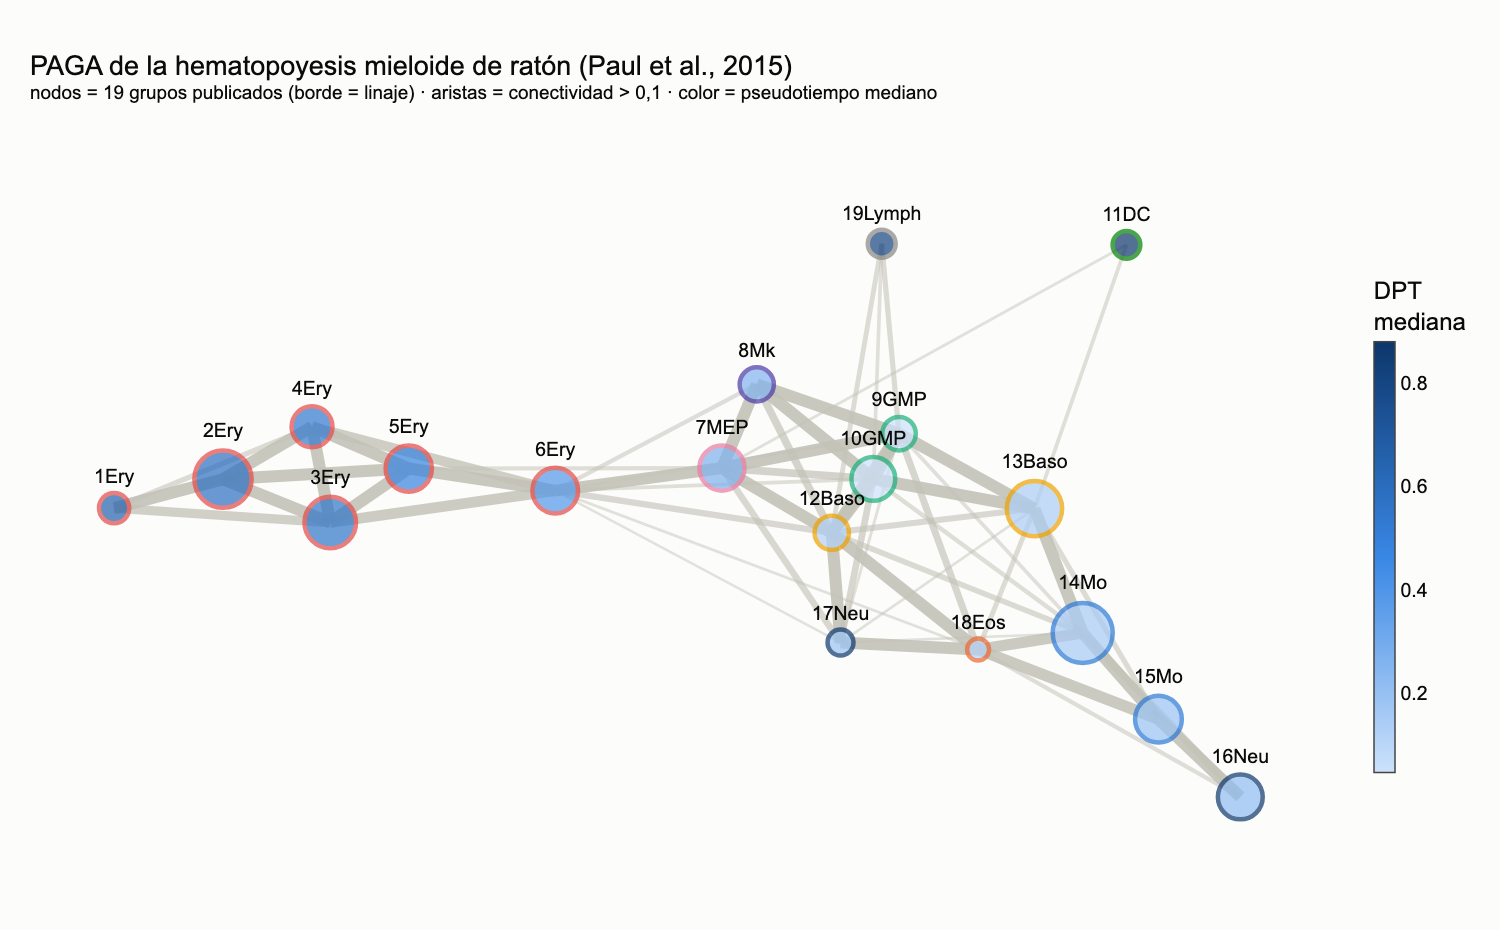

In [27]:
pos_p = adata.uns["paga"]["pos"]
n_cl = clusters.value_counts().reindex(cl_names).to_numpy()
mean_g = {g: pd.Series(raw_expr(g)).groupby(clusters.to_numpy()).mean().reindex(cl_names).to_numpy()
          for g in ("Cd34", "Gata1", "Hbb-b1", "Mpo", "Elane")}
fig = go.Figure()
for i in range(len(cl_names)):
    for j in range(i + 1, len(cl_names)):
        if conn_real[i, j] > 0.1:
            fig.add_trace(go.Scatter(x=pos_p[[i, j], 0], y=pos_p[[i, j], 1], mode="lines", hoverinfo="skip",
                                     line=dict(width=1 + 7 * conn_real[i, j], color=ec.BASELINE), showlegend=False,
                                     opacity=0.4 + 0.5 * conn_real[i, j]))
hover_p = []
for i, c in enumerate(cl_names):
    nbrs = np.argsort(-conn_real[i])[:3]
    nb_txt = ", ".join(f"{cl_names[j]} ({conn_real[i, j]:.2f})" for j in nbrs if conn_real[i, j] > 0)
    hover_p.append(f"<b>{c}</b> · {n_cl[i]} células<br>pseudotiempo mediano: {med[c]:.2f}"
                   f"<br>vecinos más conectados: {nb_txt}<br>Cd34 {mean_g['Cd34'][i]:.2f} · Gata1 {mean_g['Gata1'][i]:.2f}"
                   f" · Hbb-b1 {mean_g['Hbb-b1'][i]:.2f}<br>Mpo {mean_g['Mpo'][i]:.2f} · Elane {mean_g['Elane'][i]:.2f}"
                   f"<br><i>medias de log(1 + CP10k)</i>")
fig.add_trace(go.Scatter(
    x=pos_p[:, 0], y=pos_p[:, 1], mode="markers+text", text=cl_names, textposition="top center",
    hovertext=hover_p, hovertemplate="%{hovertext}<extra></extra>", showlegend=False,
    marker=dict(size=10 + 30 * np.sqrt(n_cl / n_cl.max()), color=med.reindex(cl_names).to_numpy(),
                colorscale=[[0, ec.SEQ_BLUE[0]], [0.5, ec.SEQ_BLUE[6]], [1, ec.SEQ_BLUE[-1]]],
                line=dict(color=[cl_color[c] for c in cl_names], width=3),
                colorbar=dict(title="DPT<br>mediana", thickness=14, len=0.7))))
fig.update_layout(
    title="PAGA de la hematopoyesis mieloide de ratón (Paul et al., 2015)"
          "<br><sup>nodos = 19 grupos publicados (borde = linaje) · aristas = conectividad > 0,1 · color = pseudotiempo mediano</sup>",
    xaxis=dict(visible=False), yaxis=dict(visible=False, scaleanchor="x"), height=620,
    margin=dict(t=100, l=20, r=20, b=20))
fig.show()

> 🔎 **Qué observamos.** La cadena eritroide 7MEP → 6Ery → … → 1Ery es una línea casi recta con pseudotiempo
> creciente. Las aristas impresas arriba muestran que 9GMP y 10GMP se conectan con fuerza (conectividad 1,00) con
> 7MEP, 8Mk y los basófilos, y más débilmente con 14Mo (0,20–0,28) y 17Neu (0,14–0,49). En cambio 16Neu no cuelga de
> los GMP sino de 15Mo (1,00) y 14Mo (0,54): los «Mo» de Paul et al. no son monocitos maduros sino progenitores con un
> programa de gránulos compartido (*Mpo* y *Elane* altos), y por eso quedan pegados a los neutrófilos. PAGA
> no impuso un árbol: algunos grupos (GMP, MEP, basófilos) forman pequeños ciclos, porque en progenitores los estados
> intermedios se tocan de varias maneras.

### Los genes a lo largo de cada camino

Seguimos dos lados del grafo: el camino **eritroide** (7MEP → 6Ery → … → 1Ery) y el lado **mieloide** (9GMP y 10GMP
junto con 14Mo, 15Mo y 16Neu). El segundo no es una línea: monocitos y neutrófilos son destinos hermanos que salen de
los GMP, y aquí los tratamos juntos sólo para ver cuándo se enciende el programa mieloide común. En cada uno promediamos la expresión en 20 intervalos de pseudotiempo y la reescalamos a $[0,1]$ para
comparar el **momento** en que sube o baja cada gen, no su nivel absoluto.

> 🤔 **Antes de ejecutar, prediga.** En el camino eritroide, ¿qué subirá antes: el factor de transcripción *Gata1* o
> la β-globina *Hbb-b1*? En el mieloide, ¿*Mpo* (gránulos primarios, promielocito) o *Elane*?

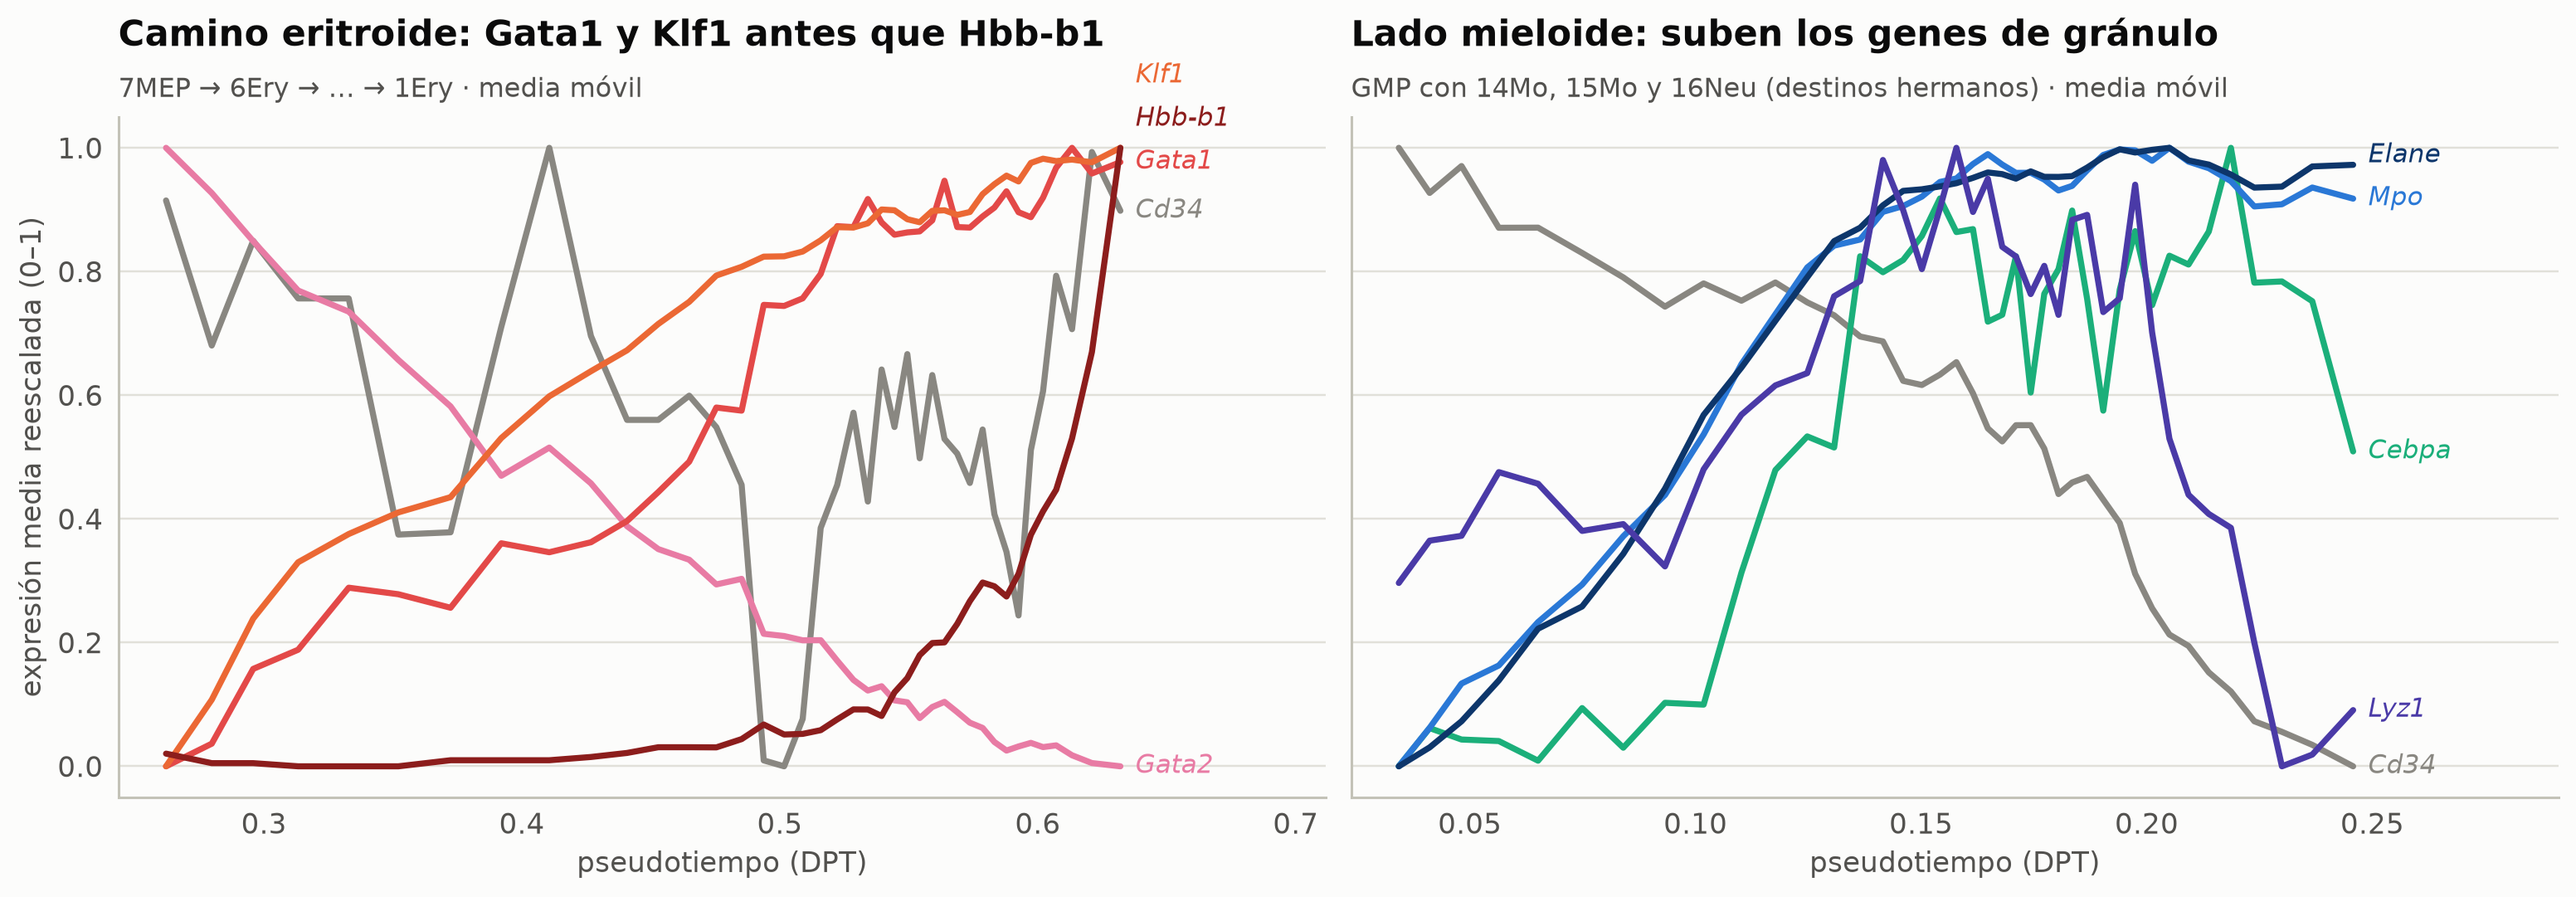

pseudotiempo en que cada gen que sube cruza la mitad de su rango:
   eritroide · Gata1   0.48
   eritroide · Klf1    0.39
   eritroide · Hbb-b1  0.61
    mieloide · Cebpa   0.12
    mieloide · Mpo     0.10
    mieloide · Elane   0.10
    mieloide · Lyz1    0.11
expresión media (log) por grupo del lado mieloide:
       9GMP  10GMP  14Mo  15Mo  16Neu
Mpo    3.88   3.86  5.60  5.86   6.07
Elane  0.94   0.97  4.72  5.31   5.81
Csf1r  0.10   0.44  0.99  0.50   0.32
Irf8   0.27   1.13  1.78  0.82   0.25


In [28]:
def path_trend(gene, mask, window=0.15, n_pts=40):
    """Media móvil de la expresión frente al pseudotiempo: ventana del 15 % de las células del camino."""
    order_ = np.argsort(dpt_real[mask])
    tau = dpt_real[mask][order_]
    y = raw_expr(gene)[mask][order_]
    w = max(5, int(window * len(y)))
    ys = np.convolve(y, np.ones(w) / w, mode="valid")
    ts = np.convolve(tau, np.ones(w) / w, mode="valid")
    pick = np.linspace(0, len(ys) - 1, n_pts).astype(int)
    return ts[pick], ys[pick]

def spread_labels(ys, gap=0.07):
    """Separa verticalmente las etiquetas finales para que no se solapen."""
    order_ = np.argsort(ys); out = np.array(ys, float)
    for k in range(1, len(order_)):
        out[order_[k]] = max(out[order_[k]], out[order_[k - 1]] + gap)
    return out

GENES_ERY = [("Cd34", ec.MUTED), ("Gata2", ec.MAGENTA), ("Gata1", ec.RED), ("Klf1", ec.ORANGE), ("Hbb-b1", "#8c1d1c")]
GENES_MYE = [("Cd34", ec.MUTED), ("Cebpa", ec.AQUA), ("Mpo", ec.BLUE), ("Elane", "#0d366b"), ("Lyz1", ec.VIOLET)]
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), sharey=True)
onset = {}
for ax, mask, spec, name in ((axes[0], in_ery, GENES_ERY, "eritroide"), (axes[1], in_mye, GENES_MYE, "mieloide")):
    ends = []
    for g, colr in spec:
        xm, ym = path_trend(g, mask)
        ys = (ym - ym.min()) / (ym.max() - ym.min() + 1e-9)
        ax.plot(xm, ys, color=colr, lw=2.4)
        ends.append((xm[-1], ys[-1], g, colr))
        onset[(name, g)] = xm[np.argmax(ys >= 0.5)] if ys[0] < 0.5 else np.nan   # cruce ascendente de la mitad
    for (x_end, _, g, colr), y_lab in zip(ends, spread_labels([e[1] for e in ends])):
        ax.annotate(g, (x_end, y_lab), xytext=(6, 0), textcoords="offset points", va="center", color=colr,
                    fontsize=10, fontstyle="italic", annotation_clip=False)
    ax.set_xlabel("pseudotiempo (DPT)")
    ax.set_xlim(ax.get_xlim()[0], ax.get_xlim()[1] + 0.15 * np.ptp(ax.get_xlim()))
axes[0].set_ylabel("expresión media reescalada (0–1)")
ec.title(axes[0], "Camino eritroide: Gata1 y Klf1 antes que Hbb-b1", "7MEP → 6Ery → … → 1Ery · media móvil")
ec.title(axes[1], "Lado mieloide: suben los genes de gránulo", "GMP con 14Mo, 15Mo y 16Neu (destinos hermanos) · media móvil")
plt.show()
print("pseudotiempo en que cada gen que sube cruza la mitad de su rango:")
for (name, g), v in onset.items():
    if np.isfinite(v):
        print(f"   {name:>9} · {g:<7} {v:.2f}")
print("expresión media (log) por grupo del lado mieloide:")
print(pd.DataFrame({g: [raw_expr(g)[(clusters == c).to_numpy()].mean() for c in PATH_MYE]
                    for g in ("Mpo", "Elane", "Csf1r", "Irf8")}, index=PATH_MYE).round(2).T.to_string())

> 🔎 **Qué observamos.** En el camino eritroide *Cd34* y *Gata2* (progenitores) descienden mientras *Klf1* y *Gata1*
> suben (*Gata1* ya está parcialmente encendido en los MEP y sigue subiendo, por eso cruza la mitad de su rango algo
> después que *Klf1*), y la β-globina *Hbb-b1* llega al final, cuando la célula ya es un eritroblasto: el mismo patrón
> regulador → efector que vimos en la simulación, ahora en datos reales. En el camino mieloide la resolución es menor:
> *Mpo*, *Elane*, *Cebpa* y *Lyz1* suben casi a la vez (cruzan la mitad de su rango en un pseudotiempo de ≈ 0,10–0,12)
> mientras *Cd34* baja, porque este camino es corto en DPT (la raíz ya es un GMP) y los GMP de Paul et al. ya
> están cebados hacia el programa granulocítico: el pseudotiempo no puede separar lo que ocurre casi simultáneamente. Recuerde que *Mpo* no parte de cero: en este conjunto tiene una
> expresión de fondo apreciable incluso en los grupos eritroides (≈ 2,7 en escala log), así que lo que vemos es una
> **subida** de 2,7 a ≈ 6, no un encendido desde nada. La tabla final lo confirma por grupo: *Mpo* pasa de 3,9 en los
> GMP a 5,6 en 14Mo y 6,1 en 16Neu, y *Elane* de 0,9 a 4,7 y 5,8. Que los grupos «Mo» tengan tanto *Mpo* y *Elane*
> mientras *Csf1r* e *Irf8*, que marcan el compromiso monocítico, sólo suben de forma moderada en 14Mo (1,0 y 1,8)
> indica que son progenitores tempranos con sesgo monocítico, no monocitos maduros. Y la **reescala 0–1** exagera los cambios de genes poco
> expresados, como *Cebpa*: mire siempre también los niveles absolutos.

> 🩸 **De la médula sana a la leucemia.** Este mapa de la hematopoyesis normal es la referencia con la que se
> interpretan las leucemias. **van Galen et al. (2019)** perfilaron médulas de pacientes con leucemia mieloide aguda
> por scRNA-seq y clasificaron cada célula maligna según su parecido con los estados normales de la jerarquía
> (desde progenitores hasta monocitos): los tumores diferían en **dónde** se acumulaban sus células a lo largo del
> camino, y las células malignas de tipo monocítico, las más diferenciadas, podían suprimir a los linfocitos T. La lógica es la de esta clase: primero un eje de
> diferenciación normal, luego la proyección de las células enfermas sobre él.

> ✅ **Compruebe su comprensión.** ¿Por qué no podemos concluir, sólo con esta figura, que *Gata1* **activa** a
> *Hbb-b1*? *(El pseudotiempo da un orden temporal plausible, pero dos genes pueden subir uno tras otro por un tercer
> factor común o por simple coincidencia del programa. Hace falta una perturbación, como eliminar Gata1 y medir la
> globina, para hablar de causalidad.)*

## 7. La idea de la velocidad de ARN

### El pseudotiempo ordena, pero no orienta

La DPT no sabe si el proceso va del tronco a las ramas o al revés; por eso necesita una raíz elegida por usted.
**La Manno et al. (2018)** observaron que la **dirección está escrita en los propios datos**. Un protocolo de
scRNA-seq con cebadores poli(dT) captura también una fracción de transcritos **no maduros**, que aún conservan
intrones. Si un gen acaba de **activarse**, sus transcritos no maduros abundan en relación con los maduros (la fábrica
acaba de arrancar y el almacén todavía está vacío); si se está **apagando**, escasean (la fábrica paró, pero el
almacén sigue lleno). El cociente entre ambos es el **velocímetro** de la fotografía del maratón.

**Teorema (modelo cinético de la transcripción).** Sean $u(t)$ y $s(t)$ las abundancias de ARN no maduro
(*unspliced*) y maduro (*spliced*) de un gen. Con tasa de transcripción $\alpha$, de maduración $\beta$ y de
degradación $\gamma$,

$$
\frac{du}{dt}=\alpha-\beta u,\qquad \frac{ds}{dt}=\beta u-\gamma s.
$$

Con $\alpha$ constante y condiciones iniciales $u_0,s_0$, la solución es

$$
\begin{aligned}
u(t)&=u_0e^{-\beta t}+\frac{\alpha}{\beta}\left(1-e^{-\beta t}\right),\\
s(t)&=s_0e^{-\gamma t}+\frac{\alpha}{\gamma}\left(1-e^{-\gamma t}\right)+\frac{\alpha-\beta u_0}{\gamma-\beta}\left(e^{-\gamma t}-e^{-\beta t}\right),
\end{aligned}
$$

y el estado estacionario es $u^*=\alpha/\beta$, $s^*=\alpha/\gamma$, que satisface $u^*=(\gamma/\beta)\,s^*$.

| Símbolo | Significado |
|---|---|
| $u,\ s$ | ARN no maduro (con intrones) y maduro (empalmado) de un gen en una célula |
| $\alpha$ | tasa de transcripción: alta mientras el gen está activo, cero cuando se reprime |
| $\beta$ | tasa de corte y empalme (*splicing*): convierte $u$ en $s$ |
| $\gamma$ | tasa de degradación del ARNm maduro |
| $\gamma'=\gamma/\beta$ | pendiente de la recta de estado estacionario en el plano $(s,u)$ |
| $v=ds/dt=\beta u-\gamma s$ | **velocidad de ARN** del gen: positiva si el ARN maduro está aumentando |

La primera ecuación es lineal de primer orden y se resuelve directamente; la segunda, sustituyendo $u(t)$ y usando el
factor integrante $e^{\gamma t}$.

**A mano.** Con $\alpha=4$, $\beta=1$ y $\gamma=0{,}4$ (el gen del libro): $u^*=4/1=4$ y $s^*=4/0{,}4=10$, y en ese
punto $v=1\cdot4-0{,}4\cdot10=0$. Una célula con $u=3$, $s=4$ tiene $v=3-1{,}6=1{,}4>0$: está **induciendo** el
gen. Una con $u=1$, $s=8$ tiene $v=1-3{,}2=-2{,}2<0$: lo está **reprimiendo**.

**La idea geométrica.** En el plano $(s,u)$, las células en estado estacionario caen sobre la recta $u=\gamma's$. Una
célula **por encima** de la recta tiene más ARN no maduro del que corresponde a su ARN maduro: el gen se está
induciendo y $v>0$. **Por debajo**, se está reprimiendo y $v<0$.

### Estimación en el modelo estacionario

La Manno et al. supusieron que las células con valores **extremos** de $u$ y $s$ (los percentiles superiores e
inferiores) están cerca del estado estacionario, activo o inactivo, y estimaron $\gamma'$ por **regresión por el
origen** sobre ellas:

$$
\hat\gamma'=\frac{\sum_{c\in\mathcal{E}}u_c\,s_c}{\sum_{c\in\mathcal{E}}s_c^2},\qquad \hat v_c\propto u_c-\hat\gamma'\,s_c,
$$

con $\mathcal{E}$ el conjunto de células extremas (aquí: $u$ o $s$ por encima del percentil 95, o ambos por debajo del
percentil 5). Simulamos el gen del libro (semilla 12): 260 células en inducción durante 6 unidades de tiempo y 200 en
represión, con ruido de Poisson. El libro obtiene $\hat\gamma'=0{,}463$ (el real es $0{,}400$) y un **86,3 %** de
células con el signo de la velocidad correcto.

In [29]:
alpha, beta, gamma = 4.0, 1.0, 0.4
t_switch = 6.0

def kinetics(t, u0, s0, a):
    """Solución analítica del modelo cinético con alfa constante (a)."""
    u = u0 * np.exp(-beta * t) + a / beta * (1 - np.exp(-beta * t))
    s = (s0 * np.exp(-gamma * t) + a / gamma * (1 - np.exp(-gamma * t))
         + (a - beta * u0) / (gamma - beta) * (np.exp(-gamma * t) - np.exp(-beta * t)))
    return u, s

rgv = np.random.default_rng(12)
n_in, n_rep = 260, 200
t_in = rgv.uniform(0, t_switch, n_in)
u_in, s_in = kinetics(t_in, 0, 0, alpha)                         # inducción desde (0, 0)
u_sw, s_sw = kinetics(np.array([t_switch]), 0, 0, alpha)        # estado en el momento del cambio
t_re = rgv.uniform(0, 8, n_rep)
u_re, s_re = kinetics(t_re, u_sw[0], s_sw[0], 0.0)               # represión: alfa = 0
U_true, S_true = np.r_[u_in, u_re], np.r_[s_in, s_re]
phase = np.r_[np.ones(n_in, int), np.zeros(n_rep, int)]          # 1 inducción, 0 represión
U_obs = rgv.poisson(U_true * 3) / 3                              # ruido de muestreo
S_obs = rgv.poisson(S_true * 3) / 3

extreme = (U_obs >= np.quantile(U_obs, 0.95)) | (S_obs >= np.quantile(S_obs, 0.95))
extreme |= (U_obs <= np.quantile(U_obs, 0.05)) & (S_obs <= np.quantile(S_obs, 0.05))
g_hat = np.sum(U_obs[extreme] * S_obs[extreme]) / np.sum(S_obs[extreme] ** 2)
v_hat = U_obs - g_hat * S_obs
sign_ok = np.mean((v_hat > 0) == (phase == 1))
print(f"γ' real = {gamma / beta:.3f} · γ' estimado (extremos, {extreme.sum()} células) = {g_hat:.3f}")
print(f"signo de la velocidad correcto en el {sign_ok:.1%} de las células")
print(f"estado estacionario: u* = {alpha / beta:.2f}, s* = {alpha / gamma:.2f}")

γ' real = 0.400 · γ' estimado (extremos, 54 células) = 0.463
signo de la velocidad correcto en el 86.3% de las células
estado estacionario: u* = 4.00, s* = 10.00


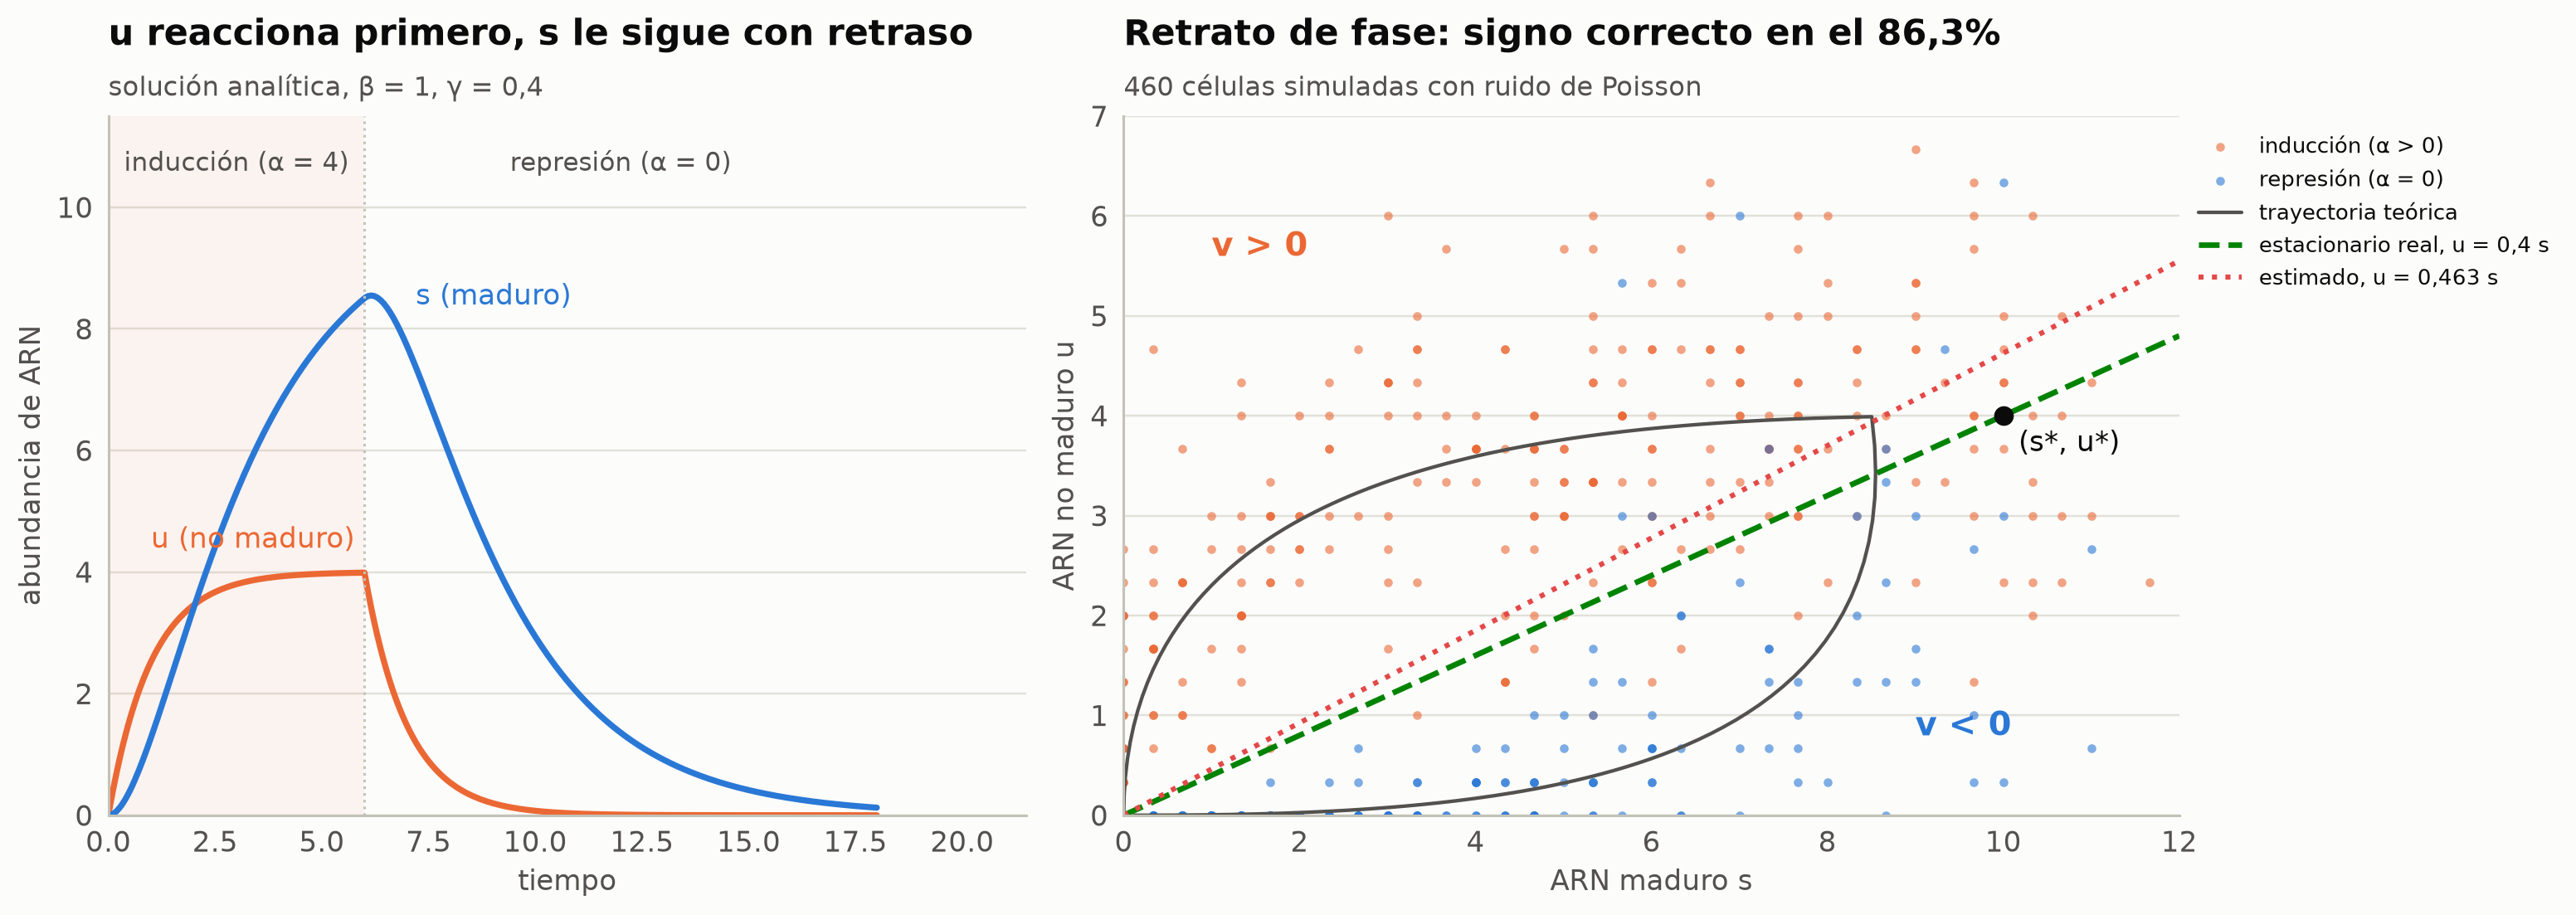

In [30]:
tt1 = np.linspace(0, t_switch, 120); uu1, ss1 = kinetics(tt1, 0, 0, alpha)
tt2 = np.linspace(0, 12, 160); uu2, ss2 = kinetics(tt2, u_sw[0], s_sw[0], 0.0)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.9), gridspec_kw=dict(width_ratios=[1, 1.15]))
ax = axes[0]
tt = np.r_[tt1, t_switch + tt2]
ax.plot(tt, np.r_[uu1, uu2], color=ec.ORANGE, lw=2.4)
ax.plot(tt, np.r_[ss1, ss2], color=ec.BLUE, lw=2.4)
ax.text(1.0, 4.4, "u (no maduro)", color=ec.ORANGE, fontsize=11)
ax.text(7.2, 8.4, "s (maduro)", color=ec.BLUE, fontsize=11)
ax.axvspan(0, t_switch, color=ec.ORANGE, alpha=0.06)
ax.axvline(t_switch, color=ec.BASELINE, lw=1, ls=":")
ax.text(t_switch / 2, 10.6, "inducción (α = 4)", ha="center", color=ec.INK_2, fontsize=10)
ax.text(t_switch + 6, 10.6, "represión (α = 0)", ha="center", color=ec.INK_2, fontsize=10)
ax.set_xlim(0, 21.5); ax.set_ylim(0, 11.5)
ax.set_xlabel("tiempo"); ax.set_ylabel("abundancia de ARN")
ec.title(ax, "u reacciona primero, s le sigue con retraso", "solución analítica, β = 1, γ = 0,4")
ax = axes[1]
for ph, colr, lbl in ((1, ec.ORANGE, "inducción (α > 0)"), (0, ec.BLUE, "represión (α = 0)")):
    m = phase == ph
    ax.scatter(S_obs[m], U_obs[m], s=12, lw=0, color=colr, alpha=0.6, label=lbl)
ax.plot(np.r_[ss1, ss2], np.r_[uu1, uu2], color=ec.INK_2, lw=1.4, label="trayectoria teórica")
xs = np.linspace(0, 12, 50)
ax.plot(xs, gamma / beta * xs, color=ec.GREEN, lw=2.2, ls="--", label="estacionario real, u = 0,4 s")
ax.plot(xs, g_hat * xs, color=ec.RED, lw=2, ls=":", label=f"estimado, u = {g_hat:.3f} s".replace(".", ","))
ax.scatter([10], [4], s=60, color=ec.INK, zorder=4)
ax.annotate("(s*, u*)", (10, 4), xytext=(6, -14), textcoords="offset points", color=ec.INK)
ax.text(1.0, 5.6, "v > 0", color=ec.ORANGE, fontsize=13, fontweight="bold")
ax.text(9.0, 0.8, "v < 0", color=ec.BLUE, fontsize=13, fontweight="bold")
ax.set_xlim(0, 12); ax.set_ylim(0, 7)
ax.set_xlabel("ARN maduro s"); ax.set_ylabel("ARN no maduro u")
ax.legend(loc="upper left", fontsize=8.5, ncol=1, bbox_to_anchor=(1.0, 1.0))
ec.title(ax, f"Retrato de fase: signo correcto en el {sign_ok:.1%}".replace(".", ","), "460 células simuladas con ruido de Poisson")
plt.show()

> 🔎 **Qué observamos.** A la izquierda, al encenderse el gen, $u$ sube primero y $s$ le sigue con retraso; al
> apagarse, $u$ cae deprisa y $s$ se degrada lentamente. A la derecha, esa historia dibuja un **bucle** en el plano
> $(s,u)$: la inducción (naranja) recorre la rama superior hacia $(s^*,u^*)=(10,4)$ y la represión (azul) vuelve al
> origen por la inferior. La recta estimada por los extremos ($\hat\gamma'=0{,}463$) está algo sesgada respecto de la
> real ($0{,}400$) porque no todas las células extremas están en equilibrio; aun así, el signo de $u-\hat\gamma's$
> clasifica correctamente la fase del 86,3 % de las células.

### 🎛️ Retrato de fase interactivo

Pase el ratón por las células: verá sus $u$ y $s$, la velocidad estimada $\hat v=u-\hat\gamma's$, su fase real y si
el signo acierta. Las células mal clasificadas (marcadas con ✗) se concentran cerca de la recta y de los extremos,
donde la señal es más débil que el ruido.

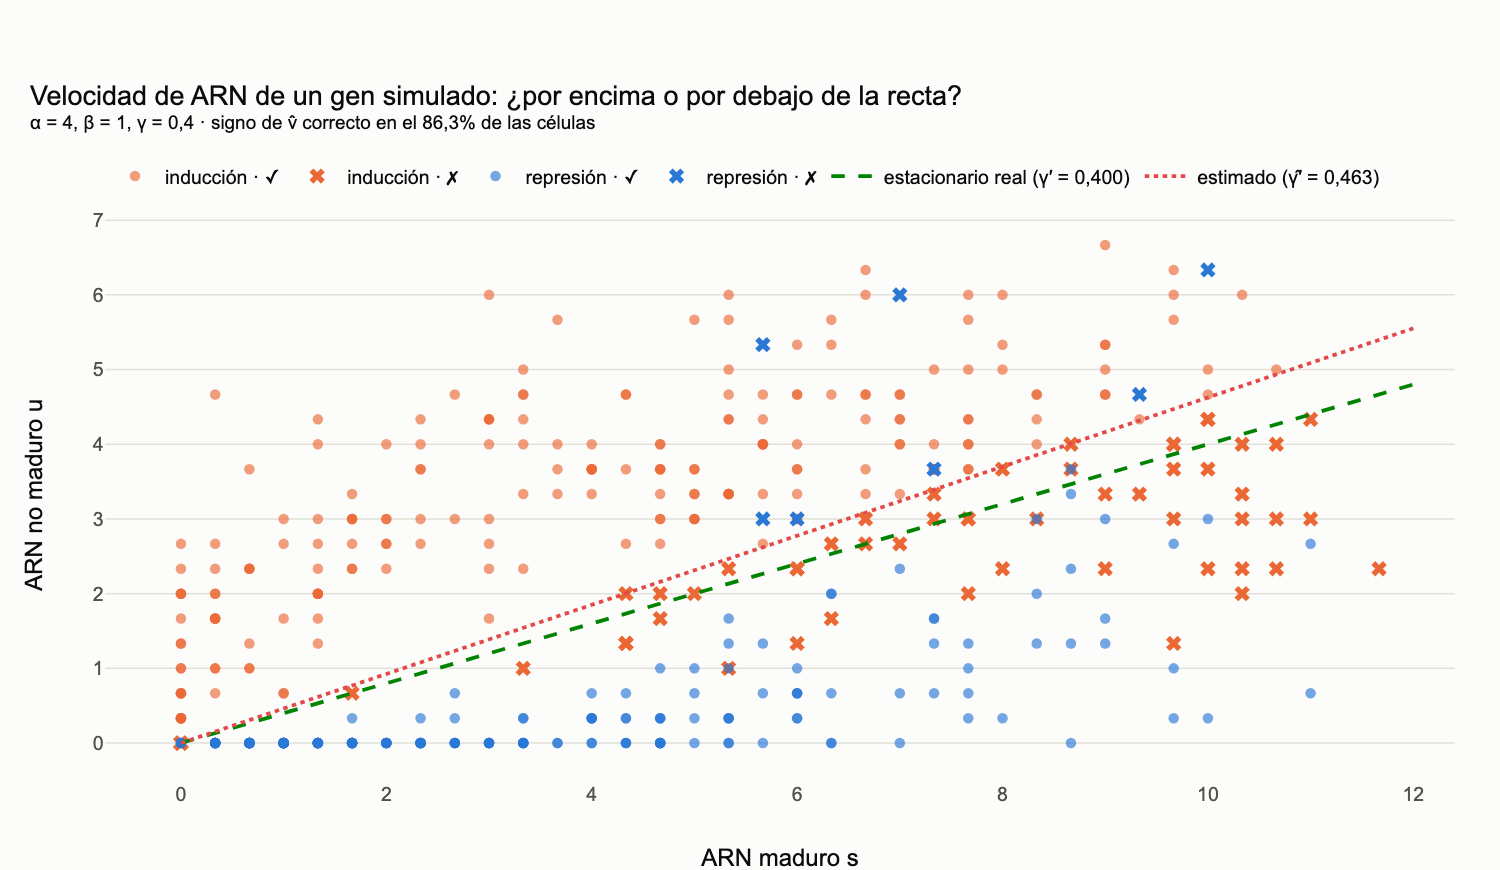

In [31]:
ok_sign = (v_hat > 0) == (phase == 1)
fig = go.Figure()
for ph, colr, name in ((1, ec.ORANGE, "inducción"), (0, ec.BLUE, "represión")):
    for good, sym in ((True, "circle"), (False, "x")):
        m = (phase == ph) & (ok_sign == good)
        txt = [f"<b>{name}</b> ({'signo correcto ✓' if good else 'signo incorrecto ✗'})<br>u = {U_obs[i]:.2f} · s = {S_obs[i]:.2f}"
               f"<br>v̂ = u − γ̂′s = {v_hat[i]:+.2f}<br>v real = βu − γs = {beta * U_true[i] - gamma * S_true[i]:+.2f}"
               for i in np.flatnonzero(m)]
        fig.add_trace(go.Scatter(x=S_obs[m], y=U_obs[m], mode="markers", name=f"{name} · {'✓' if good else '✗'}",
                                 text=txt, hovertemplate="%{text}<extra></extra>",
                                 marker=dict(color=colr, symbol=sym, size=7 if good else 9, opacity=0.65 if good else 1)))
xs = np.linspace(0, 12, 50)
fig.add_trace(go.Scatter(x=xs, y=gamma / beta * xs, mode="lines", name="estacionario real (γ′ = 0,400)",
                         line=dict(color=ec.GREEN, dash="dash", width=2.5), hoverinfo="skip"))
fig.add_trace(go.Scatter(x=xs, y=g_hat * xs, mode="lines", name=f"estimado (γ̂′ = {g_hat:.3f})".replace(".", ","),
                         line=dict(color=ec.RED, dash="dot", width=2.5), hoverinfo="skip"))
fig.update_layout(
    title="Velocidad de ARN de un gen simulado: ¿por encima o por debajo de la recta?"
          f"<br><sup>α = 4, β = 1, γ = 0,4 · signo de v̂ correcto en el {sign_ok:.1%} de las células</sup>".replace(".", ","),
    xaxis_title="ARN maduro s", yaxis_title="ARN no maduro u", height=580,
    legend=dict(orientation="h", yanchor="bottom", y=1.02, x=0), margin=dict(t=140, l=70, r=30, b=60))
fig.show()

### El modelo dinámico y las herramientas reales

El supuesto de que existen células en equilibrio falla cuando el proceso es **transitorio**: si el experimento capta
la inducción pero no la meseta, el ajuste por extremos subestima o sobreestima $\gamma'$ y la velocidad **cambia de
signo**. **Bergen et al. (2020)**, en *scVelo*, resolvieron la cinética completa: para cada gen estiman $\alpha$,
$\beta$, $\gamma$, el tiempo de cambio entre inducción y represión y un **tiempo latente** para cada célula,
maximizando la verosimilitud con un algoritmo de esperanza-maximización sobre las soluciones anteriores. El tiempo
latente compartido entre genes es además un **pseudotiempo con dirección**, que no requiere elegir raíz.

Las capas `spliced` y `unspliced` **no** las produce el cuantificador estándar: hay que generarlas contando por
separado las lecturas exónicas e intrónicas (`velocyto`, STARsolo con la opción `Velocyto` o `alevin-fry`). El conjunto
de Paul et al. que usamos no las trae, por eso aquí nos quedamos en la idea. El flujo completo en Python sería:

```python
import scvelo as scv
# adata con capas "spliced" y "unspliced"
scv.pp.filter_and_normalize(adata, min_shared_counts=20, n_top_genes=2000)
scv.pp.moments(adata, n_pcs=30, n_neighbors=30)
scv.tl.recover_dynamics(adata)
scv.tl.velocity(adata, mode="dynamical")
scv.tl.velocity_graph(adata)
scv.pl.velocity_embedding_stream(adata, basis="umap")
```

> ⚠️ **Cuándo desconfiar de las flechas.** Las flechas de velocidad son atractivas y engañosas. El modelo supone
> **tasas constantes por gen** y un único programa de inducción-represión; los genes con varias fases de expresión, o
> con tasas que cambian entre linajes, lo violan. Los transcritos no maduros son pocos y ruidosos, de modo que la
> velocidad se **suaviza promediando entre vecinos**, y las flechas proyectadas sobre un UMAP heredan todas sus
> distorsiones (lección 12.2). Compruebe que los genes que dirigen la velocidad tienen retratos de fase con la forma
> del bucle de arriba y que la dirección inferida concuerda con el conocimiento biológico antes de interpretarla.

## 8. Ejercicios

**Ejercicio 1 (vecinos y componentes).** En la simulación del libro, recalcule el mapa de difusión con $k=10$, $30$ y
$60$ vecinos y la DPT con 2, 5 y 10 componentes. Tabule la correlación de Spearman con el tiempo simulado. ¿Qué
parámetro importa más? ¿Por qué añadir componentes apenas cambia el resultado?

**Ejercicio 2 (la raíz importa).** En la simulación, elija como raíz (a) una célula al azar del tronco, (b) la de
menor tiempo simulado y (c) la punta de la rama mieloide ($e_1$, el extremo más lejano de la raíz). Compare la correlación de Spearman de la DPT con
$t$ en el tronco y en cada rama. ¿Qué rama «se invierte» en (c)?

**Ejercicio 3 (PAGA y resolución).** Repita PAGA sobre la simulación con Louvain a resolución $0{,}3$ y $1{,}2$.
¿Cuántos grupos salen y qué aristas superan $0{,}05$? ¿Sigue viéndose la topología en «Y»? ¿Qué le dice esto sobre
la dependencia de PAGA respecto del agrupamiento?

**Ejercicio 4 (datos reales: genes del camino eritroide).** En los datos de Paul et al., calcule la correlación de
Spearman entre la DPT y la expresión log-normalizada de **todos** los genes dentro del camino eritroide (7MEP → 1Ery).
Liste los 8 genes más positivamente y los 8 más negativamente correlacionados. ¿Reconoce genes de la hemoglobina, del
metabolismo del hierro o de proliferación?

**Ejercicio 5 (velocidad en un proceso transitorio).** Resuelva numéricamente la ecuación cinética con
`scipy.integrate.solve_ivp` y compruebe que coincide con la solución analítica. Luego repita la estimación de
$\hat\gamma'$ con sólo las células de inducción con $t<2$ (el experimento «llegó tarde» a la meseta y no vio la
represión). ¿Cuánto se sesga $\hat\gamma'$ y qué fracción de células recibe el signo correcto?

In [32]:
#@title 🔑 Solución — Ejercicio 1 { display-mode: "form" }
rows = []
for k_ in (10, 30, 60):
    lam_k, psi_k, _ = diffusion_map(pcs_sim, k=k_)
    cand_k = np.argsort(-score_prog)[:20]
    root_k = cand_k[np.argmax(np.abs(psi_k[cand_k, 1] - np.median(psi_k[:, 1])))]
    for n_dc in (2, 5, 10):
        d_ = dpt_from(root_k, psi_k, lam_k, n_dc=n_dc)
        rows.append(dict(k=k_, n_DC=n_dc, spearman=round(stats.spearmanr(d_, t_sim).statistic, 3)))
print(pd.DataFrame(rows).pivot(index="k", columns="n_DC", values="spearman"))
# Los pesos λ/(1−λ) hacen que DC1 y DC2 dominen: pasar de 2 a 10 componentes cambia poco. El número de vecinos
# importa algo más: con k muy pequeño el grafo es ruidoso; con k grande se «cortocircuitan» regiones distintas.

n_DC     2      5      10
k                        
10    0.973  0.972  0.972
30    0.979  0.978  0.978
60    0.980  0.979  0.979


In [33]:
#@title 🔑 Solución — Ejercicio 2 { display-mode: "form" }
rng_e = np.random.default_rng(0)
roots = {"(a) tronco al azar": int(rng_e.choice(np.flatnonzero(branch == 0))),
         "(b) menor t simulado": int(np.argmin(t_sim)), "(c) punta e1": e1}
for name, r_ in roots.items():
    d_ = dpt_from(r_, psi, lam)
    res = [stats.spearmanr(d_[branch == b], t_sim[branch == b]).statistic for b in range(3)]
    print(f"{name:<22} t(raíz) = {t_sim[r_]:.2f} · tronco {res[0]:+.3f} · eritroide {res[1]:+.3f} · mieloide {res[2]:+.3f}")
# Una raíz en el tronco da resultados parecidos entre sí. Con la raíz en la punta e1, la rama de e1 aparece con
# correlación negativa (se recorre al revés) y el tronco también se invierte: la DPT ordena, no orienta.

(a) tronco al azar     t(raíz) = 0.17 · tronco +0.394 · eritroide +0.983 · mieloide +0.987
(b) menor t simulado   t(raíz) = 0.00 · tronco +0.883 · eritroide +0.983 · mieloide +0.987
(c) punta e1           t(raíz) = 0.96 · tronco -0.893 · eritroide +0.753 · mieloide -0.988


In [34]:
#@title 🔑 Solución — Ejercicio 3 { display-mode: "form" }
for res in (0.3, 1.2):
    lab_r = louvain(A_sim, res, seed=1)
    conn_r, *_ = paga_connectivity(A_sim, lab_r)
    Kr = lab_r.max() + 1
    ed = [(a, b, conn_r[a, b]) for a in range(Kr) for b in range(a + 1, Kr) if conn_r[a, b] > 0.05]
    maj = [BRANCH_NAMES[np.bincount(branch[lab_r == c], minlength=3).argmax()][:3] for c in range(Kr)]
    print(f"resolución {res}: {Kr} grupos {dict(enumerate(maj))}")
    print("   aristas:", "; ".join(f"{a}–{b}: {c:.2f}" for a, b, c in ed))
# Con resolución baja, la zona de la bifurcación queda repartida entre grupos grandes de las ramas y aparecen
# aristas difíciles de leer; con resolución alta, cada rama se vuelve una cadena de nodos que parte del tronco.
# La topología gruesa depende del corte: interprete PAGA con varias resoluciones antes de concluir.

resolución 0.3: 5 grupos {0: 'eri', 1: 'tro', 2: 'eri', 3: 'mie', 4: 'mie'}
   aristas: 0–2: 0.12; 0–3: 0.12; 0–4: 0.14; 1–4: 0.13


resolución 1.2: 8 grupos {0: 'tro', 1: 'tro', 2: 'eri', 3: 'mie', 4: 'eri', 5: 'mie', 6: 'eri', 7: 'mie'}
   aristas: 0–1: 0.13; 1–2: 0.07; 1–3: 0.20; 2–3: 0.44; 2–4: 0.48; 3–7: 0.52; 4–6: 0.89; 5–7: 0.77


In [35]:
#@title 🔑 Solución — Ejercicio 4 { display-mode: "form" }
Xe = adata.raw.X[in_ery]
Xe = Xe.toarray() if sparse.issparse(Xe) else np.asarray(Xe)
keep = (Xe > 0).mean(0) > 0.05                                    # genes detectados en >5 % de las células
rho_g = np.array([stats.spearmanr(Xe[:, j], dpt_real[in_ery]).statistic for j in np.flatnonzero(keep)])
names_g = np.asarray(adata.raw.var_names)[keep]
o_g = np.argsort(rho_g)
print("suben con τ:", [f"{names_g[i]} ({rho_g[i]:+.2f})" for i in o_g[::-1][:8]])
print("bajan con τ:", [f"{names_g[i]} ({rho_g[i]:+.2f})" for i in o_g[:8]])
# Al alza: globinas (Hba-a2), anhidrasa carbónica (Car2), el antígeno Rh (Rhd) y enzimas de la síntesis del hemo
# (Cpox, Hmbs). A la baja: genes de progenitor y de otros linajes (Gata2, Apoe, Srgn, Laptm5). Es una lista de hipótesis para priorizar, no una prueba de regulación.

suben con τ: ['Fam132a (+0.74)', 'Ctse (+0.71)', 'Car2 (+0.68)', 'Rhd (+0.67)', 'Hba-a2 (+0.63)', 'Cldn13 (+0.62)', 'Cpox (+0.61)', 'Hmbs (+0.61)']
bajan con τ: ['Apoe (-0.69)', 'Ptprcap (-0.46)', 'S100a10 (-0.46)', 'Laptm5 (-0.45)', 'Srgn (-0.43)', 'Arhgdib (-0.38)', 'Muc13 (-0.35)', 'Gata2 (-0.35)']


In [36]:
#@title 🔑 Solución — Ejercicio 5 { display-mode: "form" }
from scipy.integrate import solve_ivp
sol = solve_ivp(lambda t, y: [alpha - beta * y[0], beta * y[0] - gamma * y[1]], (0, t_switch), [0, 0],
                t_eval=tt1, rtol=1e-9, atol=1e-12)
print("máx |numérico − analítico|: u", np.abs(sol.y[0] - uu1).max().round(8), "· s", np.abs(sol.y[1] - ss1).max().round(8))
rg5 = np.random.default_rng(5)
t5 = rg5.uniform(0, 2, 300)
u5, s5 = kinetics(t5, 0, 0, alpha)
u5, s5 = rg5.poisson(u5 * 3) / 3, rg5.poisson(s5 * 3) / 3
ext5 = (u5 >= np.quantile(u5, 0.95)) | (s5 >= np.quantile(s5, 0.95))
ext5 |= (u5 <= np.quantile(u5, 0.05)) & (s5 <= np.quantile(s5, 0.05))
g5 = np.sum(u5[ext5] * s5[ext5]) / np.sum(s5[ext5] ** 2)
print(f"sólo inducción temprana: γ̂′ = {g5:.3f} (real 0,400) · signo correcto (todas inducen): {np.mean(u5 - g5 * s5 > 0):.1%}")
# Sin meseta ni represión, las células «extremas» son las más inducidas, que están MUY por encima de la recta:
# γ̂′ se infla y muchas células quedan por debajo de la recta estimada, con velocidad negativa aunque todas están
# encendiendo el gen. Es el fallo que motivó el modelo dinámico de scVelo.

máx |numérico − analítico|: u 0.0 · s 0.0
sólo inducción temprana: γ̂′ = 0.918 (real 0,400) · signo correcto (todas inducen): 78.7%


## 📌 Resumen

* Muchos procesos celulares (hematopoyesis, espermatogénesis, desarrollo neural) son **continuos**: un experimento de
  célula única es una fotografía con células en todas las etapas. El **pseudotiempo** $\tau_c\in[0,1]$ mide el
  progreso **transcripcional** desde una raíz $r$ elegida con biología; no es un reloj.
* Las distancias en línea recta engañan en trayectorias curvas (la herradura). Los **mapas de difusión** usan un
  paseo aleatorio sobre el grafo de vecinos: núcleo gaussiano con anchos locales $\sigma_i$, normalización por
  densidad, $T=D^{-1}K$ y componentes $\psi_l$ con valores propios $\lambda_l$. En la bifurcación del libro:
  $\lambda=1;\ 0{,}9943;\ 0{,}9928;\ 0{,}9781$.
* La **DPT** suma las transiciones de todas las longitudes, $M=\sum_t(T-\psi_0\phi_0^\top)^t$, y resulta una
  distancia euclídea con pesos $\lambda_l/(1-\lambda_l)$ ($173{,}7$, $138{,}3$, $44{,}7$): los modos lentos mandan.
  Reproducimos $\rho=0{,}978$ con el tiempo simulado ($0{,}983$ y $0{,}987$ en las ramas, $0{,}891$ en el tronco). Las
  ramas aparecen donde el orden medido desde distintos extremos deja de ser coherente.
* La multiplicidad del valor propio 1 cuenta los **componentes conexos**: con un grafo partido, la DPT es infinita
  para las células fuera del componente de la raíz. Compruebe la conectividad.
* **PAGA** resume la topología: nodos = grupos, aristas = conectividad $c_{ab}=\min\{1,e_{ab}/(k_ak_b/2m)\}$. En la
  simulación, 6 grupos y un triángulo en la bifurcación (arista 4–5: $0{,}40$). No impone un árbol.
* En la **hematopoyesis de ratón** (Paul et al., 2015), una raíz progenitora (*Cd34*, *Kit*, *Flt3*) produce un
  pseudotiempo monótono por el camino 7MEP → 1Ery y desde los GMP hacia monocitos y neutrófilos, que son destinos
  hermanos y no etapas de una misma cadena; *Gata1* y *Klf1* suben antes que
  *Hbb-b1*. El orden es una hipótesis causal, no una prueba.
* La **velocidad de ARN** usa el cociente entre ARN no maduro $u$ y maduro $s$: con $du/dt=\alpha-\beta u$ y
  $ds/dt=\beta u-\gamma s$, las células por encima de la recta $u=\gamma's$ inducen el gen ($v>0$). En el gen del
  libro, $\hat\gamma'=0{,}463$ frente a $0{,}400$ y un 86,3 % de signos correctos; el modelo dinámico de scVelo corrige
  los sesgos de los procesos transitorios.

## 📚 Lecturas recomendadas

* Trapnell, C. et al. (2014). The dynamics and regulators of cell fate decisions are revealed by pseudotemporal
  ordering of single cells. *Nature Biotechnology*, 32(4), 381–386. https://doi.org/10.1038/nbt.2859
* Coifman, R. R. y Lafon, S. (2006). Diffusion maps. *Applied and Computational Harmonic Analysis*, 21(1), 5–30.
  https://doi.org/10.1016/j.acha.2006.04.006
* Haghverdi, L., Buettner, F. y Theis, F. J. (2015). Diffusion maps for high-dimensional single-cell analysis of
  differentiation data. *Bioinformatics*, 31(18), 2989–2998. https://doi.org/10.1093/bioinformatics/btv325
* Haghverdi, L., Büttner, M., Wolf, F. A., Buettner, F. y Theis, F. J. (2016). Diffusion pseudotime robustly
  reconstructs lineage branching. *Nature Methods*, 13(10), 845–848. https://doi.org/10.1038/nmeth.3971
* Paul, F. et al. (2015). Transcriptional heterogeneity and lineage commitment in myeloid progenitors. *Cell*,
  163(7), 1663–1677. https://doi.org/10.1016/j.cell.2015.11.013
* Wolf, F. A., Angerer, P. y Theis, F. J. (2018). SCANPY: large-scale single-cell gene expression data analysis.
  *Genome Biology*, 19, 15. https://doi.org/10.1186/s13059-017-1382-0
* Wolf, F. A. et al. (2019). PAGA: graph abstraction reconciles clustering with trajectory inference through a
  topology preserving map of single cells. *Genome Biology*, 20, 59. https://doi.org/10.1186/s13059-019-1663-x
* Saelens, W., Cannoodt, R., Todorov, H. y Saeys, Y. (2019). A comparison of single-cell trajectory inference methods.
  *Nature Biotechnology*, 37(5), 547–554. https://doi.org/10.1038/s41587-019-0071-9
* La Manno, G. et al. (2018). RNA velocity of single cells. *Nature*, 560(7719), 494–498.
  https://doi.org/10.1038/s41586-018-0414-6
* Bergen, V., Lange, M., Peidli, S., Wolf, F. A. y Theis, F. J. (2020). Generalizing RNA velocity to transient cell
  states through dynamical modeling. *Nature Biotechnology*, 38(12), 1408–1414. https://doi.org/10.1038/s41587-020-0591-3
* van Galen, P. et al. (2019). Single-cell RNA-seq reveals AML hierarchies relevant to disease progression and
  immunity. *Cell*, 176(6), 1265–1281. https://doi.org/10.1016/j.cell.2019.01.031
* Heumos, L. et al. (2023). Best practices for single-cell analysis across modalities. *Nature Reviews Genetics*,
  24(8), 550–572. https://doi.org/10.1038/s41576-023-00586-w

---

☕ **¿Le sirvió esta clase?** El curso es gratuito y seguirá siéndolo; puede apoyarlo invitándome un café en [buymeacoffee.com/juvenalyosx](https://buymeacoffee.com/juvenalyosx). ¡Gracias!

<sub>**Bioinformática Práctica** · © 2026 Juvenal Yosa, PhD · [juvenal.yosa@gmail.com](mailto:juvenal.yosa@gmail.com) · Código bajo licencia MIT ·
Desarrollado con **Claude** (Anthropic) como copiloto.</sub>

[![Copiloto: Claude](https://img.shields.io/badge/Copiloto-Claude-D97757?logo=claude&logoColor=white)](https://claude.ai) [![Apoye el proyecto: Buy Me a Coffee](https://img.shields.io/badge/Apoye%20el%20proyecto-Buy%20Me%20a%20Coffee-FFDD00?logo=buymeacoffee&logoColor=black)](https://buymeacoffee.com/juvenalyosx)